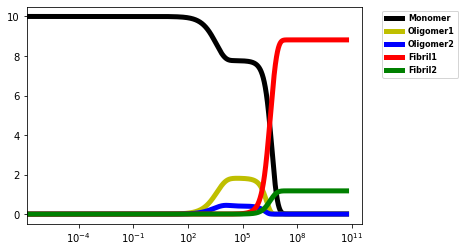

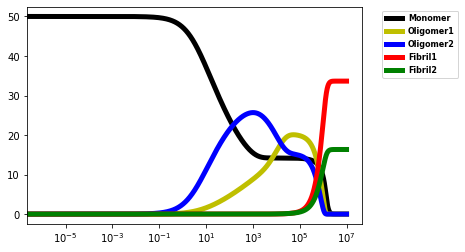

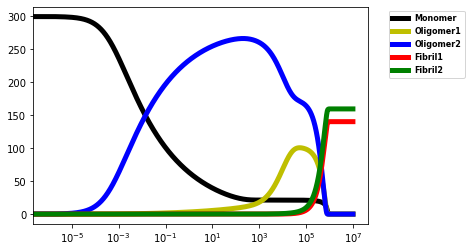

In [1]:
###### We introduce Multiple pathway-Filibrilization model

##  Figure 2A 

import matplotlib.pyplot as plt
import numpy as np
import math
from matplotlib.ticker import FormatStrFormatter
from scipy.integrate import solve_ivp
from scipy.integrate import odeint
import matplotlib.cm as cm
plt.close('all')


### Create lists for half-time, half-fibril mass and initial peptide concentration to plot half_time vs Conc plot
t50_alla=[]
fibril_alla=[]
Y0_alla=[]

for nf2 in [6]:        ## Tune the parameter of interest
    #p0 = [0Kd-p, 1kd-, 2Phi_BN, 3Nd, 4Nf1, 5Nf2, 6Phi_CR1, 7Phi_CR2,   8Kf1-p;1st-pathway, 9Kf1-;1st-pathway, 10Kf2-p;2nd-pathway, 11Kf2-;2nd-pathway, 12Kfrag, 13G1, 14G2] 
    p0=   [0,     0,    0,       0,   4,   nf2,  0.01,    0.01,    10**(-4),        5*10**(-8),         10**(-4),                   5*10**(-8),           0,       6,   6 ]       # Free parameters in our model        
    yy=[0.6,0.8,1,2,4,8,10,20,31,40,50,60,70,80,90,100,200,300,400,500] 
    n=len(yy)        #### Total discrete point concentration
    
    
    ##################################################
    # Define a function to solve all rate-mass equations
    def func0(t, u): 
        du = [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0]         # Introduce all states in our model
        #### Aproximate nf1+10 and truncate the high order dependency
        if t>0:
            if u[0]> p[6]:
                nf1plus1= u[18]  
            else:
                nf1plus1= u[18]*(u[0]/p[6])
        else:
            nf1plus1= 0     
        #### Aproximate nf2+10 and truncate the high order dependency   
        if t>0:
            if u[0]>p[7]:
                nf2plus1= u[27]
            else:
                nf2plus1= u[27]*(u[0]/p[7])
        else:
            nf2plus1= 0
         
        ### Define different terms 
        EEE1=  Kfn1*u[0]**p[4] - p[8]*u[4];                      # 1st-pathway oligomer nucleation  
        EEE2=  Kfn2*u[0]**p[5] - p[10]*u[7];                     # 2nd-pathway oligomer nucleation
        EE1=  p[4]*EEE1;                                         # monomer loss due to 1st-pathway oligomer nucleation
        EE2=  p[5]*EEE2;                                         # monomer loss due to 2st-pathway oligomer nucleation
        NNN1= (Kf1p*u[0]*u[4] - p[9]*u[10])*np.exp(-p[13])    # 1st-pathway oligomer to fibril conversion
        NNN2= (Kf2p*u[0]*u[7] - p[11]*u[19])*np.exp(-p[14])   # 2nd-pathway oligomer to fibril conversion
        NN1= (p[4]+1)* NNN1                                      # fibril mass from 1st-pathway oligomer to fibril conversion
        NN2= (p[5]+1)* NNN2                                      # fibril mass from 2nd-pathway oligomer to fibril conversion
        GG1= (Kf1p*u[0]-p[9])*u[5] +  p[9]* u[10];            # Growth and shrinking of the 1st-pathway fibril  
        GG2= (Kf2p*u[0]-p[11])*u[8] + p[11]* u[19];           # Growth and shrinking of the 2nd-pathway fibril 
        
        
        ### Introduce Fragmentation
        #JJ1= p[12]*u[6]*Fragmentation(u[6], u[5], p[4])         # fragmentation in 1st-pathway fibril
        #JJ2= p[12]*u[9]*Fragmentation(u[9], u[8], p[5])         # fragmentation in 2nd-pathway fibril
         
        ### Rate-mass equations
        du[0] = - EE1  - GG1 - NNN1 - EE2  - GG2 - NNN2                  
        du[1] = 0      
        du[2] = 0
        du[3] = 0
        du[4] = EEE1 - NNN1
        du[5] = NNN1 #+ JJ1
        du[6] = NN1 + GG1 
        du[7] = EEE2 - NNN2
        du[8] = NNN2 #+ JJ2
        du[9] = NN2 + GG2
        du[10]= (Kf1p*u[0]*u[4]*np.exp(-p[13]) -(Kf1p*u[0] + p[9]*np.exp(-p[13]))*u[10] + p[9]*u[11])
        du[11]= (Kf1p*u[0]*u[10] -(Kf1p*u[0] + p[9])*u[11] + p[9]*u[12])
        du[12]= (Kf1p*u[0]*u[11] -(Kf1p*u[0] + p[9])*u[12] + p[9]*u[13])
        du[13]= (Kf1p*u[0]*u[12] -(Kf1p*u[0] + p[9])*u[13] + p[9]*u[14])
        du[14]= (Kf1p*u[0]*u[13] -(Kf1p*u[0] + p[9])*u[14] + p[9]*u[15])
        du[15]= (Kf1p*u[0]*u[14] -(Kf1p*u[0] + p[9])*u[15] + p[9]*u[16])
        du[16]= (Kf1p*u[0]*u[15] -(Kf1p*u[0] + p[9])*u[16] + p[9]*u[17])
        du[17]= (Kf1p*u[0]*u[16] -(Kf1p*u[0] + p[9])*u[17] + p[9]*u[18])
        du[18]= (Kf1p*u[0]*u[17] -(Kf1p*u[0] + p[9])*u[18] + p[9]*nf1plus1)
        du[19]= (Kf2p*u[0]*u[7]*np.exp(-p[14]) -(Kf2p*u[0] + p[11]*np.exp(-p[14]))*u[19] + p[11]*u[20])
        du[20]= (Kf2p*u[0]*u[19] -(Kf2p*u[0] + p[11])*u[20] + p[11]*u[21])
        du[21]= (Kf2p*u[0]*u[20] -(Kf2p*u[0] + p[11])*u[21] + p[11]*u[22])
        du[22]= (Kf2p*u[0]*u[21] -(Kf2p*u[0] + p[11])*u[22] + p[11]*u[23])
        du[23]= (Kf2p*u[0]*u[22] -(Kf2p*u[0] + p[11])*u[23] + p[11]*u[24])
        du[24]= (Kf2p*u[0]*u[23] -(Kf2p*u[0] + p[11])*u[24] + p[11]*u[25])
        du[25]= (Kf2p*u[0]*u[24] -(Kf2p*u[0] + p[11])*u[25] + p[11]*u[26])
        du[26]= (Kf2p*u[0]*u[25] -(Kf2p*u[0] + p[11])*u[26] + p[11]*u[27])
        du[27]= (Kf2p*u[0]*u[26] -(Kf2p*u[0] + p[11])*u[27] + p[11]*nf2plus1)
        
        #if t>1000:
            #print(EEE1,EEE2,NNN1,NNN2,GG1,GG2,u[5],u[8])
        #if du[6]< 0 and u[0]< p[6]:
            #sigma= u[0]/p[6]
            #kdeno= sigma + p[4]+1 - (p[4]+1)*sigma
            #knum= 1 + kdeno
            #Kdf= du[6]/u[6]
            #du[10]=Kdf*u[10] - (knum/kdeno)*u[10]*du[0]/u[0]*sigma/(1-sigma)
            #du[5]= Kdf*u[5] - (1/kdeno)*u[5]*du[0]/u[0]*sigma/(1-sigma)
            
        #if u[0]< p[6]:
            #print(u[10],u[0],u[0]/p[6],u[0]/p[7],u[5],u[8],u[10]/(1-u[0]/p[6]),u[19]/(1-u[0]/p[7]),u[6],u[9],u[10]*((p[4]+1)- p[4]*(u[0]/ p[6]))/(1-u[0]/p[6])**2,u[19]*((p[5]+1)- p[5]*(u[0]/ p[7]))/(1-u[0]/p[7])**2)
            #print(du[0]/u[0],du[4]/u[4],du[5]/u[5],du[6]/u[6],du[7]/u[7],du[8]/u[8],du[9]/u[9])
        #if du[6] < 0:
            #du[5]= du[6]/u[6]*u[5]
            #du[0]=0;du[1]=0;du[2]=0;du[3]=0;du[4]=0;du[5]=0;du[6]=0;du[7]=0;du[8]=0;du[9]=0;
        return du
    
    
    ##################################################
    # Define how long we calculate (end-time) the time evolution of states for all concentrations
    x17=1*10**12; x16=5*10**10; x15=1*10**8; x14=1*10**7; x13=1*10**7;
    tend=[x17,x17,x17,x17,x16,x16,x16,x15,x15,x15,x14,x14,x14,x14,x14,x14,x14,x14,x13,x13,x13,x13,x13,x13,x13,x13,x13,x13,x13]
    
    ##################################################
    # Define the fragmentation function 
    def Fragmentation(x,y,z):
        if y==0:
            out=1
        elif x/y < z:
            out=0
        else:
            out=1
        return out
    ###################################################
    # Introduce lists to keep fibril-mass evolution and corresponding time
    fibril1a=[]
    time1a=[]
    oligomer1a=[]
    oligomer2a=[]
    totalfibril1a=[]
    totalfibril2a=[]
    O1eq=[]
    O2eq=[]
    #########################################################################
    for i in [6, 10, 17]:
    #for i in range(n):
        y0 = [yy[i],0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0]                           ## Introduce the initial condition
        p  = p0                                                  ## parameters in our model
        Kf1p = float(f"{p[9]/p[6]:.5e}")                         ## Monomer-addition rate in 1st-pathway 
        Kf2p = float(f"{p[11]/p[7]:.5e}")                        ## Monomer-addition rate in 2nd-pathway 
        Kfn1 = float(f"{(Kf1p*(Kf1p/p[8])**(p[4]-2)):.5e}")      ## Oligomer nucleation rate in 1st-pathway 
        Kfn2 = float(f"{(Kf2p*(Kf2p/p[10])**(p[5]-2)):.5e}")     ## Oligomer nucleation rate in 2nd-pathway
        
        #tspan  = (0,tend[i])                                     ## time span between initial and final time 
        #t_eval = np.linspace(0, tend[i],10000000)                 ## time interval to record the measured calculations
        #atol = 10**(-10)                                         ## absolute tolerence
        #rtol = 10**(-10)                                         ## relative tolerence
        #sol  = solve_ivp(func0,tspan,y0, t_eval=t_eval, method ='BDF',atol=atol, rtol=rtol)
        
        tspan1 = (0,1)
        t_eval1 = np.linspace(tspan1[0], tspan1[1], 1000000)
        sol1 = solve_ivp(func0, tspan1, y0, t_eval=t_eval1, method='BDF', atol=1e-10, rtol=1e-10)
            
        tspan2 = (1, 100)
        t_eval2 = np.logspace(np.log10(tspan2[0]), np.log10(tspan2[1]), 1000000)
        sol2 = solve_ivp(func0, tspan2, sol1.y[:, -1], t_eval=t_eval2, method='BDF', atol=1e-10, rtol=1e-10)
        
        tspan3 = (100, 10000)
        t_eval3 = np.logspace(np.log10(tspan3[0]), np.log10(tspan3[1]), 1000000)
        sol3 = solve_ivp(func0, tspan3, sol2.y[:, -1], t_eval=t_eval3, method='BDF', atol=1e-10, rtol=1e-10)
        
        tspan4 = (10000, tend[i])
        t_eval4 = np.logspace(np.log10(tspan4[0]), np.log10(tspan4[1]), 1000000)
        sol4 = solve_ivp(func0, tspan4, sol3.y[:, -1], t_eval=t_eval4, method='BDF', atol=1e-10, rtol=1e-10)
            
        sol_t = np.concatenate((sol1.t, sol2.t, sol3.t, sol4.t))
        sol_y = np.hstack((sol1.y, sol2.y, sol3.y, sol4.y))
           
        #fibril1a.append(sol_y[6] + sol_y[9] )                      ## append the fibril mass evolution in the list
        time1a.append(sol_t)                                       ## append the time-measured in the list
        
        oligomer1a.append(p[4]*sol_y[4])
        oligomer2a.append(p[5]*sol_y[7])
        #totalfibril1a.append(sol_y[6])
        #totalfibril2a.append(sol_y[9])
        
        #print(sol.y[0])
        #print(p[4]*sol.y[7])
        #print(sol.y[9])
        
        plt.plot(sol_t,sol_y[0, :],'k',linewidth = 5)
        plt.plot(sol_t, p[4]*sol_y[4, :],'y',linewidth = 5)
        plt.plot(sol_t, p[5]*sol_y[7, :],'b',linewidth = 5)
        #plt.plot(sol_t, sol_y[5, :],'r',linewidth = 5)
        #plt.plot(sol_t, sol_y[8, :],'g',linewidth = 5)
        plt.plot(sol_t, sol_y[6, :],'r',linewidth = 5)
        plt.plot(sol_t, sol_y[9, :],'g',linewidth = 5)
        #plt.plot(sol_t, sol_y[6, :] + sol_y[9, :],'purple',linewidth = 5)
        #plt.ylabel('Mass concentration (\u03bcM)',fontsize=15)
        #plt.xlabel('Time (s)',fontsize=15)
        #plt.xticks(fontsize=10)
        #plt.yticks(fontsize=10)
        #myleg = plt.legend(['Monomer','Oligomer','Fibril'],loc='upper left',prop = {'size':8}, bbox_to_anchor=(0.05,1.15), ncol=6, frameon=False )
        #plt.gca().ticklabel_format(style='sci', axis='x', scilimits=(0,0))
       
        #if i ==0:
            #plt.text(0.85, 0.8, " CNT w/D  ", fontsize=12, ha='center', va='center', transform=plt.gca().transAxes)
            #plt.savefig('fig2a_C.eps',dpi=300)
        #if i ==9:
            #plt.text(0.85, 0.8, " CNT w/D  ", fontsize=12, ha='center', va='center', transform=plt.gca().transAxes)
            #plt.savefig('fig2b_C.eps',dpi=300)
        #if i==13:
            #plt.text(0.85, 0.8, " CNT w/D  ", fontsize=12, ha='center', va='center', transform=plt.gca().transAxes)
            #plt.savefig('fig2c_C.eps',dpi=300)
        #plt.xscale('log')
        #plt.title('Linear Scale')
        #if i==0:
            #plt.text(0.000001, 5, 'I', fontsize = 22)
        #if i==1:
            #plt.text(0.000001, 40, 'II', fontsize = 22)
        #if i==2:
            #plt.text(0.000001, 27, 'III', fontsize = 22)
        #plt.subplot(1, 2, 2)
        #plt.plot(sol.t,sol.y[0, :],'k',linewidth = 5)
        #plt.plot(sol.t,p[0]*p[1] *sol.y[1, :],'y',linewidth = 5)
        #plt.plot(sol.t,sol.y[2, :],'r',linewidth = 5)
        #plt.plot(sol.t, sol.y[3, :] ,'b',linewidth = 5)
        #plt.plot(sol.t,sol.y[4, :],'g',linewidth = 5)
        #plt.xlim(0.00001,1)
        #plt.xlabel('Time', fontweight = 'bold')
        #plt.ylabel('Mass', fontweight = 'bold')
        plt.xscale('log')
        #plt.title('Linear Scale')
        myleg = plt.legend(['Monomer','Oligomer1','Oligomer2', 'Fibril1','Fibril2','Total_Fibril' ],loc='upper left',prop = {'size':8,'weight':'bold'}, bbox_to_anchor=(1.05,1)) 
        #plt.tight_layout()
        #plt.xlim(1,tend[i])
        #plt.xlim(0,10000000)
        #plt.savefig(f'variation_nf2_{y0[0]}.eps', dpi=300)
        plt.show()
    
    ###########################################################################################
#     # Fibril Mass fraction vs time for different concentration     
    

#     import matplotlib.pyplot as plt

#     # === Define 3 contrasting colors (once) ===
#     colors = ['tab:blue', 'tab:orange', 'tab:red']

#     Y0 = [10,50,300]
#     num_curves = len(Y0)

#     # ================= FIBRIL MASS FRACTION =================
#     plt.figure(figsize=(8, 5))
#     fibril_lista = [[el / Y0[p] for el in sub]
#                     for p, sub in enumerate(fibril1a)]

#     for idx, (t, f) in enumerate(zip(time1a, fibril_lista)):
#         plt.plot(t, f,
#                  color=colors[idx % len(colors)],
#                  label=f'C={Y0[idx]}')

#     plt.xscale('log')
#     plt.xlabel('Time, s', fontweight='bold')
#     plt.ylabel('Fibril mass fraction', fontweight='bold')
#     plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2, fontsize=9)
#     plt.tight_layout()
#     plt.show()


#     # ================= OLIGOMER 1 =================
#     plt.figure(figsize=(8, 5))
#     oligomer_list1a = [[el / Y0[p] for el in sub]
#                        for p, sub in enumerate(oligomer1a)]

#     for idx, (t, o1) in enumerate(zip(time1a, oligomer_list1a)):
#         plt.plot(t, o1,
#                  color=colors[idx % len(colors)],
#                  label=f'C={Y0[idx]}')

#     plt.xscale('log')
#     plt.xlabel('Time, s', fontweight='bold')
#     plt.ylabel('Oligomer_1 mass fraction', fontweight='bold')
#     plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2, fontsize=9)
#     plt.tight_layout()
#     #plt.show()


#     # ================= OLIGOMER 2 (DASHED) =================
#     #plt.figure(figsize=(8, 5))
#     oligomer_list2a = [[el / Y0[p] for el in sub]
#                        for p, sub in enumerate(oligomer2a)]

#     for idx, (t, o2) in enumerate(zip(time1a, oligomer_list2a)):
#         plt.plot(t, o2, '--',
#                  color=colors[idx % len(colors)],
#                  label=f'C={Y0[idx]}')

#     plt.xscale('log')
#     #plt.xlim(10000,100000)
#     plt.xlabel('Time, s', fontweight='bold')
#     plt.ylabel('Oligomer mass fraction', fontweight='bold')
#     plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2, fontsize=9)
#     plt.tight_layout()
#     plt.show()


#     # ================= FIBRIL 1 =================
#     plt.figure(figsize=(8, 5))
#     fibril_list1a = [[el / Y0[p] for el in sub]
#                      for p, sub in enumerate(totalfibril1a)]

#     for idx, (t, f1) in enumerate(zip(time1a, fibril_list1a)):
#         plt.plot(t, f1,
#                  color=colors[idx % len(colors)],
#                  label=f'C={Y0[idx]}')

#     plt.xscale('log')
#     plt.xlabel('Time, s', fontweight='bold')
#     plt.ylabel('Fibril_1 mass fraction', fontweight='bold')
#     plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2, fontsize=9)
#     plt.tight_layout()
#     #plt.show()


#     # ================= FIBRIL 2 (DASHED) =================
#     #plt.figure(figsize=(8, 5))
#     fibril_list2a = [[el / Y0[p] for el in sub]
#                      for p, sub in enumerate(totalfibril2a)]

#     for idx, (t, f2) in enumerate(zip(time1a, fibril_list2a)):
#         plt.plot(t, f2, '--',
#                  color=colors[idx % len(colors)],
#                  label=f'C={Y0[idx]}')

#     plt.xscale('log')
#     plt.xlabel('Time, s', fontweight='bold')
#     plt.ylabel('Fibril mass fraction', fontweight='bold')
#     plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2, fontsize=9)
#     plt.tight_layout()
#     plt.show()


#     ###########################################################################################   
#     #Find T_Half for each concentration
#     t50=[]   
#     fibril50=[]
#     Y050=[]
#     Y0= yy 
#     for i in range(n):
#         cutoff_value = (Y0[i]-p[7])/2      #specified cutoff value
#         list_I=fibril1a[i]              
#         list_II=time1a[i]
#         # Iterate through elements in List I
#         for value_I, value_II in zip(list_I, list_II):
#             if value_I >= cutoff_value:
#                 selected_value_I = value_I
#                 selected_value_II = value_II
#                 fibril50.append(selected_value_I)
#                 t50.append(selected_value_II)
#                 Y050.append(Y0[i])
#                 break                      # Break out of the loop once the condition is met
#     t50_alla.append(t50)
#     fibril_alla.append(fibril50)
#     Y0_alla.append(Y050)
#    ############################################################################################# 
 
# ### Plot the T_half vs Concentration for the given different parameter value
# ### Plot the T_half vs Concentration for the given different parameter value
# markers = ['o', 's', '^','D','*']  # circle, square, triangle

# for i, (sublist1, sublist2) in enumerate(zip(Y0_alla, t50_alla)):
#     plt.loglog(sublist1, sublist2, marker=markers[i], linestyle='-')  # Different marker for each curve

# plt.ylabel('T_Half, sec', fontweight='bold')
# plt.xlabel('Concentration, uM', fontweight='bold')
# # plt.title('For Different off-pathway \n monomer-oligomer dissociation rate')
# plt.legend(['kf2-p=7*10^-4', 'kf2-p=7*10^-5', 'kf2-p=7*10^-6','kf2-p=7*10^-7','kf2-p=7*10^-8'], bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.tight_layout()
# plt.show()  

[4.00000000e-15 4.05565675e-15 4.11208792e-15 ... 9.98978512e-04
 9.98978589e-04 9.98978666e-04] [4.00000000e-12 4.05565675e-12 4.11208792e-12 ... 9.98978512e-01
 9.98978589e-01 9.98978666e-01]


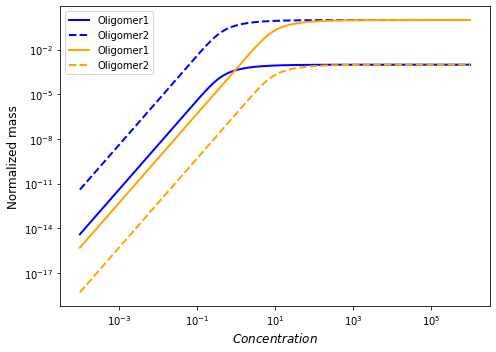

In [8]:
## Numerical solve of equilibrium oligomer population
###Figure 2B,C top row

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq

# --------------------------------------------------
# 1. Define the implicit equation
# --------------------------------------------------
def equation(x, X0, n1, n2, s1, s2):
    """
    x + n1*x*(x/s1)^(n1-1) + n2*x*(x/s2)^(n2-1) - X0 = 0
    """
    return (
        x
        + n1 * x * (x / s1)**(n1 - 1)
        + n2 * x * (x / s2)**(n2 - 1)
        - X0
    )

# --------------------------------------------------
# 2. Solve for x given X0
# --------------------------------------------------
def solve_x(X0, n1, n2, s1, s2):
    """
    Solve the equation for x in the interval [0, X0]
    """
    return brentq(
        equation,
        0.0,
        X0,
        args=(X0, n1, n2, s1, s2)
    )

# --------------------------------------------------
# 3. Sweep X0 and compute normalized quantities
# --------------------------------------------------
def compute_fractions(X0_array, n1, n2, s1, s2):
    """
    Returns:
    f1 = n1*x *(x/s1)^(n1-1) / X0
    f2 = n2*x *(x/s2)^(n2-1) / X0
    """
    f1 = np.zeros_like(X0_array)
    f2 = np.zeros_like(X0_array)

    for i, X0 in enumerate(X0_array):
        x = solve_x(X0, n1, n2, s1, s2)

        f1[i] = n1* x * (x / s1)**(n1 - 1) / X0
        f2[i] = n2* x * (x / s2)**(n2 - 1) / X0

    return f1, f2

# --------------------------------------------------
# 4. Parameters (EDIT THESE)
# --------------------------------------------------
n1 = 4
n2 = 4
s1 = 10.0
s2 = 1.0
s3 = 20.0
s4 = 200

# X0 range
X0_array = np.logspace(-4, 6, 5000)

# --------------------------------------------------
# 5. Compute results
# --------------------------------------------------
f1, f2 = compute_fractions(X0_array, n1, n2, s1, s2)
f3, f4 = compute_fractions(X0_array, n1, n2, s3, s4)
print(f1,f2)

# --------------------------------------------------
# 6. Plot
# --------------------------------------------------
plt.figure(figsize=(7, 5))

# plt.loglog(X0_array, f1, lw=2, label='OLigomer1')
# plt.loglog(X0_array, f2, lw=2, label='Oligomer2')
plt.loglog(X0_array, f1, 'b-',lw=2, label='Oligomer1')
plt.loglog(X0_array, f2, 'b--',lw=2, label='Oligomer2')
plt.loglog(X0_array, f3, color='orange',linestyle='-', lw=2, label='Oligomer1')
plt.loglog(X0_array, f4, color='orange',linestyle='--', lw=2, label='Oligomer2')

plt.xlabel(r'$Concentration$', fontsize=12)
plt.ylabel('Normalized mass', fontsize=12)
plt.legend()
plt.tight_layout()
#plt.savefig('Fig2B_oligomer_2.eps',dpi=300)
plt.show()


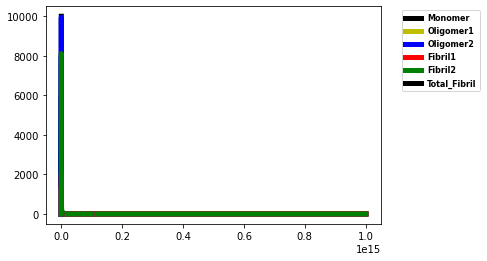

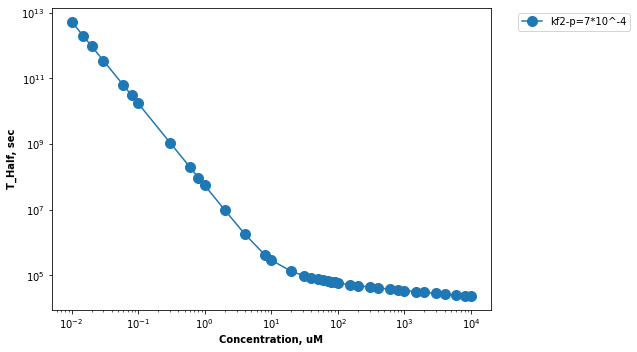

In [2]:
###### We introduce Multiple pathway-Filibrilization model 

## Figure 2B, bottom row

import matplotlib.pyplot as plt
import numpy as np
import math
from matplotlib.ticker import FormatStrFormatter
from scipy.integrate import solve_ivp
from scipy.integrate import odeint
import matplotlib.cm as cm
plt.close('all')


### Create lists for half-time, half-fibril mass and initial peptide concentration to plot half_time vs Conc plot
t50_alla=[]
fibril_alla=[]
Y0_alla=[]


for zzz in [ 1*10**(-3)]:        ## Tune the parameter of interest
    #p0 = [0Kd-p, 1kd-, 2Phi_BN, 3Nd, 4Nf1, 5Nf2, 6Phi_CR1, 7Phi_CR2,   8Kf1-p;1st-pathway, 9Kf1-;1st-pathway, 10Kf2-p;2nd-pathway, 11Kf2-;2nd-pathway, 12Kfrag, 13G1, 14G2] 
    #p0=   [0,     0,    0,       0,   4,   6,  0.01,    0.01,    1*10**(-4),        5*10**(-8),         Vkf2p,                   5*10**(-8),           0,       6,   6 ]       # Free parameters in our model 
    p0=   [0,     0,    0,       0,   4,   6,  0.001,    0.001,    zzz,        5*10**(-8),         zzz,                   5*10**(-8),           0,       6,   6 ]       # Free parameters in our model 
    yy=[0.01, 0.015, 0.02, 0.03, 0.06, 0.08, 0.1, 0.3, 0.6,0.8,1,2,4,8,10,20,31,40,50,60,70,80,90,100,150,200,300,400,600,800,1000,1500,2000,3000,4000,6000,8000,10000]                                   
    #### Discrete point initial peptide concentrations 
    n=len(yy)                                                                                                                                      #### Total discrete point concentration
    
    
    ##################################################
    # Define a function to solve all rate-mass equations
    def func0(t, u): 
        du = [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0]         # Introduce all states in our model
        #### Aproximate nf1+10 and truncate the high order dependency
        if t>0:
            if u[0]> p[6]:
                nf1plus1= u[18]  
            else:
                nf1plus1= u[18]*(u[0]/p[6])
        else:
            nf1plus1= 0     
        #### Aproximate nf2+10 and truncate the high order dependency   
        if t>0:
            if u[0]>p[7]:
                nf2plus1= u[27]
            else:
                nf2plus1= u[27]*(u[0]/p[7])
        else:
            nf2plus1= 0
         
        ### Define different terms 
        EEE1=  Kfn1*u[0]**p[4] - p[8]*u[4];                      # 1st-pathway oligomer nucleation  
        EEE2=  Kfn2*u[0]**p[5] - p[10]*u[7];                     # 2nd-pathway oligomer nucleation
        EE1=  p[4]*EEE1;                                         # monomer loss due to 1st-pathway oligomer nucleation
        EE2=  p[5]*EEE2;                                         # monomer loss due to 2st-pathway oligomer nucleation
        NNN1= (Kf1p*u[0]*u[4] - p[9]*u[10])*np.exp(-p[13])    # 1st-pathway oligomer to fibril conversion
        NNN2= (Kf2p*u[0]*u[7] - p[11]*u[19])*np.exp(-p[14])   # 2nd-pathway oligomer to fibril conversion
        NN1= (p[4]+1)* NNN1                                      # fibril mass from 1st-pathway oligomer to fibril conversion
        NN2= (p[5]+1)* NNN2                                      # fibril mass from 2nd-pathway oligomer to fibril conversion
        GG1= (Kf1p*u[0]-p[9])*u[5] +  p[9]* u[10];            # Growth and shrinking of the 1st-pathway fibril  
        GG2= (Kf2p*u[0]-p[11])*u[8] + p[11]* u[19];           # Growth and shrinking of the 2nd-pathway fibril 
        
        
        ### Introduce Fragmentation
        #JJ1= p[12]*u[6]*Fragmentation(u[6], u[5], p[4])         # fragmentation in 1st-pathway fibril
        #JJ2= p[12]*u[9]*Fragmentation(u[9], u[8], p[5])         # fragmentation in 2nd-pathway fibril
         
        ### Rate-mass equations
        du[0] = - EE1  - GG1 - NNN1 - EE2  - GG2 - NNN2                  
        du[1] = 0      
        du[2] = 0
        du[3] = 0
        du[4] = EEE1 - NNN1
        du[5] = NNN1 #+ JJ1
        du[6] = NN1 + GG1 
        du[7] = EEE2 - NNN2
        du[8] = NNN2 #+ JJ2
        du[9] = NN2 + GG2
        du[10]= (Kf1p*u[0]*u[4]*np.exp(-p[13]) -(Kf1p*u[0] + p[9]*np.exp(-p[13]))*u[10] + p[9]*u[11])
        du[11]= (Kf1p*u[0]*u[10] -(Kf1p*u[0] + p[9])*u[11] + p[9]*u[12])
        du[12]= (Kf1p*u[0]*u[11] -(Kf1p*u[0] + p[9])*u[12] + p[9]*u[13])
        du[13]= (Kf1p*u[0]*u[12] -(Kf1p*u[0] + p[9])*u[13] + p[9]*u[14])
        du[14]= (Kf1p*u[0]*u[13] -(Kf1p*u[0] + p[9])*u[14] + p[9]*u[15])
        du[15]= (Kf1p*u[0]*u[14] -(Kf1p*u[0] + p[9])*u[15] + p[9]*u[16])
        du[16]= (Kf1p*u[0]*u[15] -(Kf1p*u[0] + p[9])*u[16] + p[9]*u[17])
        du[17]= (Kf1p*u[0]*u[16] -(Kf1p*u[0] + p[9])*u[17] + p[9]*u[18])
        du[18]= (Kf1p*u[0]*u[17] -(Kf1p*u[0] + p[9])*u[18] + p[9]*nf1plus1)
        du[19]= (Kf2p*u[0]*u[7]*np.exp(-p[14]) -(Kf2p*u[0] + p[11]*np.exp(-p[14]))*u[19] + p[11]*u[20])
        du[20]= (Kf2p*u[0]*u[19] -(Kf2p*u[0] + p[11])*u[20] + p[11]*u[21])
        du[21]= (Kf2p*u[0]*u[20] -(Kf2p*u[0] + p[11])*u[21] + p[11]*u[22])
        du[22]= (Kf2p*u[0]*u[21] -(Kf2p*u[0] + p[11])*u[22] + p[11]*u[23])
        du[23]= (Kf2p*u[0]*u[22] -(Kf2p*u[0] + p[11])*u[23] + p[11]*u[24])
        du[24]= (Kf2p*u[0]*u[23] -(Kf2p*u[0] + p[11])*u[24] + p[11]*u[25])
        du[25]= (Kf2p*u[0]*u[24] -(Kf2p*u[0] + p[11])*u[25] + p[11]*u[26])
        du[26]= (Kf2p*u[0]*u[25] -(Kf2p*u[0] + p[11])*u[26] + p[11]*u[27])
        du[27]= (Kf2p*u[0]*u[26] -(Kf2p*u[0] + p[11])*u[27] + p[11]*nf2plus1)
        
        #if t>1000:
            #print(EEE1,EEE2,NNN1,NNN2,GG1,GG2,u[5],u[8])
        #if du[6]< 0 and u[0]< p[6]:
            #sigma= u[0]/p[6]
            #kdeno= sigma + p[4]+1 - (p[4]+1)*sigma
            #knum= 1 + kdeno
            #Kdf= du[6]/u[6]
            #du[10]=Kdf*u[10] - (knum/kdeno)*u[10]*du[0]/u[0]*sigma/(1-sigma)
            #du[5]= Kdf*u[5] - (1/kdeno)*u[5]*du[0]/u[0]*sigma/(1-sigma)
            
        #if u[0]< p[6]:
            #print(u[10],u[0],u[0]/p[6],u[0]/p[7],u[5],u[8],u[10]/(1-u[0]/p[6]),u[19]/(1-u[0]/p[7]),u[6],u[9],u[10]*((p[4]+1)- p[4]*(u[0]/ p[6]))/(1-u[0]/p[6])**2,u[19]*((p[5]+1)- p[5]*(u[0]/ p[7]))/(1-u[0]/p[7])**2)
            #print(du[0]/u[0],du[4]/u[4],du[5]/u[5],du[6]/u[6],du[7]/u[7],du[8]/u[8],du[9]/u[9])
        #if du[6] < 0:
            #du[5]= du[6]/u[6]*u[5]
            #du[0]=0;du[1]=0;du[2]=0;du[3]=0;du[4]=0;du[5]=0;du[6]=0;du[7]=0;du[8]=0;du[9]=0;
        return du
    
    
    ##################################################
    # Define how long we calculate (end-time) the time evolution of states for all concentrations
    x19=1*10**15; x18=1*10**14; x17=1*10**12; x16=1*10**8; x15=1*10**8; x14=1*10**7; x13=1*10**7;
    tend=[ x19, x19, x19,x18,x18,x18,x18,x17,x17,x17,x17,x16,x16,x15,x15,x15,x14,x14,x14,x14,x14,x14,x14,x14,x13,x13,x13,x13,x13,x13,x13,x13,x13,x13,x13,x13,x13,x13,x13,x13,x13,x13]
    
    ##################################################
    # Define the fragmentation function 
    def Fragmentation(x,y,z):
        if y==0:
            out=1
        elif x/y < z:
            out=0
        else:
            out=1
        return out
    ###################################################
    # Introduce lists to keep fibril-mass evolution and corresponding time
    fibril1a=[]
    time1a=[]
    oligomer1a=[]
    oligomer2a=[]
    totalfibril1a=[]
    totalfibril2a=[]
    #########################################################################
    #for i in [6, 10, 17]:#range(n):
    for i in range(n):
        y0 = [yy[i],0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0]                           ## Introduce the initial condition
        p  = p0                                                  ## parameters in our model
        Kf1p = float(f"{p[9]/p[6]:.5e}")                         ## Monomer-addition rate in 1st-pathway 
        Kf2p = float(f"{p[11]/p[7]:.5e}")                        ## Monomer-addition rate in 2nd-pathway 
        Kfn1 = float(f"{(Kf1p*(Kf1p/p[8])**(p[4]-2)):.5e}")      ## Oligomer nucleation rate in 1st-pathway 
        Kfn2 = float(f"{(Kf2p*(Kf2p/p[10])**(p[5]-2)):.5e}")     ## Oligomer nucleation rate in 2nd-pathway
        
        #tspan  = (0,tend[i])                                     ## time span between initial and final time 
        #t_eval = np.linspace(0, tend[i],10000000)                 ## time interval to record the measured calculations
        #atol = 10**(-10)                                         ## absolute tolerence
        #rtol = 10**(-10)                                         ## relative tolerence
        #sol  = solve_ivp(func0,tspan,y0, t_eval=t_eval, method ='BDF',atol=atol, rtol=rtol)
        
        tspan1 = (0,1)
        t_eval1 = np.linspace(tspan1[0], tspan1[1], 100000)
        sol1 = solve_ivp(func0, tspan1, y0, t_eval=t_eval1, method='BDF', atol=1e-10, rtol=1e-10)
            
        tspan2 = (1, 100)
        t_eval2 = np.logspace(np.log10(tspan2[0]), np.log10(tspan2[1]), 100000)
        sol2 = solve_ivp(func0, tspan2, sol1.y[:, -1], t_eval=t_eval2, method='BDF', atol=1e-10, rtol=1e-10)
        
        tspan3 = (100, 10000)
        t_eval3 = np.logspace(np.log10(tspan3[0]), np.log10(tspan3[1]), 100000)
        sol3 = solve_ivp(func0, tspan3, sol2.y[:, -1], t_eval=t_eval3, method='BDF', atol=1e-10, rtol=1e-10)
        
        tspan4 = (10000, tend[i])
        t_eval4 = np.logspace(np.log10(tspan4[0]), np.log10(tspan4[1]), 100000)
        sol4 = solve_ivp(func0, tspan4, sol3.y[:, -1], t_eval=t_eval4, method='BDF', atol=1e-10, rtol=1e-10)
            
        sol_t = np.concatenate((sol1.t, sol2.t, sol3.t, sol4.t))
        sol_y = np.hstack((sol1.y, sol2.y, sol3.y, sol4.y))
           
        fibril1a.append(sol_y[6] + sol_y[9] )                      ## append the fibril mass evolution in the list
        time1a.append(sol_t)                                       ## append the time-measured in the list
        
        oligomer1a.append(p[4]*sol_y[4])
        oligomer2a.append(p[5]*sol_y[7])
        totalfibril1a.append(sol_y[6])
        totalfibril2a.append(sol_y[9])
        
        
        #print(sol.y[0])
        #print(p[4]*sol.y[7])
        #print(sol.y[9])
        
        plt.plot(sol_t,sol_y[0, :],'k',linewidth = 5)
        plt.plot(sol_t, p[4]*sol_y[4, :],'y',linewidth = 5)
        plt.plot(sol_t, p[5]*sol_y[7, :],'b',linewidth = 5)
        #plt.plot(sol_t, sol_y[5, :],'r',linewidth = 5)
        #plt.plot(sol_t, sol_y[8, :],'g',linewidth = 5)
        plt.plot(sol_t, sol_y[6, :],'r',linewidth = 5)
        plt.plot(sol_t, sol_y[9, :],'g',linewidth = 5)
        #plt.plot(sol_t, sol_y[6, :] + sol_y[9, :],'purple',linewidth = 5)
        #plt.ylabel('Mass concentration (\u03bcM)',fontsize=15)
        #plt.xlabel('Time (s)',fontsize=15)
        #plt.xticks(fontsize=10)
        #plt.yticks(fontsize=10)
        #myleg = plt.legend(['Monomer','Oligomer','Fibril'],loc='upper left',prop = {'size':8}, bbox_to_anchor=(0.05,1.15), ncol=6, frameon=False )
        #plt.gca().ticklabel_format(style='sci', axis='x', scilimits=(0,0))
       
        #if i ==0:
            #plt.text(0.85, 0.8, " CNT w/D  ", fontsize=12, ha='center', va='center', transform=plt.gca().transAxes)
            #plt.savefig('fig2a_C.eps',dpi=300)
        #if i ==9:
            #plt.text(0.85, 0.8, " CNT w/D  ", fontsize=12, ha='center', va='center', transform=plt.gca().transAxes)
            #plt.savefig('fig2b_C.eps',dpi=300)
        #if i==13:
            #plt.text(0.85, 0.8, " CNT w/D  ", fontsize=12, ha='center', va='center', transform=plt.gca().transAxes)
            #plt.savefig('fig2c_C.eps',dpi=300)
        #plt.xscale('log')
        #plt.title('Linear Scale')
        #if i==0:
            #plt.text(0.000001, 5, 'I', fontsize = 22)
        #if i==1:
            #plt.text(0.000001, 40, 'II', fontsize = 22)
        #if i==2:
            #plt.text(0.000001, 27, 'III', fontsize = 22)
        #plt.subplot(1, 2, 2)
        #plt.plot(sol.t,sol.y[0, :],'k',linewidth = 5)
        #plt.plot(sol.t,p[0]*p[1] *sol.y[1, :],'y',linewidth = 5)
        #plt.plot(sol.t,sol.y[2, :],'r',linewidth = 5)
        #plt.plot(sol.t, sol.y[3, :] ,'b',linewidth = 5)
        #plt.plot(sol.t,sol.y[4, :],'g',linewidth = 5)
        #plt.xlim(0.00001,1)
        #plt.xlabel('Time', fontweight = 'bold')
        #plt.ylabel('Mass', fontweight = 'bold')
        #plt.xscale('log')
        #plt.title('Linear Scale')
        myleg = plt.legend(['Monomer','Oligomer1','Oligomer2', 'Fibril1','Fibril2','Total_Fibril' ],loc='upper left',prop = {'size':8,'weight':'bold'}, bbox_to_anchor=(1.05,1)) 
        #plt.tight_layout()
        #plt.xlim(1,tend[i])
        #plt.xlim(0,10000000)
        #plt.savefig(f'variation_nf2_{y0[0]}_linear.eps', dpi=300)
        #plt.show()
    
    ###########################################################################################
    # Fibril Mass fraction vs time for different concentration     
    

#     import matplotlib.pyplot as plt
#     import matplotlib.cm as cm

#     Y0 = yy  # Initial peptide concentrations
#     num_curves = len(Y0)
#     colormap = cm.get_cmap('plasma')  # Choose a color gradient map
    
#     plt.figure(figsize=(8, 5))
#     fibril_lista = [[element / Y0[p] for element in sublist] for p, sublist in enumerate(fibril1a)]
#     for idx, (sublist1, sublist2) in enumerate(zip(time1a, fibril_lista)):
#         color = colormap(idx / (num_curves - 1))  # Normalize index to [0, 1]
#         plt.plot(sublist1, sublist2, color=color, label=f'C={Y0[idx]}')
    
#     plt.xscale('log')
#     plt.xlabel('Time, s', fontweight='bold')
#     plt.ylabel('Fibril mass fraction', fontweight='bold')
#     plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2, fontsize=9)
#     plt.tight_layout()
#     plt.show()
    
#     plt.figure(figsize=(8, 5))
#     oligomer_list1a = [[element / Y0[p] for element in sublist] for p, sublist in enumerate(oligomer1a)]
#     for idx, (sublist1, sublist2) in enumerate(zip(time1a, oligomer_list1a)):
#         color = colormap(idx / (num_curves - 1))  # Normalize index to [0, 1]
#         plt.plot(sublist1, sublist2, color=color, label=f'C={Y0[idx]}')
    
#     plt.xscale('log')
#     plt.xlabel('Time, s', fontweight='bold')
#     plt.ylabel('Oligomer_1 mass fraction', fontweight='bold')
#     plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2, fontsize=9)
#     plt.tight_layout()
#     #plt.show()
    
#     #plt.figure(figsize=(8, 5))
#     oligomer_list2a = [[element / Y0[p] for element in sublist] for p, sublist in enumerate(oligomer2a)]
#     for idx, (sublist1, sublist2) in enumerate(zip(time1a, oligomer_list2a)):
#         color = colormap(idx / (num_curves - 1))  # Normalize index to [0, 1]
#         plt.plot(sublist1, sublist2, '--', color=color, label=f'C={Y0[idx]}')
    
#     plt.xscale('log')
#     plt.xlabel('Time, s', fontweight='bold')
#     plt.ylabel('Oligomer_2 mass fraction', fontweight='bold')
#     plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2, fontsize=9)
#     plt.tight_layout()
#     plt.show()
    
#     plt.figure(figsize=(8, 5))
#     fibril_list1a = [[element / Y0[p] for element in sublist] for p, sublist in enumerate(totalfibril1a)]
#     for idx, (sublist1, sublist2) in enumerate(zip(time1a, fibril_list1a)):
#         color = colormap(idx / (num_curves - 1))  # Normalize index to [0, 1]
#         plt.plot(sublist1, sublist2, color=color, label=f'C={Y0[idx]}')
    
#     plt.xscale('log')
#     plt.xlabel('Time, s', fontweight='bold')
#     plt.ylabel('fibril_1 mass fraction', fontweight='bold')
#     plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2, fontsize=9)
#     plt.tight_layout()
    #plt.show()
    
#     #plt.figure(figsize=(8, 5))
#     fibril_list2a = [[element / Y0[p] for element in sublist] for p, sublist in enumerate(totalfibril2a)]
#     for idx, (sublist1, sublist2) in enumerate(zip(time1a, fibril_list2a)):
#         color = colormap(idx / (num_curves - 1))  # Normalize index to [0, 1]
#         plt.plot(sublist1, sublist2,'--', color=color, label=f'C={Y0[idx]}')
    
#     #plt.xscale('log')
#     plt.xlabel('Time, s', fontweight='bold')
#     plt.ylabel('fibril_2 mass fraction', fontweight='bold')
#     plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2, fontsize=9)
#     plt.tight_layout()
#     plt.show()
    

#     ###########################################################################################   
    #Find T_Half for each concentration
    t50=[]   
    fibril50=[]
    Y050=[]
    Y0= yy 
    for i in range(n):
        cutoff_value = (Y0[i]-p[7])/2      #specified cutoff value
        list_I=fibril1a[i]              
        list_II=time1a[i]
        # Iterate through elements in List I
        for value_I, value_II in zip(list_I, list_II):
            if value_I >= cutoff_value:
                selected_value_I = value_I
                selected_value_II = value_II
                fibril50.append(selected_value_I)
                t50.append(selected_value_II)
                Y050.append(Y0[i])
                break                      # Break out of the loop once the condition is met
    t50_alla.append(t50)
    fibril_alla.append(fibril50)
    Y0_alla.append(Y050)
   ############################################################################################# 
 
### Plot the T_half vs Concentration for the given different parameter value
### Plot the T_half vs Concentration for the given different parameter value
markers = ['o', 's', '^','D','*']  # circle, square, triangle

plt.figure(figsize=(9, 5))
for i, (sublist1, sublist2) in enumerate(zip(Y0_alla, t50_alla)):
    plt.loglog(sublist1, sublist2, marker=markers[i], markersize=10,linestyle='-')  # Different marker for each curve
plt.ylabel('T_Half, sec', fontweight='bold')
plt.xlabel('Concentration, uM', fontweight='bold')
# plt.title('For Different off-pathway \n monomer-oligomer dissociation rate')
plt.legend(['kf2-p=7*10^-4', 'kf2-p=7*10^-5', 'kf2-p=7*10^-6','kf2-p=7*10^-7','kf2-p=7*10^-8'], bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
#plt.savefig('Figure2B_halfTime_1.eps', dpi=300)
plt.show()  

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


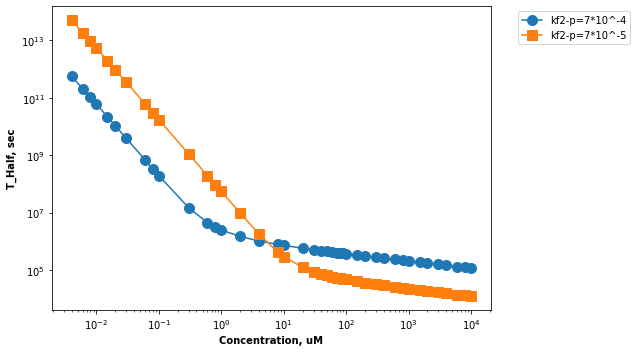

In [3]:
###### We introduce Multiple pathway-Filibrilization model 

## Figure 2C bottom row

import matplotlib.pyplot as plt
import numpy as np
import math
from matplotlib.ticker import FormatStrFormatter
from scipy.integrate import solve_ivp
from scipy.integrate import odeint
import matplotlib.cm as cm
plt.close('all')


### Create lists for half-time, half-fibril mass and initial peptide concentration to plot half_time vs Conc plot
t50_alla=[]
fibril_alla=[]
Y0_alla=[]


for zzz in [ 5*10**(-4), 1*10**(-3)]:        ## Tune the parameter of interest
    if zzz== 5*10**(-4):
        zzzz=5*10**(-5)
    else:
        zzzz=1*10**(-2)
    #p0 = [0Kd-p, 1kd-, 2Phi_BN, 3Nd, 4Nf1, 5Nf2, 6Phi_CR1, 7Phi_CR2,   8Kf1-p;1st-pathway, 9Kf1-;1st-pathway, 10Kf2-p;2nd-pathway, 11Kf2-;2nd-pathway, 12Kfrag, 13G1, 14G2] 
    #p0=   [0,     0,    0,       0,   4,   6,  0.01,    0.01,    1*10**(-4),        5*10**(-8),         Vkf2p,                   5*10**(-8),           0,       6,   6 ]       # Free parameters in our model 
    p0=   [0,     0,    0,       0,   4,   4,  0.001,    0.001,    zzz,        5*10**(-8),         zzzz,                   5*10**(-8),           0,       6,   6 ]       # Free parameters in our model 
    yy=[0.004,0.006,0.008, 0.01, 0.015, 0.02, 0.03, 0.06, 0.08, 0.1, 0.3, 0.6,0.8,1,2,4,8,10,20,31,40,50,60,70,80,90,100,150,200,300,400,600,800,1000,1500,2000,3000,4000,6000,8000,10000]                                  
    #### Discrete point initial peptide concentrations 
    n=len(yy)                                                                                                                                      #### Total discrete point concentration
    
    
    ##################################################
    # Define a function to solve all rate-mass equations
    def func0(t, u): 
        du = [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0]         # Introduce all states in our model
        #### Aproximate nf1+10 and truncate the high order dependency
        if t>0:
            if u[0]> p[6]:
                nf1plus1= u[18]  
            else:
                nf1plus1= u[18]*(u[0]/p[6])
        else:
            nf1plus1= 0     
        #### Aproximate nf2+10 and truncate the high order dependency   
        if t>0:
            if u[0]>p[7]:
                nf2plus1= u[27]
            else:
                nf2plus1= u[27]*(u[0]/p[7])
        else:
            nf2plus1= 0
         
        ### Define different terms 
        EEE1=  Kfn1*u[0]**p[4] - p[8]*u[4];                      # 1st-pathway oligomer nucleation  
        EEE2=  Kfn2*u[0]**p[5] - p[10]*u[7];                     # 2nd-pathway oligomer nucleation
        EE1=  p[4]*EEE1;                                         # monomer loss due to 1st-pathway oligomer nucleation
        EE2=  p[5]*EEE2;                                         # monomer loss due to 2st-pathway oligomer nucleation
        NNN1= (Kf1p*u[0]*u[4] - p[9]*u[10])*np.exp(-p[13])    # 1st-pathway oligomer to fibril conversion
        NNN2= (Kf2p*u[0]*u[7] - p[11]*u[19])*np.exp(-p[14])   # 2nd-pathway oligomer to fibril conversion
        NN1= (p[4]+1)* NNN1                                      # fibril mass from 1st-pathway oligomer to fibril conversion
        NN2= (p[5]+1)* NNN2                                      # fibril mass from 2nd-pathway oligomer to fibril conversion
        GG1= (Kf1p*u[0]-p[9])*u[5] +  p[9]* u[10];            # Growth and shrinking of the 1st-pathway fibril  
        GG2= (Kf2p*u[0]-p[11])*u[8] + p[11]* u[19];           # Growth and shrinking of the 2nd-pathway fibril 
        
        
        ### Introduce Fragmentation
        #JJ1= p[12]*u[6]*Fragmentation(u[6], u[5], p[4])         # fragmentation in 1st-pathway fibril
        #JJ2= p[12]*u[9]*Fragmentation(u[9], u[8], p[5])         # fragmentation in 2nd-pathway fibril
         
        ### Rate-mass equations
        du[0] = - EE1  - GG1 - NNN1 - EE2  - GG2 - NNN2                  
        du[1] = 0      
        du[2] = 0
        du[3] = 0
        du[4] = EEE1 - NNN1
        du[5] = NNN1 #+ JJ1
        du[6] = NN1 + GG1 
        du[7] = EEE2 - NNN2
        du[8] = NNN2 #+ JJ2
        du[9] = NN2 + GG2
        du[10]= (Kf1p*u[0]*u[4]*np.exp(-p[13]) -(Kf1p*u[0] + p[9]*np.exp(-p[13]))*u[10] + p[9]*u[11])
        du[11]= (Kf1p*u[0]*u[10] -(Kf1p*u[0] + p[9])*u[11] + p[9]*u[12])
        du[12]= (Kf1p*u[0]*u[11] -(Kf1p*u[0] + p[9])*u[12] + p[9]*u[13])
        du[13]= (Kf1p*u[0]*u[12] -(Kf1p*u[0] + p[9])*u[13] + p[9]*u[14])
        du[14]= (Kf1p*u[0]*u[13] -(Kf1p*u[0] + p[9])*u[14] + p[9]*u[15])
        du[15]= (Kf1p*u[0]*u[14] -(Kf1p*u[0] + p[9])*u[15] + p[9]*u[16])
        du[16]= (Kf1p*u[0]*u[15] -(Kf1p*u[0] + p[9])*u[16] + p[9]*u[17])
        du[17]= (Kf1p*u[0]*u[16] -(Kf1p*u[0] + p[9])*u[17] + p[9]*u[18])
        du[18]= (Kf1p*u[0]*u[17] -(Kf1p*u[0] + p[9])*u[18] + p[9]*nf1plus1)
        du[19]= (Kf2p*u[0]*u[7]*np.exp(-p[14]) -(Kf2p*u[0] + p[11]*np.exp(-p[14]))*u[19] + p[11]*u[20])
        du[20]= (Kf2p*u[0]*u[19] -(Kf2p*u[0] + p[11])*u[20] + p[11]*u[21])
        du[21]= (Kf2p*u[0]*u[20] -(Kf2p*u[0] + p[11])*u[21] + p[11]*u[22])
        du[22]= (Kf2p*u[0]*u[21] -(Kf2p*u[0] + p[11])*u[22] + p[11]*u[23])
        du[23]= (Kf2p*u[0]*u[22] -(Kf2p*u[0] + p[11])*u[23] + p[11]*u[24])
        du[24]= (Kf2p*u[0]*u[23] -(Kf2p*u[0] + p[11])*u[24] + p[11]*u[25])
        du[25]= (Kf2p*u[0]*u[24] -(Kf2p*u[0] + p[11])*u[25] + p[11]*u[26])
        du[26]= (Kf2p*u[0]*u[25] -(Kf2p*u[0] + p[11])*u[26] + p[11]*u[27])
        du[27]= (Kf2p*u[0]*u[26] -(Kf2p*u[0] + p[11])*u[27] + p[11]*nf2plus1)
        
        #if t>1000:
            #print(EEE1,EEE2,NNN1,NNN2,GG1,GG2,u[5],u[8])
        #if du[6]< 0 and u[0]< p[6]:
            #sigma= u[0]/p[6]
            #kdeno= sigma + p[4]+1 - (p[4]+1)*sigma
            #knum= 1 + kdeno
            #Kdf= du[6]/u[6]
            #du[10]=Kdf*u[10] - (knum/kdeno)*u[10]*du[0]/u[0]*sigma/(1-sigma)
            #du[5]= Kdf*u[5] - (1/kdeno)*u[5]*du[0]/u[0]*sigma/(1-sigma)
            
        #if u[0]< p[6]:
            #print(u[10],u[0],u[0]/p[6],u[0]/p[7],u[5],u[8],u[10]/(1-u[0]/p[6]),u[19]/(1-u[0]/p[7]),u[6],u[9],u[10]*((p[4]+1)- p[4]*(u[0]/ p[6]))/(1-u[0]/p[6])**2,u[19]*((p[5]+1)- p[5]*(u[0]/ p[7]))/(1-u[0]/p[7])**2)
            #print(du[0]/u[0],du[4]/u[4],du[5]/u[5],du[6]/u[6],du[7]/u[7],du[8]/u[8],du[9]/u[9])
        #if du[6] < 0:
            #du[5]= du[6]/u[6]*u[5]
            #du[0]=0;du[1]=0;du[2]=0;du[3]=0;du[4]=0;du[5]=0;du[6]=0;du[7]=0;du[8]=0;du[9]=0;
        return du
    
    
    ##################################################
    # Define how long we calculate (end-time) the time evolution of states for all concentrations
    x19=1*10**15; x18=1*10**14; x17=1*10**12; x16=1*10**8; x15=1*10**8; x14=1*10**7; x13=1*10**7;
    tend=[x19, x19, x19, x19, x19, x19,x18,x18,x18,x18,x17,x17,x17,x17,x16,x16,x15,x15,x15,x14,x14,x14,x14,x14,x14,x14,x14,x13,x13,x13,x13,x13,x13,x13,x13,x13,x13,x13,x13,x13,x13,x13,x13,x13,x13]
    
    ##################################################
    # Define the fragmentation function 
    def Fragmentation(x,y,z):
        if y==0:
            out=1
        elif x/y < z:
            out=0
        else:
            out=1
        return out
    ###################################################
    # Introduce lists to keep fibril-mass evolution and corresponding time
    fibril1a=[]
    time1a=[]
    oligomer1a=[]
    oligomer2a=[]
    totalfibril1a=[]
    totalfibril2a=[]
    #########################################################################
    #for i in [6, 10, 17]:#range(n):
    for i in range(n):
        y0 = [yy[i],0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0]                           ## Introduce the initial condition
        p  = p0                                                  ## parameters in our model
        Kf1p = float(f"{p[9]/p[6]:.5e}")                         ## Monomer-addition rate in 1st-pathway 
        Kf2p = float(f"{p[11]/p[7]:.5e}")                        ## Monomer-addition rate in 2nd-pathway 
        Kfn1 = float(f"{(Kf1p*(Kf1p/p[8])**(p[4]-2)):.5e}")      ## Oligomer nucleation rate in 1st-pathway 
        Kfn2 = float(f"{(Kf2p*(Kf2p/p[10])**(p[5]-2)):.5e}")     ## Oligomer nucleation rate in 2nd-pathway
        
        #tspan  = (0,tend[i])                                     ## time span between initial and final time 
        #t_eval = np.linspace(0, tend[i],10000000)                 ## time interval to record the measured calculations
        #atol = 10**(-10)                                         ## absolute tolerence
        #rtol = 10**(-10)                                         ## relative tolerence
        #sol  = solve_ivp(func0,tspan,y0, t_eval=t_eval, method ='BDF',atol=atol, rtol=rtol)
        
        tspan1 = (0,1)
        t_eval1 = np.linspace(tspan1[0], tspan1[1], 100000)
        sol1 = solve_ivp(func0, tspan1, y0, t_eval=t_eval1, method='BDF', atol=1e-10, rtol=1e-10)
            
        tspan2 = (1, 100)
        t_eval2 = np.logspace(np.log10(tspan2[0]), np.log10(tspan2[1]), 100000)
        sol2 = solve_ivp(func0, tspan2, sol1.y[:, -1], t_eval=t_eval2, method='BDF', atol=1e-10, rtol=1e-10)
        
        tspan3 = (100, 10000)
        t_eval3 = np.logspace(np.log10(tspan3[0]), np.log10(tspan3[1]), 100000)
        sol3 = solve_ivp(func0, tspan3, sol2.y[:, -1], t_eval=t_eval3, method='BDF', atol=1e-10, rtol=1e-10)
        
        tspan4 = (10000, tend[i])
        t_eval4 = np.logspace(np.log10(tspan4[0]), np.log10(tspan4[1]), 100000)
        sol4 = solve_ivp(func0, tspan4, sol3.y[:, -1], t_eval=t_eval4, method='BDF', atol=1e-10, rtol=1e-10)
            
        sol_t = np.concatenate((sol1.t, sol2.t, sol3.t, sol4.t))
        sol_y = np.hstack((sol1.y, sol2.y, sol3.y, sol4.y))
           
        fibril1a.append(sol_y[6] + sol_y[9] )                      ## append the fibril mass evolution in the list
        time1a.append(sol_t)                                       ## append the time-measured in the list
        
        oligomer1a.append(p[4]*sol_y[4])
        oligomer2a.append(p[5]*sol_y[7])
        totalfibril1a.append(sol_y[6])
        totalfibril2a.append(sol_y[9])
        
        
        #print(sol.y[0])
        #print(p[4]*sol.y[7])
        #print(sol.y[9])
        
#         plt.plot(sol_t,sol_y[0, :],'k',linewidth = 5)
#         plt.plot(sol_t, p[4]*sol_y[4, :],'y',linewidth = 5)
#         plt.plot(sol_t, p[5]*sol_y[7, :],'b',linewidth = 5)
#         #plt.plot(sol_t, sol_y[5, :],'r',linewidth = 5)
#         #plt.plot(sol_t, sol_y[8, :],'g',linewidth = 5)
#         plt.plot(sol_t, sol_y[6, :],'r',linewidth = 5)
#         plt.plot(sol_t, sol_y[9, :],'g',linewidth = 5)
        #plt.plot(sol_t, sol_y[6, :] + sol_y[9, :],'purple',linewidth = 5)
        #plt.ylabel('Mass concentration (\u03bcM)',fontsize=15)
        #plt.xlabel('Time (s)',fontsize=15)
        #plt.xticks(fontsize=10)
        #plt.yticks(fontsize=10)
        #myleg = plt.legend(['Monomer','Oligomer','Fibril'],loc='upper left',prop = {'size':8}, bbox_to_anchor=(0.05,1.15), ncol=6, frameon=False )
        #plt.gca().ticklabel_format(style='sci', axis='x', scilimits=(0,0))
       
        #if i ==0:
            #plt.text(0.85, 0.8, " CNT w/D  ", fontsize=12, ha='center', va='center', transform=plt.gca().transAxes)
            #plt.savefig('fig2a_C.eps',dpi=300)
        #if i ==9:
            #plt.text(0.85, 0.8, " CNT w/D  ", fontsize=12, ha='center', va='center', transform=plt.gca().transAxes)
            #plt.savefig('fig2b_C.eps',dpi=300)
        #if i==13:
            #plt.text(0.85, 0.8, " CNT w/D  ", fontsize=12, ha='center', va='center', transform=plt.gca().transAxes)
            #plt.savefig('fig2c_C.eps',dpi=300)
        #plt.xscale('log')
        #plt.title('Linear Scale')
        #if i==0:
            #plt.text(0.000001, 5, 'I', fontsize = 22)
        #if i==1:
            #plt.text(0.000001, 40, 'II', fontsize = 22)
        #if i==2:
            #plt.text(0.000001, 27, 'III', fontsize = 22)
        #plt.subplot(1, 2, 2)
        #plt.plot(sol.t,sol.y[0, :],'k',linewidth = 5)
        #plt.plot(sol.t,p[0]*p[1] *sol.y[1, :],'y',linewidth = 5)
        #plt.plot(sol.t,sol.y[2, :],'r',linewidth = 5)
        #plt.plot(sol.t, sol.y[3, :] ,'b',linewidth = 5)
        #plt.plot(sol.t,sol.y[4, :],'g',linewidth = 5)
        #plt.xlim(0.00001,1)
        #plt.xlabel('Time', fontweight = 'bold')
        #plt.ylabel('Mass', fontweight = 'bold')
        #plt.xscale('log')
        #plt.title('Linear Scale')
        #myleg = plt.legend(['Monomer','Oligomer1','Oligomer2', 'Fibril1','Fibril2','Total_Fibril' ],loc='upper left',prop = {'size':8,'weight':'bold'}, bbox_to_anchor=(1.05,1)) 
        #plt.tight_layout()
        #plt.xlim(1,tend[i])
        #plt.xlim(0,10000000)
        #plt.savefig(f'variation_nf2_{y0[0]}_linear.eps', dpi=300)
        #plt.show()
    
    ###########################################################################################
    # Fibril Mass fraction vs time for different concentration     
    

#     import matplotlib.pyplot as plt
#     import matplotlib.cm as cm

#     Y0 = yy  # Initial peptide concentrations
#     num_curves = len(Y0)
#     colormap = cm.get_cmap('plasma')  # Choose a color gradient map
    
#     plt.figure(figsize=(8, 5))
#     fibril_lista = [[element / Y0[p] for element in sublist] for p, sublist in enumerate(fibril1a)]
#     for idx, (sublist1, sublist2) in enumerate(zip(time1a, fibril_lista)):
#         color = colormap(idx / (num_curves - 1))  # Normalize index to [0, 1]
#         plt.plot(sublist1, sublist2, color=color, label=f'C={Y0[idx]}')
    
#     plt.xscale('log')
#     plt.xlabel('Time, s', fontweight='bold')
#     plt.ylabel('Fibril mass fraction', fontweight='bold')
#     plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2, fontsize=9)
#     plt.tight_layout()
#     plt.show()
    
#     plt.figure(figsize=(8, 5))
#     oligomer_list1a = [[element / Y0[p] for element in sublist] for p, sublist in enumerate(oligomer1a)]
#     for idx, (sublist1, sublist2) in enumerate(zip(time1a, oligomer_list1a)):
#         color = colormap(idx / (num_curves - 1))  # Normalize index to [0, 1]
#         plt.plot(sublist1, sublist2, color=color, label=f'C={Y0[idx]}')
    
#     plt.xscale('log')
#     plt.xlabel('Time, s', fontweight='bold')
#     plt.ylabel('Oligomer_1 mass fraction', fontweight='bold')
#     plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2, fontsize=9)
#     plt.tight_layout()
#     #plt.show()
    
#     #plt.figure(figsize=(8, 5))
#     oligomer_list2a = [[element / Y0[p] for element in sublist] for p, sublist in enumerate(oligomer2a)]
#     for idx, (sublist1, sublist2) in enumerate(zip(time1a, oligomer_list2a)):
#         color = colormap(idx / (num_curves - 1))  # Normalize index to [0, 1]
#         plt.plot(sublist1, sublist2, '--', color=color, label=f'C={Y0[idx]}')
    
#     plt.xscale('log')
#     plt.xlabel('Time, s', fontweight='bold')
#     plt.ylabel('Oligomer_2 mass fraction', fontweight='bold')
#     plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2, fontsize=9)
#     plt.tight_layout()
#     plt.show()
    
#     plt.figure(figsize=(8, 5))
#     fibril_list1a = [[element / Y0[p] for element in sublist] for p, sublist in enumerate(totalfibril1a)]
#     for idx, (sublist1, sublist2) in enumerate(zip(time1a, fibril_list1a)):
#         color = colormap(idx / (num_curves - 1))  # Normalize index to [0, 1]
#         plt.plot(sublist1, sublist2, color=color, label=f'C={Y0[idx]}')
    
#     plt.xscale('log')
#     plt.xlabel('Time, s', fontweight='bold')
#     plt.ylabel('fibril_1 mass fraction', fontweight='bold')
#     plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2, fontsize=9)
#     plt.tight_layout()
    #plt.show()
    
#     #plt.figure(figsize=(8, 5))
#     fibril_list2a = [[element / Y0[p] for element in sublist] for p, sublist in enumerate(totalfibril2a)]
#     for idx, (sublist1, sublist2) in enumerate(zip(time1a, fibril_list2a)):
#         color = colormap(idx / (num_curves - 1))  # Normalize index to [0, 1]
#         plt.plot(sublist1, sublist2,'--', color=color, label=f'C={Y0[idx]}')
    
#     #plt.xscale('log')
#     plt.xlabel('Time, s', fontweight='bold')
#     plt.ylabel('fibril_2 mass fraction', fontweight='bold')
#     plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2, fontsize=9)
#     plt.tight_layout()
#     plt.show()
    

#     ###########################################################################################   
    #Find T_Half for each concentration
    t50=[]   
    fibril50=[]
    Y050=[]
    Y0= yy 
    for i in range(n):
        cutoff_value = (Y0[i]-p[7])/2      #specified cutoff value
        list_I=fibril1a[i]              
        list_II=time1a[i]
        # Iterate through elements in List I
        for value_I, value_II in zip(list_I, list_II):
            if value_I >= cutoff_value:
                selected_value_I = value_I
                selected_value_II = value_II
                fibril50.append(selected_value_I)
                t50.append(selected_value_II)
                Y050.append(Y0[i])
                break                      # Break out of the loop once the condition is met
    t50_alla.append(t50)
    fibril_alla.append(fibril50)
    Y0_alla.append(Y050)
   ############################################################################################# 
 
### Plot the T_half vs Concentration for the given different parameter value
### Plot the T_half vs Concentration for the given different parameter value
markers = ['o', 's', '^','D','*']  # circle, square, triangle

plt.figure(figsize=(9, 5))
for i, (sublist1, sublist2) in enumerate(zip(Y0_alla, t50_alla)):
    plt.loglog(sublist1, sublist2, marker=markers[i], markersize=10,linestyle='-')  # Different marker for each curve
plt.ylabel('T_Half, sec', fontweight='bold')
plt.xlabel('Concentration, uM', fontweight='bold')
# plt.title('For Different off-pathway \n monomer-oligomer dissociation rate')
plt.legend(['kf2-p=7*10^-4', 'kf2-p=7*10^-5', 'kf2-p=7*10^-6','kf2-p=7*10^-7','kf2-p=7*10^-8'], bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('Figure2B_halfTime_2.eps', dpi=300)
plt.show()  

6
[0, 0, 0, 0, 4, 6, 0.01, 0.01, 0.0001, 5e-08, 0.0001, 5e-08, 0, 6, 6]


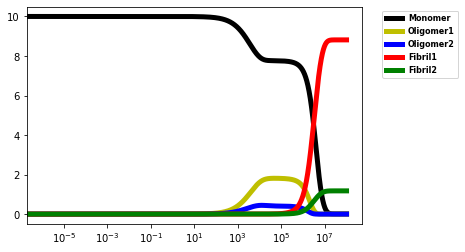

[array([0.00000000e+00, 1.25653577e-20, 2.51307154e-20, ...,
       8.81396336e+00, 8.81396336e+00, 8.81396336e+00])]
[array([0.00000000e+00, 4.39787509e-21, 8.79575019e-21, ...,
       1.17603664e+00, 1.17603664e+00, 1.17603664e+00])]
6
[0, 0, 0, 0, 4, 6, 0.01, 0.01, 0.0001, 5e-08, 0.0001, 5e-08, 0, 6, 6]


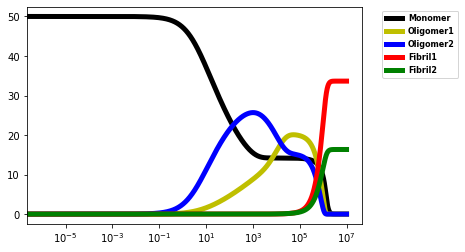

[array([0.00000000e+00, 1.25653577e-20, 2.51307154e-20, ...,
       8.81396336e+00, 8.81396336e+00, 8.81396336e+00]), array([0.00000000e+00, 6.65495295e-19, 1.33099059e-18, ...,
       3.36423876e+01, 3.36423876e+01, 3.36423876e+01])]
[array([0.00000000e+00, 4.39787509e-21, 8.79575019e-21, ...,
       1.17603664e+00, 1.17603664e+00, 1.17603664e+00]), array([0.00000000e+00, 5.82308175e-18, 1.16461635e-17, ...,
       1.63476125e+01, 1.63476125e+01, 1.63476125e+01])]
6
[0, 0, 0, 0, 4, 6, 0.01, 0.01, 0.0001, 5e-08, 0.0001, 5e-08, 0, 6, 6]


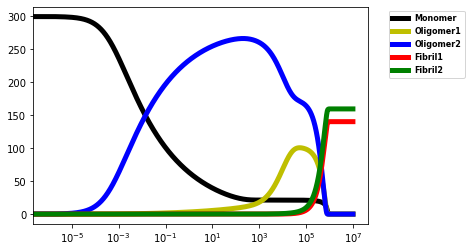

[array([0.00000000e+00, 1.25653577e-20, 2.51307154e-20, ...,
       8.81396336e+00, 8.81396336e+00, 8.81396336e+00]), array([0.00000000e+00, 6.65495295e-19, 1.33099059e-18, ...,
       3.36423876e+01, 3.36423876e+01, 3.36423876e+01]), array([0.00000000e+00, 9.40306606e-16, 3.75776258e-15, ...,
       1.40326858e+02, 1.40326858e+02, 1.40326858e+02])]
[array([0.00000000e+00, 4.39787509e-21, 8.79575019e-21, ...,
       1.17603664e+00, 1.17603664e+00, 1.17603664e+00]), array([0.00000000e+00, 5.82308175e-18, 1.16461635e-17, ...,
       1.63476125e+01, 1.63476125e+01, 1.63476125e+01]), array([0.00000000e+00, 2.96105839e-13, 1.18297527e-12, ...,
       1.59663145e+02, 1.59663145e+02, 1.59663145e+02])]
3.98
[0, 0, 0, 0, 4, 6, 0.01, 0.01, 0.0001, 5e-08, 0.0001, 5e-08, 0, 6, 3.98]


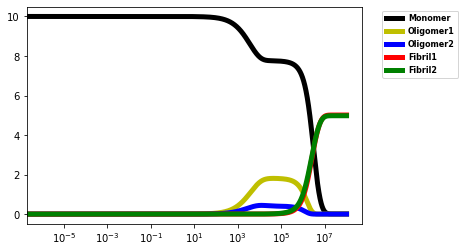

[array([0.00000000e+00, 1.25653577e-20, 2.51307154e-20, ...,
       5.01235243e+00, 5.01235243e+00, 5.01235243e+00])]
[array([0.00000000e+00, 3.31526115e-20, 6.63052229e-20, ...,
       4.97764757e+00, 4.97764757e+00, 4.97764757e+00])]
5.28
[0, 0, 0, 0, 4, 6, 0.01, 0.01, 0.0001, 5e-08, 0.0001, 5e-08, 0, 6, 5.28]


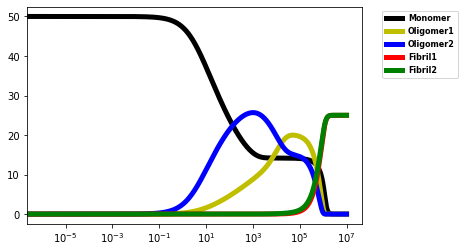

[array([0.00000000e+00, 1.25653577e-20, 2.51307154e-20, ...,
       5.01235243e+00, 5.01235243e+00, 5.01235243e+00]), array([0.00000000e+00, 6.65495295e-19, 1.33099059e-18, ...,
       2.49834470e+01, 2.49834470e+01, 2.49834470e+01])]
[array([0.00000000e+00, 3.31526115e-20, 6.63052229e-20, ...,
       4.97764757e+00, 4.97764757e+00, 4.97764757e+00]), array([0.00000000e+00, 1.19631325e-17, 2.39262651e-17, ...,
       2.50065532e+01, 2.50065532e+01, 2.50065532e+01])]
6.13
[0, 0, 0, 0, 4, 6, 0.01, 0.01, 0.0001, 5e-08, 0.0001, 5e-08, 0, 6, 6.13]


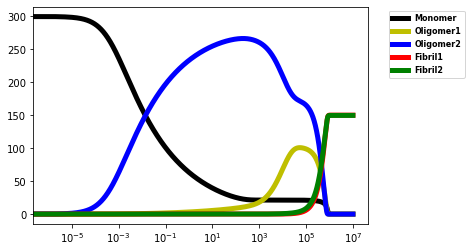

[array([0.00000000e+00, 1.25653577e-20, 2.51307154e-20, ...,
       5.01235243e+00, 5.01235243e+00, 5.01235243e+00]), array([0.00000000e+00, 6.65495295e-19, 1.33099059e-18, ...,
       2.49834470e+01, 2.49834470e+01, 2.49834470e+01]), array([0.00000000e+00, 9.40306606e-16, 3.75776258e-15, ...,
       1.50183974e+02, 1.50183974e+02, 1.50183974e+02])]
[array([0.00000000e+00, 3.31526115e-20, 6.63052229e-20, ...,
       4.97764757e+00, 4.97764757e+00, 4.97764757e+00]), array([0.00000000e+00, 1.19631325e-17, 2.39262651e-17, ...,
       2.50065532e+01, 2.50065532e+01, 2.50065532e+01]), array([0.00000000e+00, 2.60009184e-13, 1.03876518e-12, ...,
       1.49806028e+02, 1.49806028e+02, 1.49806028e+02])]
1.98
[0, 0, 0, 0, 4, 6, 0.01, 0.01, 0.0001, 5e-08, 0.0001, 5e-08, 0, 6, 1.98]


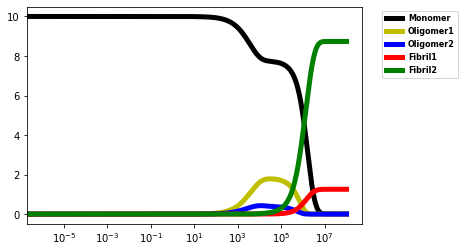

[array([0.00000000e+00, 1.25653577e-20, 2.51307154e-20, ...,
       1.25584334e+00, 1.25584334e+00, 1.25584334e+00])]
[array([0.00000000e+00, 2.44966506e-19, 4.89933011e-19, ...,
       8.73415668e+00, 8.73415668e+00, 8.73415668e+00])]
4.56
[0, 0, 0, 0, 4, 6, 0.01, 0.01, 0.0001, 5e-08, 0.0001, 5e-08, 0, 6, 4.56]


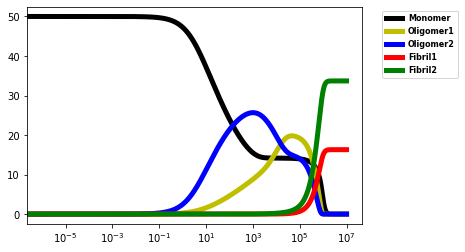

[array([0.00000000e+00, 1.25653577e-20, 2.51307154e-20, ...,
       1.25584334e+00, 1.25584334e+00, 1.25584334e+00]), array([0.00000000e+00, 6.65495295e-19, 1.33099059e-18, ...,
       1.63004215e+01, 1.63004215e+01, 1.63004215e+01])]
[array([0.00000000e+00, 2.44966506e-19, 4.89933011e-19, ...,
       8.73415668e+00, 8.73415668e+00, 8.73415668e+00]), array([0.00000000e+00, 2.45774568e-17, 4.91549136e-17, ...,
       3.36895788e+01, 3.36895788e+01, 3.36895788e+01])]
6.26
[0, 0, 0, 0, 4, 6, 0.01, 0.01, 0.0001, 5e-08, 0.0001, 5e-08, 0, 6, 6.26]


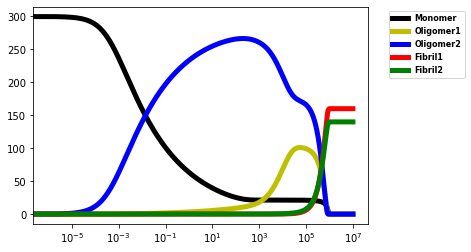

[array([0.00000000e+00, 1.25653577e-20, 2.51307154e-20, ...,
       1.25584334e+00, 1.25584334e+00, 1.25584334e+00]), array([0.00000000e+00, 6.65495295e-19, 1.33099059e-18, ...,
       1.63004215e+01, 1.63004215e+01, 1.63004215e+01]), array([0.00000000e+00, 9.40306606e-16, 3.75776258e-15, ...,
       1.60027218e+02, 1.60027218e+02, 1.60027218e+02])]
[array([0.00000000e+00, 2.44966506e-19, 4.89933011e-19, ...,
       8.73415668e+00, 8.73415668e+00, 8.73415668e+00]), array([0.00000000e+00, 2.45774568e-17, 4.91549136e-17, ...,
       3.36895788e+01, 3.36895788e+01, 3.36895788e+01]), array([0.00000000e+00, 2.28312877e-13, 9.12134958e-13, ...,
       1.39962785e+02, 1.39962785e+02, 1.39962785e+02])]


In [6]:
###### We introduce Multiple pathway-Filibrilization model --------Normal (unnormalized) and Unmodified 

## Figure Supplementary 1

import matplotlib.pyplot as plt
import numpy as np
import math
from matplotlib.ticker import FormatStrFormatter
from scipy.integrate import solve_ivp
from scipy.integrate import odeint
import matplotlib.cm as cm
plt.close('all')


### Create lists for half-time, half-fibril mass and initial peptide concentration to plot half_time vs Conc plot
t50_alla=[]
fibril_alla=[]
Y0_alla=[]


for k in [0,1,2]:        ## Tune the parameter of interest
    #p0 = [0Kd-p, 1kd-, 2Phi_BN, 3Nd, 4Nf1, 5Nf2, 6Phi_CR1, 7Phi_CR2,   8Kf1-p;1st-pathway, 9Kf1-;1st-pathway, 10Kf2-p;2nd-pathway, 11Kf2-;2nd-pathway, 12Kfrag, 13G1, 14G2] 
    barrier=[[6,6,6],[3.98,5.28,6.13],[1.98,4.56,6.26]]
    p0=   [0,     0,    0,       0,   4,   6,  0.01,    0.01,    10**(-4),        5*10**(-8),         10**(-4),                   5*10**(-8),           0,       6,   6 ]       # Free parameters in our model        
    yy=[0.6,0.8,1,2,4,8,10,20,31,40,50,60,70,80,90,100,200,300,400,500]                                   #### Discrete point initial peptide concentrations 
    n=len(yy)                                                                                                                                      #### Total discrete point concentration
    ##################################################
    # Define a function to solve all rate-mass equations
    def func0(t, u): 
        du = [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0]         # Introduce all states in our model
        #### Aproximate nf1+10 and truncate the high order dependency
        if t>0:
            if u[0]> p[6]:
                nf1plus1= u[18]  
            else:
                nf1plus1= u[18]*(u[0]/p[6])
        else:
            nf1plus1= 0     
        #### Aproximate nf2+10 and truncate the high order dependency   
        if t>0:
            if u[0]>p[7]:
                nf2plus1= u[27]
            else:
                nf2plus1= u[27]*(u[0]/p[7])
        else:
            nf2plus1= 0
         
        ### Define different terms 
        EEE1=  Kfn1*u[0]**p[4] - p[8]*u[4];                      # 1st-pathway oligomer nucleation  
        EEE2=  Kfn2*u[0]**p[5] - p[10]*u[7];                     # 2nd-pathway oligomer nucleation
        EE1=  p[4]*EEE1;                                         # monomer loss due to 1st-pathway oligomer nucleation
        EE2=  p[5]*EEE2;                                         # monomer loss due to 2st-pathway oligomer nucleation
        NNN1= (Kf1p*u[0]*u[4] - p[9]*u[10])*np.exp(-p[13])    # 1st-pathway oligomer to fibril conversion
        NNN2= (Kf2p*u[0]*u[7] - p[11]*u[19])*np.exp(-p[14])   # 2nd-pathway oligomer to fibril conversion
        NN1= (p[4]+1)* NNN1                                      # fibril mass from 1st-pathway oligomer to fibril conversion
        NN2= (p[5]+1)* NNN2                                      # fibril mass from 2nd-pathway oligomer to fibril conversion
        GG1= (Kf1p*u[0]-p[9])*u[5] +  p[9]* u[10];            # Growth and shrinking of the 1st-pathway fibril  
        GG2= (Kf2p*u[0]-p[11])*u[8] + p[11]* u[19];           # Growth and shrinking of the 2nd-pathway fibril 
        
        
        ### Introduce Fragmentation
        #JJ1= p[12]*u[6]*Fragmentation(u[6], u[5], p[4])         # fragmentation in 1st-pathway fibril
        #JJ2= p[12]*u[9]*Fragmentation(u[9], u[8], p[5])         # fragmentation in 2nd-pathway fibril
         
        ### Rate-mass equations
        du[0] = - EE1  - GG1 - NNN1 - EE2  - GG2 - NNN2                  
        du[1] = 0      
        du[2] = 0
        du[3] = 0
        du[4] = EEE1 - NNN1
        du[5] = NNN1 #+ JJ1
        du[6] = NN1 + GG1 
        du[7] = EEE2 - NNN2
        du[8] = NNN2 #+ JJ2
        du[9] = NN2 + GG2
        du[10]= (Kf1p*u[0]*u[4]*np.exp(-p[13]) -(Kf1p*u[0] + p[9]*np.exp(-p[13]))*u[10] + p[9]*u[11])
        du[11]= (Kf1p*u[0]*u[10] -(Kf1p*u[0] + p[9])*u[11] + p[9]*u[12])
        du[12]= (Kf1p*u[0]*u[11] -(Kf1p*u[0] + p[9])*u[12] + p[9]*u[13])
        du[13]= (Kf1p*u[0]*u[12] -(Kf1p*u[0] + p[9])*u[13] + p[9]*u[14])
        du[14]= (Kf1p*u[0]*u[13] -(Kf1p*u[0] + p[9])*u[14] + p[9]*u[15])
        du[15]= (Kf1p*u[0]*u[14] -(Kf1p*u[0] + p[9])*u[15] + p[9]*u[16])
        du[16]= (Kf1p*u[0]*u[15] -(Kf1p*u[0] + p[9])*u[16] + p[9]*u[17])
        du[17]= (Kf1p*u[0]*u[16] -(Kf1p*u[0] + p[9])*u[17] + p[9]*u[18])
        du[18]= (Kf1p*u[0]*u[17] -(Kf1p*u[0] + p[9])*u[18] + p[9]*nf1plus1)
        du[19]= (Kf2p*u[0]*u[7]*np.exp(-p[14]) -(Kf2p*u[0] + p[11]*np.exp(-p[14]))*u[19] + p[11]*u[20])
        du[20]= (Kf2p*u[0]*u[19] -(Kf2p*u[0] + p[11])*u[20] + p[11]*u[21])
        du[21]= (Kf2p*u[0]*u[20] -(Kf2p*u[0] + p[11])*u[21] + p[11]*u[22])
        du[22]= (Kf2p*u[0]*u[21] -(Kf2p*u[0] + p[11])*u[22] + p[11]*u[23])
        du[23]= (Kf2p*u[0]*u[22] -(Kf2p*u[0] + p[11])*u[23] + p[11]*u[24])
        du[24]= (Kf2p*u[0]*u[23] -(Kf2p*u[0] + p[11])*u[24] + p[11]*u[25])
        du[25]= (Kf2p*u[0]*u[24] -(Kf2p*u[0] + p[11])*u[25] + p[11]*u[26])
        du[26]= (Kf2p*u[0]*u[25] -(Kf2p*u[0] + p[11])*u[26] + p[11]*u[27])
        du[27]= (Kf2p*u[0]*u[26] -(Kf2p*u[0] + p[11])*u[27] + p[11]*nf2plus1)
        
        #if t>1000:
            #print(EEE1,EEE2,NNN1,NNN2,GG1,GG2,u[5],u[8])
        #if du[6]< 0 and u[0]< p[6]:
            #sigma= u[0]/p[6]
            #kdeno= sigma + p[4]+1 - (p[4]+1)*sigma
            #knum= 1 + kdeno
            #Kdf= du[6]/u[6]
            #du[10]=Kdf*u[10] - (knum/kdeno)*u[10]*du[0]/u[0]*sigma/(1-sigma)
            #du[5]= Kdf*u[5] - (1/kdeno)*u[5]*du[0]/u[0]*sigma/(1-sigma)
            
        #if u[0]< p[6]:
            #print(u[10],u[0],u[0]/p[6],u[0]/p[7],u[5],u[8],u[10]/(1-u[0]/p[6]),u[19]/(1-u[0]/p[7]),u[6],u[9],u[10]*((p[4]+1)- p[4]*(u[0]/ p[6]))/(1-u[0]/p[6])**2,u[19]*((p[5]+1)- p[5]*(u[0]/ p[7]))/(1-u[0]/p[7])**2)
            #print(du[0]/u[0],du[4]/u[4],du[5]/u[5],du[6]/u[6],du[7]/u[7],du[8]/u[8],du[9]/u[9])
        #if du[6] < 0:
            #du[5]= du[6]/u[6]*u[5]
            #du[0]=0;du[1]=0;du[2]=0;du[3]=0;du[4]=0;du[5]=0;du[6]=0;du[7]=0;du[8]=0;du[9]=0;
        return du
    
    
    ##################################################
    # Define how long we calculate (end-time) the time evolution of states for all concentrations
    x17=1*10**12; x16=1*10**8; x15=1*10**8; x14=1*10**7; x13=1*10**7;
    tend=[x17,x17,x17,x17,x16,x16,x16,x15,x15,x15,x14,x14,x14,x14,x14,x14,x14,x14,x13,x13,x13,x13,x13,x13,x13,x13,x13,x13,x13]
    
    ##################################################
    # Define the fragmentation function 
    def Fragmentation(x,y,z):
        if y==0:
            out=1
        elif x/y < z:
            out=0
        else:
            out=1
        return out
    ###################################################
    # Introduce lists to keep fibril-mass evolution and corresponding time
    fibril1a=[]
    time1a=[]
    oligomer1a=[]
    oligomer2a=[]
    totalfibril1a=[]
    totalfibril2a=[]
    #########################################################################
    for i in [6, 10, 17]:#range(n):
        y0 = [yy[i],0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0]## Introduce the initial condition
        p  = p0                             ## parameters in our model 
        if i==6:
            G2=barrier[k][0]
        elif i==10:
            G2=barrier[k][1]
        else:
            G2=barrier[k][2]
        p[14]=G2
        print(G2)
        print(p)
        Kf1p = float(f"{p[9]/p[6]:.5e}")                         ## Monomer-addition rate in 1st-pathway 
        Kf2p = float(f"{p[11]/p[7]:.5e}")                        ## Monomer-addition rate in 2nd-pathway 
        Kfn1 = float(f"{(Kf1p*(Kf1p/p[8])**(p[4]-2)):.5e}")      ## Oligomer nucleation rate in 1st-pathway 
        Kfn2 = float(f"{(Kf2p*(Kf2p/p[10])**(p[5]-2)):.5e}")     ## Oligomer nucleation rate in 2nd-pathway
        
        #tspan  = (0,tend[i])                                     ## time span between initial and final time 
        #t_eval = np.linspace(0, tend[i],10000000)                 ## time interval to record the measured calculations
        #atol = 10**(-10)                                         ## absolute tolerence
        #rtol = 10**(-10)                                         ## relative tolerence
        #sol  = solve_ivp(func0,tspan,y0, t_eval=t_eval, method ='BDF',atol=atol, rtol=rtol)
        
        tspan1 = (0,1)
        t_eval1 = np.linspace(tspan1[0], tspan1[1], 1000000)
        sol1 = solve_ivp(func0, tspan1, y0, t_eval=t_eval1, method='BDF', atol=1e-10, rtol=1e-10)
            
        tspan2 = (1, 100)
        t_eval2 = np.logspace(np.log10(tspan2[0]), np.log10(tspan2[1]), 1000000)
        sol2 = solve_ivp(func0, tspan2, sol1.y[:, -1], t_eval=t_eval2, method='BDF', atol=1e-10, rtol=1e-10)
        
        tspan3 = (100, 10000)
        t_eval3 = np.logspace(np.log10(tspan3[0]), np.log10(tspan3[1]), 1000000)
        sol3 = solve_ivp(func0, tspan3, sol2.y[:, -1], t_eval=t_eval3, method='BDF', atol=1e-10, rtol=1e-10)
        
        tspan4 = (10000, tend[i])
        t_eval4 = np.logspace(np.log10(tspan4[0]), np.log10(tspan4[1]), 1000000)
        sol4 = solve_ivp(func0, tspan4, sol3.y[:, -1], t_eval=t_eval4, method='BDF', atol=1e-10, rtol=1e-10)
            
        sol_t = np.concatenate((sol1.t, sol2.t, sol3.t, sol4.t))
        sol_y = np.hstack((sol1.y, sol2.y, sol3.y, sol4.y))
           
        fibril1a.append(sol_y[6] + sol_y[9] )                      ## append the fibril mass evolution in the list
        time1a.append(sol_t)                                       ## append the time-measured in the list
        
        oligomer1a.append(p[4]*sol_y[4])
        oligomer2a.append(p[5]*sol_y[7])
        totalfibril1a.append(sol_y[6])
        totalfibril2a.append(sol_y[9])
        
        
        #print(sol.y[0])
        #print(p[4]*sol.y[7])
        #print(sol.y[9])
        #print(sol.y[6])
        
        plt.plot(sol_t,sol_y[0, :],'k',linewidth = 5)
        plt.plot(sol_t, p[4]*sol_y[4, :],'y',linewidth = 5)
        plt.plot(sol_t, p[5]*sol_y[7, :],'b',linewidth = 5)
        #plt.plot(sol_t, sol_y[5, :],'r',linewidth = 5)
        #plt.plot(sol_t, sol_y[8, :],'g',linewidth = 5)
        plt.plot(sol_t, sol_y[6, :],'r',linewidth = 5)
        plt.plot(sol_t, sol_y[9, :],'g',linewidth = 5)
        #plt.plot(sol_t, sol_y[6, :] + sol_y[9, :],'purple',linewidth = 5)
        #plt.ylabel('Mass concentration (\u03bcM)',fontsize=15)
        #plt.xlabel('Time (s)',fontsize=15)
        #plt.xticks(fontsize=10)
        #plt.yticks(fontsize=10)
        #myleg = plt.legend(['Monomer','Oligomer','Fibril'],loc='upper left',prop = {'size':8}, bbox_to_anchor=(0.05,1.15), ncol=6, frameon=False )
        #plt.gca().ticklabel_format(style='sci', axis='x', scilimits=(0,0))
       
        #if i ==0:
            #plt.text(0.85, 0.8, " CNT w/D  ", fontsize=12, ha='center', va='center', transform=plt.gca().transAxes)
            #plt.savefig('fig2a_C.eps',dpi=300)
        #if i ==9:
            #plt.text(0.85, 0.8, " CNT w/D  ", fontsize=12, ha='center', va='center', transform=plt.gca().transAxes)
            #plt.savefig('fig2b_C.eps',dpi=300)
        #if i==13:
            #plt.text(0.85, 0.8, " CNT w/D  ", fontsize=12, ha='center', va='center', transform=plt.gca().transAxes)
            #plt.savefig('fig2c_C.eps',dpi=300)
        #plt.xscale('log')
        #plt.title('Linear Scale')
        #if i==0:
            #plt.text(0.000001, 5, 'I', fontsize = 22)
        #if i==1:
            #plt.text(0.000001, 40, 'II', fontsize = 22)
        #if i==2:
            #plt.text(0.000001, 27, 'III', fontsize = 22)
        #plt.subplot(1, 2, 2)
        #plt.plot(sol.t,sol.y[0, :],'k',linewidth = 5)
        #plt.plot(sol.t,p[0]*p[1] *sol.y[1, :],'y',linewidth = 5)
        #plt.plot(sol.t,sol.y[2, :],'r',linewidth = 5)
        #plt.plot(sol.t, sol.y[3, :] ,'b',linewidth = 5)
        #plt.plot(sol.t,sol.y[4, :],'g',linewidth = 5)
        #plt.xlim(0.00001,1)
        #plt.xlabel('Time', fontweight = 'bold')
        #plt.ylabel('Mass', fontweight = 'bold')
        plt.xscale('log')
        #plt.title('Linear Scale')
        myleg = plt.legend(['Monomer','Oligomer1','Oligomer2', 'Fibril1','Fibril2','Total_Fibril' ],loc='upper left',prop = {'size':8,'weight':'bold'}, bbox_to_anchor=(1.05,1)) 
        #plt.tight_layout()
        #plt.xlim(1,tend[i])
        #plt.xlim(0,10000000)
        #plt.savefig(f'Paper3_Fig3_{k}_{i}.eps', dpi=300)
        plt.show()
        print(totalfibril1a)
        print(totalfibril2a)
    ###########################################################################################
    # Fibril Mass fraction vs time for different concentration     
    

#     import matplotlib.pyplot as plt
#     import matplotlib.cm as cm

#     Y0 = yy  # Initial peptide concentrations
#     num_curves = len(Y0)
#     colormap = cm.get_cmap('plasma')  # Choose a color gradient map
    
#     plt.figure(figsize=(8, 5))
#     fibril_lista = [[element / Y0[p] for element in sublist] for p, sublist in enumerate(fibril1a)]
#     for idx, (sublist1, sublist2) in enumerate(zip(time1a, fibril_lista)):
#         color = colormap(idx / (num_curves - 1))  # Normalize index to [0, 1]
#         plt.plot(sublist1, sublist2, color=color, label=f'C={Y0[idx]}')
    
#     plt.xscale('log')
#     plt.xlabel('Time, s', fontweight='bold')
#     plt.ylabel('Fibril mass fraction', fontweight='bold')
#     plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2, fontsize=9)
#     plt.tight_layout()
#     plt.show()
    
#     plt.figure(figsize=(8, 5))
#     oligomer_list1a = [[element / Y0[p] for element in sublist] for p, sublist in enumerate(oligomer1a)]
#     for idx, (sublist1, sublist2) in enumerate(zip(time1a, oligomer_list1a)):
#         color = colormap(idx / (num_curves - 1))  # Normalize index to [0, 1]
#         plt.plot(sublist1, sublist2, color=color, label=f'C={Y0[idx]}')
    
#     plt.xscale('log')
#     plt.xlabel('Time, s', fontweight='bold')
#     plt.ylabel('Oligomer_1 mass fraction', fontweight='bold')
#     plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2, fontsize=9)
#     plt.tight_layout()
#     plt.show()
    
#     plt.figure(figsize=(8, 5))
#     oligomer_list2a = [[element / Y0[p] for element in sublist] for p, sublist in enumerate(oligomer2a)]
#     for idx, (sublist1, sublist2) in enumerate(zip(time1a, oligomer_list2a)):
#         color = colormap(idx / (num_curves - 1))  # Normalize index to [0, 1]
#         plt.plot(sublist1, sublist2, color=color, label=f'C={Y0[idx]}')
    
#     plt.xscale('log')
#     plt.xlabel('Time, s', fontweight='bold')
#     plt.ylabel('Oligomer_2 mass fraction', fontweight='bold')
#     plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2, fontsize=9)
#     plt.tight_layout()
#     plt.show()
    
#     plt.figure(figsize=(8, 5))
#     fibril_list1a = [[element / Y0[p] for element in sublist] for p, sublist in enumerate(totalfibril1a)]
#     for idx, (sublist1, sublist2) in enumerate(zip(time1a, fibril_list1a)):
#         color = colormap(idx / (num_curves - 1))  # Normalize index to [0, 1]
#         plt.plot(sublist1, sublist2, color=color, label=f'C={Y0[idx]}')
    
#     plt.xscale('log')
#     plt.xlabel('Time, s', fontweight='bold')
#     plt.ylabel('fibril_1 mass fraction', fontweight='bold')
#     plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2, fontsize=9)
#     plt.tight_layout()
#     plt.show()
    
#     plt.figure(figsize=(8, 5))
#     fibril_list2a = [[element / Y0[p] for element in sublist] for p, sublist in enumerate(totalfibril2a)]
#     for idx, (sublist1, sublist2) in enumerate(zip(time1a, fibril_list2a)):
#         color = colormap(idx / (num_curves - 1))  # Normalize index to [0, 1]
#         plt.plot(sublist1, sublist2, color=color, label=f'C={Y0[idx]}')
    
#     plt.xscale('log')
#     plt.xlabel('Time, s', fontweight='bold')
#     plt.ylabel('fibril_2 mass fraction', fontweight='bold')
#     plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2, fontsize=9)
#     plt.tight_layout()
#     plt.show()
    

#     ###########################################################################################   
#     #Find T_Half for each concentration
#     t50=[]   
#     fibril50=[]
#     Y050=[]
#     Y0= yy 
#     for i in range(n):
#         cutoff_value = (Y0[i]-p[7])/2      #specified cutoff value
#         list_I=fibril1a[i]              
#         list_II=time1a[i]
#         # Iterate through elements in List I
#         for value_I, value_II in zip(list_I, list_II):
#             if value_I >= cutoff_value:
#                 selected_value_I = value_I
#                 selected_value_II = value_II
#                 fibril50.append(selected_value_I)
#                 t50.append(selected_value_II)
#                 Y050.append(Y0[i])
#                 break                      # Break out of the loop once the condition is met
#     t50_alla.append(t50)
#     fibril_alla.append(fibril50)
#     Y0_alla.append(Y050)
#    ############################################################################################# 
 
# ### Plot the T_half vs Concentration for the given different parameter value
# ### Plot the T_half vs Concentration for the given different parameter value
# markers = ['o', 's', '^','D','*']  # circle, square, triangle

# for i, (sublist1, sublist2) in enumerate(zip(Y0_alla, t50_alla)):
#     plt.loglog(sublist1, sublist2, marker=markers[i], linestyle='-')  # Different marker for each curve

# plt.ylabel('T_Half, sec', fontweight='bold')
# plt.xlabel('Concentration, uM', fontweight='bold')
# # plt.title('For Different off-pathway \n monomer-oligomer dissociation rate')
# plt.legend(['kf2-p=7*10^-4', 'kf2-p=7*10^-5', 'kf2-p=7*10^-6','kf2-p=7*10^-7','kf2-p=7*10^-8'], bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.tight_layout()
# plt.show()  

/Users/tanghy/opt/anaconda3/lib/python3.8/site-packages/scipy/integrate/_ivp/common.py:46: UserWarning: `rtol` is too low, setting to 2.220446049250313e-14
  warn("`rtol` is too low, setting to {}".format(100 * EPS))
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


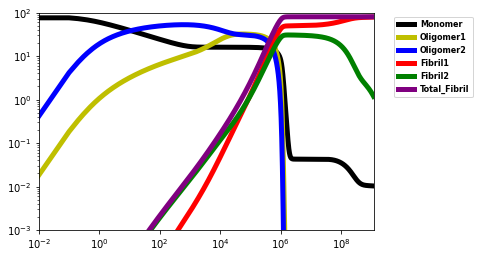

In [9]:

### Figure 3A,B bottom line

### for first unstable/ second stable fibril

###### We introduce Multiple pathway-Filibrilization model normalized by phi_CR1
import matplotlib.pyplot as plt
import numpy as np
import math
import matplotlib.cm as cm
from matplotlib.ticker import FormatStrFormatter
from scipy.integrate import solve_ivp
from scipy.integrate import odeint
plt.close('all')

### Create lists for half-time, half-fibril mass and initial peptide concentration to plot half_time vs Conc plot
t50_alla=[]
fibril_alla=[]
Y0_alla=[]
switch=0
global switch

for G in [1*10**(-4)]:        ## Tune the parameter of interest
    #p0 = [0Kd-p, 1kd-, 2Phi_BN, 3Nd, 4Nf, 5Ns, 6Phi_CR1, 7Phi_CR2, 8Kf1-p;1st-pathway, 9Kf1-;1st-pathway, 10Kf2-p;2nd-pathway, 11Kf2-;2nd-pathway, 12Kfrag, 13G1, 14G2] 
    p0=   [0,     0,    0,       0,   4,   6,  0.01,    0.1,    1*10**(-4),         5*10**(-8),         G,                   5*10**(-7),           0,       6,   6 ]       # Free parameters in our model        
    yyy=[0.6,0.8,1,2,4,8,10,20,31,40,50,60,71,80,90,100,200,300,400,500]                                   #### Discrete point initial peptide concentrations 
    yy = [x / p0[6] for x in yyy]                                                                                                                    #### Discrete point initial peptide concentrations 
    n= len(yyy)                                                                                                                                      #### Total discrete point concentration
    phi_su1=p0[8]*p0[6]/p0[9]
    phi_su2=p0[10]*p0[7]/p0[11]
    
    ##################################################
    # Define a function to solve all rate-mass equations
    def func0(t, u): 
        global switch
        du = [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0]         # Introduce all states in our model
        #### Aproximate nf1+10 and truncate the high order dependency
        CC1=0;CC2=0;FF1=0;FF2=0;
        for i in range (10,27):
            CC1 += u[i]
            FF1 += (p[4]+ (i-9))*u[i]
            #print(CC1, FF1)
        for i in range (27,44):
            CC2 += u[i]
            FF2 += (p[5]+ (i-26))*u[i]
        #### Aproximate nf1+9 and truncate the high order dependency        
        if t>0:
            if u[25]<= 0:
                n1plus1= 0
            else:
                if u[0]>= 1:
                    n1plus1= u[26]*u[26]/u[25]
                else :
                    CC3= u[5] -  CC1                   #u[26]/(1-sigma)
                    FF3= u[6] -  FF1                   #u[26]* (p[4]+1 - p[4]*sigma)/(1-sigma)**2
                    if CC3 <= 0 or FF3 < 0  or FF3/CC3 <= p[4]+ 17:
                        #print(u[5],u[6],u[10],u[11],u[12])
                        n1plus1=0
                        switch=1
                    else:
                        n1plus1= CC3/((FF3/CC3-(p[4]+17)))      
                    
        else:
            n1plus1= 0     
        #### Aproximate nf2+9 and truncate the high order dependency   
        if t>0:
            if u[42]<= 0:
                n2plus1= 0
            else:
                if u[0]>= p[7]/p[6]:
                    n2plus1= u[43]*u[43]/u[42]
                else:
                    CC4= u[8] -  CC2        #u[35]/(1-sigma)
                    FF4= u[9] -  FF2        #u[35]* (p[5]+1-p[5]*sigma)/(1-sigma)**2
                    if CC4 <=0 or FF4 <= 0 or FF4/CC4 <= p[5]+17:
                        n2plus1=0
                    else:
                        n2plus1= CC4/((FF4/CC4 -(p[5]+17)))
        else:
            n2plus1= 0
        
        
         
        ### Define different terms 
        EEE1=  (p[6]/phi_su1)**(p[4]-1)*u[0]**p[4] - u[4];                      # 1st-pathway oligomer nucleation  
        EEE2=  p[10]/p[8]*((p[6]/phi_su2)**(p[5]-1)*u[0]**p[5] - u[7]);                      # 2nd-pathway oligomer nucleation
        EE1=   p[4]*EEE1;                                                        # monomer loss due to 1st-pathway oligomer nucleation
        EE2=   p[5]*EEE2;                                                        # monomer loss due to 2st-pathway oligomer nucleation
        NNN1=  (p[6]/phi_su1)*(u[0]*u[4] - u[10])*np.exp(-p[13])                 # 1st-pathway oligomer to fibril conversion
        NNN2=  p[10]/p[8]*(p[6]/phi_su2)*(u[0]*u[7] - u[27]*p[7]/p[6])*np.exp(-p[14])       # 2nd-pathway oligomer to fibril conversion
        NN1=  (p[4]+1)* NNN1                                                     # fibril mass from 1st-pathway oligomer to fibril conversion
        NN2=  (p[5]+1)* NNN2                                                     # fibril mass from 2nd-pathway oligomer to fibril conversion
        GG1= (u[0]-1)*u[5]*(p[6]/phi_su1) +  (p[6]/phi_su1)* u[10];                              # Growth and shrinking of the 1st-pathway fibril  
        GG2=  p[10]/p[8]*((u[0]-p[7]/p[6])*u[8]*(p[6]/phi_su2) + (p[7]/phi_su2)* u[27]);                             # Growth and shrinking of the 2nd-pathway fibril 
        
        ### Introduce Fragmentation
        #JJ1= p[12]*u[6]*Fragmentation(u[6], u[5], p[4])         # fragmentation in 1st-pathway fibril
        #JJ2= p[12]*u[9]*Fragmentation(u[9], u[8], p[5])         # fragmentation in 2nd-pathway fibril
        
        

        
        ### Rate-mass equations
        du[0] = - EE1  - GG1 - NNN1 - EE2  - GG2 - NNN2                  
        du[1] = 0      
        du[2] = 0
        du[3] = 0
        du[4] = EEE1 - NNN1
        du[5] = NNN1 #+ JJ1
        du[6] = NN1 + GG1 
        du[7] = EEE2 - NNN2
        du[8] = NNN2 #+ JJ2
        du[9] = NN2 + GG2
        
        
    
        du[10]= (u[0]*u[4]*np.exp(-p[13]) -(u[0] + np.exp(-p[13]))*u[10] + u[11])*p[6]/phi_su1
        du[11]= (u[0]*u[10] -(u[0] + 1)*u[11] + u[12])*p[6]/phi_su1
        du[12]= (u[0]*u[11] -(u[0] + 1)*u[12] + u[13])*p[6]/phi_su1
        du[13]= (u[0]*u[12] -(u[0] + 1)*u[13] + u[14])*p[6]/phi_su1
        du[14]= (u[0]*u[13] -(u[0] + 1)*u[14] + u[15])*p[6]/phi_su1
        du[15]= (u[0]*u[14] -(u[0] + 1)*u[15] + u[16])*p[6]/phi_su1
        du[16]= (u[0]*u[15] -(u[0] + 1)*u[16] + u[17])*p[6]/phi_su1
        du[17]= (u[0]*u[16] -(u[0] + 1)*u[17] + u[18])*p[6]/phi_su1
        du[18]= (u[0]*u[17] -(u[0] + 1)*u[18] + u[19])*p[6]/phi_su1
        du[19]= (u[0]*u[18] -(u[0] + 1)*u[19] + u[20])*p[6]/phi_su1
        du[20]= (u[0]*u[19] -(u[0] + 1)*u[20] + u[21])*p[6]/phi_su1
        du[21]= (u[0]*u[20] -(u[0] + 1)*u[21] + u[22])*p[6]/phi_su1
        du[22]= (u[0]*u[21] -(u[0] + 1)*u[22] + u[23])*p[6]/phi_su1
        du[23]= (u[0]*u[22] -(u[0] + 1)*u[23] + u[24])*p[6]/phi_su1
        du[24]= (u[0]*u[23] -(u[0] + 1)*u[24] + u[25])*p[6]/phi_su1
        du[25]= (u[0]*u[24] -(u[0] + 1)*u[25] + u[26])*p[6]/phi_su1
        du[26]= (u[0]*u[25] -(u[0] + 1)*u[26] + n1plus1)*p[6]/phi_su1
        
        
        du[27]= p[10]/p[8]*(u[0]*u[7]*np.exp(-p[14]) -(u[0] + p[7]/p[6]*np.exp(-p[14]))*u[27] + p[7]/p[6]*u[28])*p[6]/phi_su2
        du[28]= p[10]/p[8]*(u[0]*u[27] -(u[0] + p[7]/p[6])*u[28] + p[7]/p[6]*u[29])*p[6]/phi_su2
        du[29]= p[10]/p[8]*(u[0]*u[28] -(u[0] + p[7]/p[6])*u[29] + p[7]/p[6]*u[30])*p[6]/phi_su2
        du[30]= p[10]/p[8]*(u[0]*u[29] -(u[0] + p[7]/p[6])*u[30] + p[7]/p[6]*u[31])*p[6]/phi_su2
        du[31]= p[10]/p[8]*(u[0]*u[30] -(u[0] + p[7]/p[6])*u[31] + p[7]/p[6]*u[32])*p[6]/phi_su2
        du[32]= p[10]/p[8]*(u[0]*u[31] -(u[0] + p[7]/p[6])*u[32] + p[7]/p[6]*u[33])*p[6]/phi_su2
        du[33]= p[10]/p[8]*(u[0]*u[32] -(u[0] + p[7]/p[6])*u[33] + p[7]/p[6]*u[34])*p[6]/phi_su2
        du[34]= p[10]/p[8]*(u[0]*u[33] -(u[0] + p[7]/p[6])*u[34] + p[7]/p[6]*u[35])*p[6]/phi_su2
        du[35]= p[10]/p[8]*(u[0]*u[34] -(u[0] + p[7]/p[6])*u[35] + p[7]/p[6]*u[36])*p[6]/phi_su2
        du[36]= p[10]/p[8]*(u[0]*u[35] -(u[0] + p[7]/p[6])*u[36] + p[7]/p[6]*u[37])*p[6]/phi_su2
        du[37]= p[10]/p[8]*(u[0]*u[36] -(u[0] + p[7]/p[6])*u[37] + p[7]/p[6]*u[38])*p[6]/phi_su2
        du[38]= p[10]/p[8]*(u[0]*u[37] -(u[0] + p[7]/p[6])*u[38] + p[7]/p[6]*u[39])*p[6]/phi_su2
        du[39]= p[10]/p[8]*(u[0]*u[38] -(u[0] + p[7]/p[6])*u[39] + p[7]/p[6]*u[40])*p[6]/phi_su2
        du[40]= p[10]/p[8]*(u[0]*u[39] -(u[0] + p[7]/p[6])*u[40] + p[7]/p[6]*u[41])*p[6]/phi_su2
        du[41]= p[10]/p[8]*(u[0]*u[40] -(u[0] + p[7]/p[6])*u[41] + p[7]/p[6]*u[42])*p[6]/phi_su2
        du[42]= p[10]/p[8]*(u[0]*u[41] -(u[0] + p[7]/p[6])*u[42] + p[7]/p[6]*u[43])*p[6]/phi_su2
        du[43]= p[10]/p[8]*(u[0]*u[42] -(u[0] + p[7]/p[6])*u[43] + p[7]/p[6]*n2plus1)*p[6]/phi_su2
            
        if switch == 1 and u[0]< p[7]:
            #du[10]= (u[0]*u[4]*np.exp(-p[13]) -(u[0] + np.exp(-p[13]))*u[10] + u[11])*p[6]/phi_su1
            #du[27]= (u[0]*u[7]*np.exp(-p[14]) -(u[0] + p[7]/p[6]*np.exp(-p[14]))*u[27] + p[7]/p[6]*u[28])*p[6]/phi_su2
            CC5= u[5] -  u[10]                 #u[26]/(1-sigma)
            FF5= u[6] -  (p[4]+1)*u[10]   
            #CC6= u[8] -  u[27]                 #u[26]/(1-sigma)
            #FF6= u[9] -  (p[5]+1)*u[27]  
            u[11]= CC5/(FF5/CC5-p[4]-1)
            du[10]= (u[0]*u[4]*np.exp(-p[13]) -(u[0] + np.exp(-p[13]))*u[10] + u[11])*p[6]/phi_su1
            #u[28]= CC6/(FF6/CC6-p[5]-1)
            for i in range(11,27):
                du[i]=0 
            for i in range(11,26):
                u[i+1]=0
            #for i in range(28,44):
                #du[i]=0 
            #for i in range(28,43):
                #u[i+1]=0
        
        #if u[0]< 0.5:
            #for j in range(10,19):
                #if u[j]<0:
                    #u[j]=0; 
                    #du[j]=0
                        
        #if t>1000:
            #print(EEE1,EEE2,NNN1,NNN2,GG1,GG2,u[5],u[8])
        #if du[6]< 0 and u[0]< 1 and u[0]> p[7]/p[6]:
            #sigma= u[0]
            #kdeno= sigma + p[4]+1 - (p[4]+1)*sigma
            #knum= 1 + kdeno
            #Kdf= du[6]/u[6]
            #du[10]=Kdf*u[10] #- (knum/kdeno)*u[10]*du[0]/u[0]*sigma/(1-sigma)
            #du[5]= Kdf*u[5] #- (1/kdeno)*u[5]*du[0]/u[0]*sigma/(1-sigma)
            
        #if u[0]< p[6]:
            #print(u[10],u[0],u[0]/p[6],u[0]/p[7],u[5],u[8],u[10]/(1-u[0]/p[6]),u[19]/(1-u[0]/p[7]),u[6],u[9],u[10]*((p[4]+1)- p[4]*(u[0]/ p[6]))/(1-u[0]/p[6])**2,u[19]*((p[5]+1)- p[5]*(u[0]/ p[7]))/(1-u[0]/p[7])**2)
            #print(du[0]/u[0],du[4]/u[4],du[5]/u[5],du[6]/u[6],du[7]/u[7],du[8]/u[8],du[9]/u[9])
        #if du[6] < 0 and u[0]< 1:
        #if u[0]< 1 and t>1000000000:
            #print(t,u[0],u[4],u[10],u[11],u[12],u[13],u[14],u[15],u[16],u[17],u[18])
            #print(t,p[6]*u[0], p[6]*u[4], p[6]*u[7], n1plus1, n2plus1, p[6]*u[5],p[6]*u[8],p[6]*FF1, p[6]*FF2, p[6]*u[6],p[6]*u[9])#,p[6]*u[10]/(1-u[0]),p[6]*u[19]/(1-u[0]),p[6]*u[10]*((p[4]+1)- p[4]*p[6]*u[0])/(1-u[0])**2, p[6]*u[19]*((p[5]+1)- p[5]*p[6]*u[0])/(1-u[0])**2)
            #print(t, p[6]*u[0],p[6]*n1plus1, p[6]*u[4],p[6]*u[5],p[6]*u[6],p[6]*u[9],p[6]*u[10],p[6]*u[11],p[6]*u[12], p[6]*CC1, p[6]*FF1, switch)
        return du
    
    
    ##################################################
    # Define how long we calculate (end-time) the time evolution of states for all concentrations
    x17=1*10**12; x16=1*10**5; x15=1*10**5; x14=1*10**5; x13=1*10**5;
    tend0 = [x17,x17,x17,x16,x16,x16,x15,x15,x15,x14,x14,x14,x14,x14,x14,x14,x14,x13,x13,x13]
    tend = [y*p0[8] for y in tend0]  
    
    ##################################################
    # Define the fragmentation function 
    def Fragmentation(x,y,z):
        if y==0:
            out=1
        elif x/y < z:
            out=0
        else:
            out=1
        return out
    ###################################################
    # Introduce lists to keep fibril-mass evolution and corresponding time
    fibril1a=[]
    time1a=[]
    oligomer1a=[]
    oligomer2a=[]
    totalfibril1a=[]
    totalfibril2a=[]
    
    #########################################################################
    for i in range(13,14):
        switch=0
        y0 = [yy[i],0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0]                           ## Introduce the initial condition
        p  = p0                                                  ## parameters in our model
        #Kf1p = float(f"{p[9]/p[6]:.5e}")                         ## Monomer-addition rate in 1st-pathway 
        #Kf2p = float(f"{p[11]/p[7]:.5e}")                        ## Monomer-addition rate in 2nd-pathway 
        #Kfn1 = float(f"{(Kf1p*(Kf1p/p[8])**(p[4]-2)):.5e}")      ## Oligomer nucleation rate in 1st-pathway 
        #Kfn2 = float(f"{(Kf2p*(Kf2p/p[10])**(p[5]-2)):.5e}")     ## Oligomer nucleation rate in 2nd-pathway
        
#         tspan  = (0,tend[i])                                     ## time span between initial and final time 
#         t_eval = np.linspace(0, tend[i],10000000)                 ## time interval to record the measured calculations
#         atol = 10**(-12)                                         ## absolute tolerence
#         rtol = 10**(-12)                                         ## relative tolerence
#         sol  = solve_ivp(func0,tspan,y0, t_eval=t_eval, method ='BDF',atol=atol, rtol=rtol)
        ###Case I
        
        
#         tspan1 = (0, 1)
#         t_eval1 = np.linspace(tspan1[0], tspan1[1], 1000000)
#         sol1 = solve_ivp(func0, tspan1, y0, t_eval=t_eval1, method='BDF',  atol=1e-12, rtol=1e-12)

#         tspan2 = (tspan1[1], 1000)
#         t_eval2 = np.logspace(np.log10(tspan2[0]), np.log10(tspan2[1]), 1000000)
#         #t_eval2 = np.linspace(tspan2[0], tspan2[1], 1000000)
#         sol2 = solve_ivp(func0, tspan2, sol1.y[:, -1], t_eval=t_eval2, method='BDF',  atol=1e-12, rtol=1e-12)

#         tspan3 = (tspan2[1], 1000000)
#         t_eval3 = np.logspace(np.log10(tspan3[0]), np.log10(tspan3[1]), 1000000)
#         #t_eval3 = np.linspace(tspan3[0], tspan3[1], 1000000)
#         sol3 = solve_ivp(func0, tspan3,sol2.y[:, -1], t_eval=t_eval3, method='BDF', atol=1e-12, rtol=1e-12)
        
#         tspan4 = (tspan3[1], tend[i])
#         t_eval4 = np.logspace(np.log10(tspan4[0]), np.log10(tspan4[1]), 1000000)
#         #t_eval3 = np.linspace(tspan3[0], tspan3[1], 1000000)
#         sol4 = solve_ivp(func0, tspan4,sol3.y[:, -1], t_eval=t_eval4, method='BDF', atol=1e-12, rtol=1e-12)
            
#         sol_t = np.concatenate((sol1.t, sol2.t, sol3.t, sol4.t))
#         sol_y = np.hstack((sol1.y, sol2.y, sol3.y, sol4.y))
        tspan1 = (0, 1)
        t_eval1 = np.linspace(tspan1[0], tspan1[1], 100000)
        sol1 = solve_ivp(func0, tspan1, y0, t_eval=t_eval1, method='BDF',  atol=1e-12, rtol=1e-12)

        tspan2 = (tspan1[1], 100)
        t_eval2 = np.logspace(np.log10(tspan2[0]), np.log10(tspan2[1]), 100000)
        #t_eval2 = np.linspace(tspan2[0], tspan2[1], 1000000)
        sol2 = solve_ivp(func0, tspan2, sol1.y[:, -1], t_eval=t_eval2, method='BDF',  atol=1e-12, rtol=1e-12)

        tspan3 = (tspan2[1], 10000)
        t_eval3 = np.logspace(np.log10(tspan3[0]), np.log10(tspan3[1]), 100000)
        #t_eval3 = np.linspace(tspan3[0], tspan3[1], 1000000)
        sol3 = solve_ivp(func0, tspan3,sol2.y[:, -1], t_eval=t_eval3, method='BDF', atol=1e-12, rtol=1e-12)
        
        tspan4 = (tspan3[1], 1000000)
        t_eval4 = np.logspace(np.log10(tspan4[0]), np.log10(tspan4[1]), 100000)
        #t_eval3 = np.linspace(tspan3[0], tspan3[1], 1000000)
        sol4 = solve_ivp(func0, tspan4,sol3.y[:, -1], t_eval=t_eval4, method='BDF', atol=1e-14, rtol=1e-14)
        
        tspan5 = (tspan4[1], tend[i])
        t_eval5 = np.logspace(np.log10(tspan5[0]), np.log10(tspan5[1]), 100000)
        #t_eval3 = np.linspace(tspan3[0], tspan3[1], 1000000)
        sol5 = solve_ivp(func0, tspan5,sol4.y[:, -1], t_eval=t_eval5, method='BDF', atol=1e-20, rtol=1e-20)
            
        sol_t = np.concatenate((sol1.t, sol2.t, sol3.t, sol4.t, sol5.t))
        sol_y = np.hstack((sol1.y, sol2.y, sol3.y, sol4.y, sol5.y))
        
        
        fibril1a.append(p[6]*sol_y[6] + p[6]*sol_y[9])                ## append the fibril mass evolution in the list
        time1a.append(sol_t/p[8])                                     ## append the time-measured in the list
        oligomer1a.append(p[4]*p[6]*sol_y[4])
        oligomer2a.append(p[5]*p[6]*sol_y[7])
        totalfibril1a.append(p[6]*sol_y[6])
        totalfibril2a.append(p[6]*sol_y[9])
        #print(sol_t/p[8])
        #print(sol.y[0])
        #print(p[4]*sol.y[7])
        #print(sol.y[9])
        
        plt.plot(sol_t/p[8], p[6]*sol_y[0, :],'k',linewidth = 5)
        plt.plot(sol_t/p[8], p[6]*p[4]*sol_y[4, :],'y',linewidth = 5)
        plt.plot(sol_t/p[8], p[6]*p[5]*sol_y[7, :],'b',linewidth = 5)
        #plt.plot(sol_t/p[8], p[6]*sol_y[5, :],'r',linewidth = 5)
        #plt.plot(sol_t/p[8], p[6]*sol_y[8, :],'g',linewidth = 5)
        plt.plot(sol_t/p[8], p[6]*sol_y[6, :],'r',linewidth = 5)
        plt.plot(sol_t/p[8], p[6]*sol_y[9, :],'g',linewidth = 5)
        plt.plot(sol_t/p[8], p[6]*sol_y[6, :] + p[6]*sol_y[9, :],'purple',linewidth = 5)
           
        
        
        #plt.ylabel('Mass concentration (\u03bcM)',fontsize=15)
        #plt.xlabel('Time (s)',fontsize=15)
        #plt.xticks(fontsize=10)
        #plt.yticks(fontsize=10)
        #myleg = plt.legend(['Monomer','Oligomer','Fibril'],loc='upper left',prop = {'size':8}, bbox_to_anchor=(0.05,1.15), ncol=6, frameon=False )
        #plt.gca().ticklabel_format(style='sci', axis='x', scilimits=(0,0))
       
        #if i ==0:
            #plt.text(0.85, 0.8, " CNT w/D  ", fontsize=12, ha='center', va='center', transform=plt.gca().transAxes)
            #plt.savefig('fig2a_C.eps',dpi=300)
        #if i ==9:
            #plt.text(0.85, 0.8, " CNT w/D  ", fontsize=12, ha='center', va='center', transform=plt.gca().transAxes)
            #plt.savefig('fig2b_C.eps',dpi=300)
        #if i==13:
            #plt.text(0.85, 0.8, " CNT w/D  ", fontsize=12, ha='center', va='center', transform=plt.gca().transAxes)
            #plt.savefig('fig2c_C.eps',dpi=300)
        #plt.xscale('log')
        #plt.title('Linear Scale')
        #if i==0:
            #plt.text(0.000001, 5, 'I', fontsize = 22)
        #if i==1:
            #plt.text(0.000001, 40, 'II', fontsize = 22)
        #if i==2:
            #plt.text(0.000001, 27, 'III', fontsize = 22)
        #plt.subplot(1, 2, 2)
        #plt.plot(sol.t,sol.y[0, :],'k',linewidth = 5)
        #plt.plot(sol.t,p[0]*p[1] *sol.y[1, :],'y',linewidth = 5)
        #plt.plot(sol.t,sol.y[2, :],'r',linewidth = 5)
        #plt.plot(sol.t, sol.y[3, :] ,'b',linewidth = 5)
        #plt.plot(sol.t,sol.y[4, :],'g',linewidth = 5)
        #plt.xlim(0.00001,1)
        #plt.xlabel('Time', fontweight = 'bold')
        #plt.ylabel('Mass', fontweight = 'bold')
        plt.yscale('log')
        plt.xscale('log')
        #plt.title('Linear Scale')
        myleg = plt.legend(['Monomer','Oligomer1','Oligomer2', 'Fibril1','Fibril2','Total_Fibril' ],loc='upper left',prop = {'size':8,'weight':'bold'}, bbox_to_anchor=(1.05,1)) 
        #plt.tight_layout()
        plt.xlim(0.01,1.2e9)
        plt.ylim(1.0e-3,100)
        plt.savefig('Paper3_Fig4C_loglog.eps', dpi=300)
        
        plt.show()
       
     ###########################################################################################
#     # Fibril Mass fraction vs time for different concentration 
#     Y0= yyy   ### Initial peptides concentration
#     print(Y0)
#     fibril_lista = [[element / Y0[p] for element in sublist] for p, sublist in enumerate(fibril1a)]
#     for sublist1, sublist2 in zip(time1a, fibril_lista):
#         plt.plot(sublist1, sublist2) #, marker='o', label='Data Points')
#     plt.xlabel('Time, s', fontweight = 'bold')
#     plt.ylabel('Fibril mass fraction', fontweight = 'bold')
#     plt.legend([f'C={c}' for c in Y0], bbox_to_anchor=(1, 0.9), loc='upper right', ncol=2, fontsize=10)
#     plt.show()
    
#     import matplotlib.pyplot as plt
#     import matplotlib.cm as cm

#     Y0 = yyy  # Initial peptide concentrations
#     num_curves = len(Y0)
#     colormap = cm.get_cmap('plasma')  # Choose a color gradient map
    
#     plt.figure(figsize=(8, 5))
#     fibril_lista = [[element / Y0[p] for element in sublist] for p, sublist in enumerate(fibril1a)]
#     for idx, (sublist1, sublist2) in enumerate(zip(time1a, fibril_lista)):
#         color = colormap(idx / (num_curves - 1))  # Normalize index to [0, 1]
#         plt.plot(sublist1, sublist2, color=color, label=f'C={Y0[idx]}')
    
#     plt.xscale('log')
#     plt.xlabel('Time, s', fontweight='bold')
#     plt.ylabel('Fibril mass fraction', fontweight='bold')
#     plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2, fontsize=9)
#     plt.tight_layout()
#     plt.show()
    
#     plt.figure(figsize=(8, 5))
#     oligomer_list1a = [[element / Y0[p] for element in sublist] for p, sublist in enumerate(oligomer1a)]
#     for idx, (sublist1, sublist2) in enumerate(zip(time1a, oligomer_list1a)):
#         color = colormap(idx / (num_curves - 1))  # Normalize index to [0, 1]
#         plt.plot(sublist1, sublist2, color=color, label=f'C={Y0[idx]}')
    
#     plt.xscale('log')
#     plt.xlabel('Time, s', fontweight='bold')
#     plt.ylabel('Oligomer_1 mass fraction', fontweight='bold')
#     plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2, fontsize=9)
#     plt.tight_layout()
#     plt.show()
    
#     plt.figure(figsize=(8, 5))
#     oligomer_list2a = [[element / Y0[p] for element in sublist] for p, sublist in enumerate(oligomer2a)]
#     for idx, (sublist1, sublist2) in enumerate(zip(time1a, oligomer_list2a)):
#         color = colormap(idx / (num_curves - 1))  # Normalize index to [0, 1]
#         plt.plot(sublist1, sublist2, color=color, label=f'C={Y0[idx]}')
    
#     plt.xscale('log')
#     plt.xlabel('Time, s', fontweight='bold')
#     plt.ylabel('Oligomer_2 mass fraction', fontweight='bold')
#     plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2, fontsize=9)
#     plt.tight_layout()
#     plt.show()
    
#     plt.figure(figsize=(8, 5))
#     fibril_list1a = [[element / Y0[p] for element in sublist] for p, sublist in enumerate(totalfibril1a)]
#     for idx, (sublist1, sublist2) in enumerate(zip(time1a, fibril_list1a)):
#         color = colormap(idx / (num_curves - 1))  # Normalize index to [0, 1]
#         plt.plot(sublist1, sublist2, color=color, label=f'C={Y0[idx]}')
    
#     plt.xscale('log')
#     plt.xlabel('Time, s', fontweight='bold')
#     plt.ylabel('fibril_1 mass fraction', fontweight='bold')
#     plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2, fontsize=9)
#     plt.tight_layout()
#     plt.show()
    
#     plt.figure(figsize=(8, 5))
#     fibril_list2a = [[element / Y0[p] for element in sublist] for p, sublist in enumerate(totalfibril2a)]
#     for idx, (sublist1, sublist2) in enumerate(zip(time1a, fibril_list2a)):
#         color = colormap(idx / (num_curves - 1))  # Normalize index to [0, 1]
#         plt.plot(sublist1, sublist2, color=color, label=f'C={Y0[idx]}')
    
#     plt.xscale('log')
#     plt.xlabel('Time, s', fontweight='bold')
#     plt.ylabel('fibril_2 mass fraction', fontweight='bold')
#     plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2, fontsize=9)
#     plt.tight_layout()
#     plt.show()
#     ###########################################################################################   
#     #Find T_Half for each concentration
#     t50=[]   
#     fibril50=[]
#     Y050=[]

#     Y0= yyy
#     for i in range(n):
#         cutoff_value = (Y0[i]- p[7])/2      #specified cutoff value
#         list_I=fibril1a[i]              
#         list_II=time1a[i]
#         # Iterate through elements in List I
#         for value_I, value_II in zip(list_I, list_II):
#             if value_I >= cutoff_value:
#                 selected_value_I = value_I
#                 selected_value_II = value_II
#                 fibril50.append(selected_value_I)
#                 t50.append(selected_value_II)
#                 Y050.append(Y0[i])
#                 break                      # Break out of the loop once the condition is met
#     t50_alla.append(t50)
#     fibril_alla.append(fibril50)
#     Y0_alla.append(Y050)
#    ############################################################################################# 
 
# ### Plot the T_half vs Concentration for the given different parameter value
# ### Plot the T_half vs Concentration for the given different parameter value
# markers = ['o', 's', '^','D','*']  # circle, square, triangle

# for i, (sublist1, sublist2) in enumerate(zip(Y0_alla, t50_alla)):
#     plt.loglog(sublist1, sublist2, marker=markers[i], linestyle='-')  # Different marker for each curve

# plt.ylabel('T_Half, sec', fontweight='bold')
# plt.xlabel('Concentration, uM', fontweight='bold')
# # plt.title('For Different off-pathway \n monomer-oligomer dissociation rate')
# plt.legend(['kf2-p=7*10^-4', 'kf2-p=7*10^-5', 'kf2-p=7*10^-6','kf2-p=7*10^-7','kf2-p=7*10^-8'], bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.tight_layout()
# plt.show()

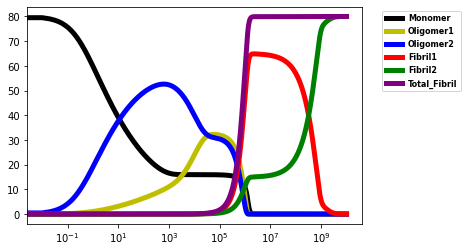

In [13]:


### Figure 3A,B top line

### for first unstable/ second stable fibril

###### We introduce Multiple pathway-Filibrilization model normalized by phi_CR1
import matplotlib.pyplot as plt
import numpy as np
import math
import matplotlib.cm as cm
from matplotlib.ticker import FormatStrFormatter
from scipy.integrate import solve_ivp
from scipy.integrate import odeint
plt.close('all')

### Create lists for half-time, half-fibril mass and initial peptide concentration to plot half_time vs Conc plot
t50_alla=[]
fibril_alla=[]
Y0_alla=[]
switch=0
global switch

for G in [1*10**(-4)]:        ## Tune the parameter of interest
    #p0 = [0Kd-p, 1kd-, 2Phi_BN, 3Nd, 4Nf, 5Ns, 6Phi_CR1, 7Phi_CR2, 8Kf1-p;1st-pathway, 9Kf1-;1st-pathway, 10Kf2-p;2nd-pathway, 11Kf2-;2nd-pathway, 12Kfrag, 13G1, 14G2] 
    p0=   [0,     0,    0,       0,   4,   6,  0.1,    0.01,    1*10**(-4),         5*10**(-7),         G,                   5*10**(-8),           0,       6,   7 ]       # Free parameters in our model        
    yyy=[0.6,0.8,1,2,4,8,10,20,31,40,50,60,71,80,90,100,200,300,400,500]                                   #### Discrete point initial peptide concentrations 
    yy = [x / p0[6] for x in yyy]                                                                                                                    #### Discrete point initial peptide concentrations 
    n= len(yyy)                                                                                                                                      #### Total discrete point concentration
    phi_su1=p0[8]*p0[6]/p0[9]
    phi_su2=p0[10]*p0[7]/p0[11]
    
    ##################################################
    # Define a function to solve all rate-mass equations
    def func0(t, u): 
        global switch
        du = [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0]         # Introduce all states in our model
        #### Aproximate nf1+10 and truncate the high order dependency
        CC1=0;CC2=0;FF1=0;FF2=0;
        for i in range (10,27):
            CC1 += u[i]
            FF1 += (p[4]+ (i-9))*u[i]
            #print(CC1, FF1)
        for i in range (27,44):
            CC2 += u[i]
            FF2 += (p[5]+ (i-26))*u[i]
        #### Aproximate nf1+9 and truncate the high order dependency        
        if t>0:
            if u[25]<= 0:
                n1plus1= 0
            else:
                if u[0]>= 1:
                    n1plus1= u[26]*u[26]/u[25]
                else :
                    CC3= u[5] -  CC1                   #u[26]/(1-sigma)
                    FF3= u[6] -  FF1                   #u[26]* (p[4]+1 - p[4]*sigma)/(1-sigma)**2
                    if CC3 <= 0 or FF3 < 0  or FF3/CC3 <= p[4]+ 17:
                        #print(u[5],u[6],u[10],u[11],u[12])
                        n1plus1=0
                        switch=1
                    else:
                        n1plus1= CC3/((FF3/CC3-(p[4]+17)))      
                    
        else:
            n1plus1= 0     
        #### Aproximate nf2+9 and truncate the high order dependency   
        if t>0:
            if u[42]<= 0:
                n2plus1= 0
            else:
                if u[0]>= p[7]/p[6]:
                    n2plus1= u[43]*u[43]/u[42]
                else:
                    CC4= u[8] -  CC2        #u[35]/(1-sigma)
                    FF4= u[9] -  FF2        #u[35]* (p[5]+1-p[5]*sigma)/(1-sigma)**2
                    if CC4 <=0 or FF4 <= 0 or FF4/CC4 <= p[5]+17:
                        n2plus1=0
                    else:
                        n2plus1= CC4/((FF4/CC4 -(p[5]+17)))
        else:
            n2plus1= 0
        
        
         
        ### Define different terms 
        EEE1=  (p[6]/phi_su1)**(p[4]-1)*u[0]**p[4] - u[4];                      # 1st-pathway oligomer nucleation  
        EEE2=  p[10]/p[8]*((p[6]/phi_su2)**(p[5]-1)*u[0]**p[5] - u[7]);                      # 2nd-pathway oligomer nucleation
        EE1=   p[4]*EEE1;                                                        # monomer loss due to 1st-pathway oligomer nucleation
        EE2=   p[5]*EEE2;                                                        # monomer loss due to 2st-pathway oligomer nucleation
        NNN1=  (p[6]/phi_su1)*(u[0]*u[4] - u[10])*np.exp(-p[13])                 # 1st-pathway oligomer to fibril conversion
        NNN2=  p[10]/p[8]*(p[6]/phi_su2)*(u[0]*u[7] - u[27]*p[7]/p[6])*np.exp(-p[14])       # 2nd-pathway oligomer to fibril conversion
        NN1=  (p[4]+1)* NNN1                                                     # fibril mass from 1st-pathway oligomer to fibril conversion
        NN2=  (p[5]+1)* NNN2                                                     # fibril mass from 2nd-pathway oligomer to fibril conversion
        GG1= (u[0]-1)*u[5]*(p[6]/phi_su1) +  (p[6]/phi_su1)* u[10];                              # Growth and shrinking of the 1st-pathway fibril  
        GG2=  p[10]/p[8]*((u[0]-p[7]/p[6])*u[8]*(p[6]/phi_su2) + (p[7]/phi_su2)* u[27]);                             # Growth and shrinking of the 2nd-pathway fibril 
        
        ### Introduce Fragmentation
        #JJ1= p[12]*u[6]*Fragmentation(u[6], u[5], p[4])         # fragmentation in 1st-pathway fibril
        #JJ2= p[12]*u[9]*Fragmentation(u[9], u[8], p[5])         # fragmentation in 2nd-pathway fibril
        
        

        
        ### Rate-mass equations
        du[0] = - EE1  - GG1 - NNN1 - EE2  - GG2 - NNN2                  
        du[1] = 0      
        du[2] = 0
        du[3] = 0
        du[4] = EEE1 - NNN1
        du[5] = NNN1 #+ JJ1
        du[6] = NN1 + GG1 
        du[7] = EEE2 - NNN2
        du[8] = NNN2 #+ JJ2
        du[9] = NN2 + GG2
        
        
    
        du[10]= (u[0]*u[4]*np.exp(-p[13]) -(u[0] + np.exp(-p[13]))*u[10] + u[11])*p[6]/phi_su1
        du[11]= (u[0]*u[10] -(u[0] + 1)*u[11] + u[12])*p[6]/phi_su1
        du[12]= (u[0]*u[11] -(u[0] + 1)*u[12] + u[13])*p[6]/phi_su1
        du[13]= (u[0]*u[12] -(u[0] + 1)*u[13] + u[14])*p[6]/phi_su1
        du[14]= (u[0]*u[13] -(u[0] + 1)*u[14] + u[15])*p[6]/phi_su1
        du[15]= (u[0]*u[14] -(u[0] + 1)*u[15] + u[16])*p[6]/phi_su1
        du[16]= (u[0]*u[15] -(u[0] + 1)*u[16] + u[17])*p[6]/phi_su1
        du[17]= (u[0]*u[16] -(u[0] + 1)*u[17] + u[18])*p[6]/phi_su1
        du[18]= (u[0]*u[17] -(u[0] + 1)*u[18] + u[19])*p[6]/phi_su1
        du[19]= (u[0]*u[18] -(u[0] + 1)*u[19] + u[20])*p[6]/phi_su1
        du[20]= (u[0]*u[19] -(u[0] + 1)*u[20] + u[21])*p[6]/phi_su1
        du[21]= (u[0]*u[20] -(u[0] + 1)*u[21] + u[22])*p[6]/phi_su1
        du[22]= (u[0]*u[21] -(u[0] + 1)*u[22] + u[23])*p[6]/phi_su1
        du[23]= (u[0]*u[22] -(u[0] + 1)*u[23] + u[24])*p[6]/phi_su1
        du[24]= (u[0]*u[23] -(u[0] + 1)*u[24] + u[25])*p[6]/phi_su1
        du[25]= (u[0]*u[24] -(u[0] + 1)*u[25] + u[26])*p[6]/phi_su1
        du[26]= (u[0]*u[25] -(u[0] + 1)*u[26] + n1plus1)*p[6]/phi_su1
        
        
        du[27]= p[10]/p[8]*(u[0]*u[7]*np.exp(-p[14]) -(u[0] + p[7]/p[6]*np.exp(-p[14]))*u[27] + p[7]/p[6]*u[28])*p[6]/phi_su2
        du[28]= p[10]/p[8]*(u[0]*u[27] -(u[0] + p[7]/p[6])*u[28] + p[7]/p[6]*u[29])*p[6]/phi_su2
        du[29]= p[10]/p[8]*(u[0]*u[28] -(u[0] + p[7]/p[6])*u[29] + p[7]/p[6]*u[30])*p[6]/phi_su2
        du[30]= p[10]/p[8]*(u[0]*u[29] -(u[0] + p[7]/p[6])*u[30] + p[7]/p[6]*u[31])*p[6]/phi_su2
        du[31]= p[10]/p[8]*(u[0]*u[30] -(u[0] + p[7]/p[6])*u[31] + p[7]/p[6]*u[32])*p[6]/phi_su2
        du[32]= p[10]/p[8]*(u[0]*u[31] -(u[0] + p[7]/p[6])*u[32] + p[7]/p[6]*u[33])*p[6]/phi_su2
        du[33]= p[10]/p[8]*(u[0]*u[32] -(u[0] + p[7]/p[6])*u[33] + p[7]/p[6]*u[34])*p[6]/phi_su2
        du[34]= p[10]/p[8]*(u[0]*u[33] -(u[0] + p[7]/p[6])*u[34] + p[7]/p[6]*u[35])*p[6]/phi_su2
        du[35]= p[10]/p[8]*(u[0]*u[34] -(u[0] + p[7]/p[6])*u[35] + p[7]/p[6]*u[36])*p[6]/phi_su2
        du[36]= p[10]/p[8]*(u[0]*u[35] -(u[0] + p[7]/p[6])*u[36] + p[7]/p[6]*u[37])*p[6]/phi_su2
        du[37]= p[10]/p[8]*(u[0]*u[36] -(u[0] + p[7]/p[6])*u[37] + p[7]/p[6]*u[38])*p[6]/phi_su2
        du[38]= p[10]/p[8]*(u[0]*u[37] -(u[0] + p[7]/p[6])*u[38] + p[7]/p[6]*u[39])*p[6]/phi_su2
        du[39]= p[10]/p[8]*(u[0]*u[38] -(u[0] + p[7]/p[6])*u[39] + p[7]/p[6]*u[40])*p[6]/phi_su2
        du[40]= p[10]/p[8]*(u[0]*u[39] -(u[0] + p[7]/p[6])*u[40] + p[7]/p[6]*u[41])*p[6]/phi_su2
        du[41]= p[10]/p[8]*(u[0]*u[40] -(u[0] + p[7]/p[6])*u[41] + p[7]/p[6]*u[42])*p[6]/phi_su2
        du[42]= p[10]/p[8]*(u[0]*u[41] -(u[0] + p[7]/p[6])*u[42] + p[7]/p[6]*u[43])*p[6]/phi_su2
        du[43]= p[10]/p[8]*(u[0]*u[42] -(u[0] + p[7]/p[6])*u[43] + p[7]/p[6]*n2plus1)*p[6]/phi_su2
            
        if switch == 1 and u[0]< p[7]:
            #du[10]= (u[0]*u[4]*np.exp(-p[13]) -(u[0] + np.exp(-p[13]))*u[10] + u[11])*p[6]/phi_su1
            #du[27]= (u[0]*u[7]*np.exp(-p[14]) -(u[0] + p[7]/p[6]*np.exp(-p[14]))*u[27] + p[7]/p[6]*u[28])*p[6]/phi_su2
            CC5= u[5] -  u[10]                 #u[26]/(1-sigma)
            FF5= u[6] -  (p[4]+1)*u[10]   
            #CC6= u[8] -  u[27]                 #u[26]/(1-sigma)
            #FF6= u[9] -  (p[5]+1)*u[27]  
            u[11]= CC5/(FF5/CC5-p[4]-1)
            du[10]= (u[0]*u[4]*np.exp(-p[13]) -(u[0] + np.exp(-p[13]))*u[10] + u[11])*p[6]/phi_su1
            #u[28]= CC6/(FF6/CC6-p[5]-1)
            for i in range(11,27):
                du[i]=0 
            for i in range(11,26):
                u[i+1]=0
            #for i in range(28,44):
                #du[i]=0 
            #for i in range(28,43):
                #u[i+1]=0
        
        #if u[0]< 0.5:
            #for j in range(10,19):
                #if u[j]<0:
                    #u[j]=0; 
                    #du[j]=0
                        
        #if t>1000:
            #print(EEE1,EEE2,NNN1,NNN2,GG1,GG2,u[5],u[8])
        #if du[6]< 0 and u[0]< 1 and u[0]> p[7]/p[6]:
            #sigma= u[0]
            #kdeno= sigma + p[4]+1 - (p[4]+1)*sigma
            #knum= 1 + kdeno
            #Kdf= du[6]/u[6]
            #du[10]=Kdf*u[10] #- (knum/kdeno)*u[10]*du[0]/u[0]*sigma/(1-sigma)
            #du[5]= Kdf*u[5] #- (1/kdeno)*u[5]*du[0]/u[0]*sigma/(1-sigma)
            
        #if u[0]< p[6]:
            #print(u[10],u[0],u[0]/p[6],u[0]/p[7],u[5],u[8],u[10]/(1-u[0]/p[6]),u[19]/(1-u[0]/p[7]),u[6],u[9],u[10]*((p[4]+1)- p[4]*(u[0]/ p[6]))/(1-u[0]/p[6])**2,u[19]*((p[5]+1)- p[5]*(u[0]/ p[7]))/(1-u[0]/p[7])**2)
            #print(du[0]/u[0],du[4]/u[4],du[5]/u[5],du[6]/u[6],du[7]/u[7],du[8]/u[8],du[9]/u[9])
        #if du[6] < 0 and u[0]< 1:
        #if u[0]< 1 and t>1000000000:
            #print(t,u[0],u[4],u[10],u[11],u[12],u[13],u[14],u[15],u[16],u[17],u[18])
            #print(t,p[6]*u[0], p[6]*u[4], p[6]*u[7], n1plus1, n2plus1, p[6]*u[5],p[6]*u[8],p[6]*FF1, p[6]*FF2, p[6]*u[6],p[6]*u[9])#,p[6]*u[10]/(1-u[0]),p[6]*u[19]/(1-u[0]),p[6]*u[10]*((p[4]+1)- p[4]*p[6]*u[0])/(1-u[0])**2, p[6]*u[19]*((p[5]+1)- p[5]*p[6]*u[0])/(1-u[0])**2)
            #print(t, p[6]*u[0],p[6]*n1plus1, p[6]*u[4],p[6]*u[5],p[6]*u[6],p[6]*u[9],p[6]*u[10],p[6]*u[11],p[6]*u[12], p[6]*CC1, p[6]*FF1, switch)
        return du
    
    
    ##################################################
    # Define how long we calculate (end-time) the time evolution of states for all concentrations
    x17=1*10**12; x16=1*10**12; x15=1*10**10; x14=1*10**10; x13=1*10**10;
    tend0 = [x17,x17,x17,x16,x16,x16,x15,x15,x15,x14,x14,x14,x14,x14,x14,x14,x14,x13,x13,x13]
    tend = [y*p0[8] for y in tend0]  
    
    ##################################################
    # Define the fragmentation function 
    def Fragmentation(x,y,z):
        if y==0:
            out=1
        elif x/y < z:
            out=0
        else:
            out=1
        return out
    ###################################################
    # Introduce lists to keep fibril-mass evolution and corresponding time
    fibril1a=[]
    time1a=[]
    oligomer1a=[]
    oligomer2a=[]
    totalfibril1a=[]
    totalfibril2a=[]
    
    #########################################################################
    for i in range(13,14):
        switch=0
        y0 = [yy[i],0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0]                           ## Introduce the initial condition
        p  = p0                                                  ## parameters in our model
        #Kf1p = float(f"{p[9]/p[6]:.5e}")                         ## Monomer-addition rate in 1st-pathway 
        #Kf2p = float(f"{p[11]/p[7]:.5e}")                        ## Monomer-addition rate in 2nd-pathway 
        #Kfn1 = float(f"{(Kf1p*(Kf1p/p[8])**(p[4]-2)):.5e}")      ## Oligomer nucleation rate in 1st-pathway 
        #Kfn2 = float(f"{(Kf2p*(Kf2p/p[10])**(p[5]-2)):.5e}")     ## Oligomer nucleation rate in 2nd-pathway
        
#         tspan  = (0,tend[i])                                     ## time span between initial and final time 
#         t_eval = np.linspace(0, tend[i],10000000)                 ## time interval to record the measured calculations
#         atol = 10**(-12)                                         ## absolute tolerence
#         rtol = 10**(-12)                                         ## relative tolerence
#         sol  = solve_ivp(func0,tspan,y0, t_eval=t_eval, method ='BDF',atol=atol, rtol=rtol)
        ###Case I
        
        
        tspan1 = (0, 1)
        t_eval1 = np.linspace(tspan1[0], tspan1[1], 1000000)
        sol1 = solve_ivp(func0, tspan1, y0, t_eval=t_eval1, method='BDF',  atol=1e-12, rtol=1e-12)
#         sol_t=sol.t
#         sol_y=sol.y

        tspan2 = (tspan1[1], 1000)
        t_eval2 = np.logspace(np.log10(tspan2[0]), np.log10(tspan2[1]), 100000)
        #t_eval2 = np.linspace(tspan2[0], tspan2[1], 1000000)
        sol2 = solve_ivp(func0, tspan2, sol1.y[:, -1], t_eval=t_eval2, method='BDF',  atol=1e-10, rtol=1e-10)

        tspan3 = (tspan2[1], tend[i])
        t_eval3 = np.logspace(np.log10(tspan3[0]), np.log10(tspan3[1]), 100000)
        #t_eval3 = np.linspace(tspan3[0], tspan3[1], 1000000)
        sol3 = solve_ivp(func0, tspan3,sol2.y[:, -1], t_eval=t_eval3, method='BDF', atol=1e-12, rtol=1e-12)
            
        sol_t = np.concatenate((sol1.t, sol2.t, sol3.t))
        sol_y = np.hstack((sol1.y, sol2.y, sol3.y))
        
        fibril1a.append(p[6]*sol_y[6] + p[6]*sol_y[9])                ## append the fibril mass evolution in the list
        time1a.append(sol_t/p[8])                                     ## append the time-measured in the list
        oligomer1a.append(p[4]*p[6]*sol_y[4])
        oligomer2a.append(p[5]*p[6]*sol_y[7])
        totalfibril1a.append(p[6]*sol_y[6])
        totalfibril2a.append(p[6]*sol_y[9])
        #print(sol_t/p[8])
        #print(sol.y[0])
        #print(p[4]*sol.y[7])
        #print(sol.y[9])
        
        plt.plot(sol_t/p[8], p[6]*sol_y[0, :],'k',linewidth = 5)
        plt.plot(sol_t/p[8], p[6]*p[4]*sol_y[4, :],'y',linewidth = 5)
        plt.plot(sol_t/p[8], p[6]*p[5]*sol_y[7, :],'b',linewidth = 5)
        #plt.plot(sol_t/p[8], p[6]*sol_y[5, :],'r',linewidth = 5)
        #plt.plot(sol_t/p[8], p[6]*sol_y[8, :],'g',linewidth = 5)
        plt.plot(sol_t/p[8], p[6]*sol_y[6, :],'r',linewidth = 5)
        plt.plot(sol_t/p[8], p[6]*sol_y[9, :],'g',linewidth = 5)
        plt.plot(sol_t/p[8], p[6]*sol_y[6, :] + p[6]*sol_y[9, :],'purple',linewidth = 5)
           
        
        
        #plt.ylabel('Mass concentration (\u03bcM)',fontsize=15)
        #plt.xlabel('Time (s)',fontsize=15)
        #plt.xticks(fontsize=10)
        #plt.yticks(fontsize=10)
        #myleg = plt.legend(['Monomer','Oligomer','Fibril'],loc='upper left',prop = {'size':8}, bbox_to_anchor=(0.05,1.15), ncol=6, frameon=False )
        #plt.gca().ticklabel_format(style='sci', axis='x', scilimits=(0,0))
       
        #if i ==0:
            #plt.text(0.85, 0.8, " CNT w/D  ", fontsize=12, ha='center', va='center', transform=plt.gca().transAxes)
            #plt.savefig('fig2a_C.eps',dpi=300)
        #if i ==9:
            #plt.text(0.85, 0.8, " CNT w/D  ", fontsize=12, ha='center', va='center', transform=plt.gca().transAxes)
            #plt.savefig('fig2b_C.eps',dpi=300)
        #if i==13:
            #plt.text(0.85, 0.8, " CNT w/D  ", fontsize=12, ha='center', va='center', transform=plt.gca().transAxes)
            #plt.savefig('fig2c_C.eps',dpi=300)
        #plt.xscale('log')
        #plt.title('Linear Scale')
        #if i==0:
            #plt.text(0.000001, 5, 'I', fontsize = 22)
        #if i==1:
            #plt.text(0.000001, 40, 'II', fontsize = 22)
        #if i==2:
            #plt.text(0.000001, 27, 'III', fontsize = 22)
        #plt.subplot(1, 2, 2)
        #plt.plot(sol.t,sol.y[0, :],'k',linewidth = 5)
        #plt.plot(sol.t,p[0]*p[1] *sol.y[1, :],'y',linewidth = 5)
        #plt.plot(sol.t,sol.y[2, :],'r',linewidth = 5)
        #plt.plot(sol.t, sol.y[3, :] ,'b',linewidth = 5)
        #plt.plot(sol.t,sol.y[4, :],'g',linewidth = 5)
        #plt.xlim(0.00001,1)
        #plt.xlabel('Time', fontweight = 'bold')
        #plt.ylabel('Mass', fontweight = 'bold')
        plt.xscale('log')
        #plt.title('Linear Scale')
        myleg = plt.legend(['Monomer','Oligomer1','Oligomer2', 'Fibril1','Fibril2','Total_Fibril' ],loc='upper left',prop = {'size':8,'weight':'bold'}, bbox_to_anchor=(1.05,1)) 
        #plt.tight_layout()
        #plt.xlim(1,tend[i])
        #plt.xlim(0,200000)
        #plt.savefig('Paper3_Fig4B.eps', dpi=300)
        
        plt.show()
 
     ###########################################################################################
#     # Fibril Mass fraction vs time for different concentration 
#     Y0= yyy   ### Initial peptides concentration
#     print(Y0)
#     fibril_lista = [[element / Y0[p] for element in sublist] for p, sublist in enumerate(fibril1a)]
#     for sublist1, sublist2 in zip(time1a, fibril_lista):
#         plt.plot(sublist1, sublist2) #, marker='o', label='Data Points')
#     plt.xlabel('Time, s', fontweight = 'bold')
#     plt.ylabel('Fibril mass fraction', fontweight = 'bold')
#     plt.legend([f'C={c}' for c in Y0], bbox_to_anchor=(1, 0.9), loc='upper right', ncol=2, fontsize=10)
#     plt.show()
    
#     import matplotlib.pyplot as plt
#     import matplotlib.cm as cm

#     Y0 = yyy  # Initial peptide concentrations
#     num_curves = len(Y0)
#     colormap = cm.get_cmap('plasma')  # Choose a color gradient map
    
#     plt.figure(figsize=(8, 5))
#     fibril_lista = [[element / Y0[p] for element in sublist] for p, sublist in enumerate(fibril1a)]
#     for idx, (sublist1, sublist2) in enumerate(zip(time1a, fibril_lista)):
#         color = colormap(idx / (num_curves - 1))  # Normalize index to [0, 1]
#         plt.plot(sublist1, sublist2, color=color, label=f'C={Y0[idx]}')
    
#     plt.xscale('log')
#     plt.xlabel('Time, s', fontweight='bold')
#     plt.ylabel('Fibril mass fraction', fontweight='bold')
#     plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2, fontsize=9)
#     plt.tight_layout()
#     plt.show()
    
#     plt.figure(figsize=(8, 5))
#     oligomer_list1a = [[element / Y0[p] for element in sublist] for p, sublist in enumerate(oligomer1a)]
#     for idx, (sublist1, sublist2) in enumerate(zip(time1a, oligomer_list1a)):
#         color = colormap(idx / (num_curves - 1))  # Normalize index to [0, 1]
#         plt.plot(sublist1, sublist2, color=color, label=f'C={Y0[idx]}')
    
#     plt.xscale('log')
#     plt.xlabel('Time, s', fontweight='bold')
#     plt.ylabel('Oligomer_1 mass fraction', fontweight='bold')
#     plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2, fontsize=9)
#     plt.tight_layout()
#     plt.show()
    
#     plt.figure(figsize=(8, 5))
#     oligomer_list2a = [[element / Y0[p] for element in sublist] for p, sublist in enumerate(oligomer2a)]
#     for idx, (sublist1, sublist2) in enumerate(zip(time1a, oligomer_list2a)):
#         color = colormap(idx / (num_curves - 1))  # Normalize index to [0, 1]
#         plt.plot(sublist1, sublist2, color=color, label=f'C={Y0[idx]}')
    
#     plt.xscale('log')
#     plt.xlabel('Time, s', fontweight='bold')
#     plt.ylabel('Oligomer_2 mass fraction', fontweight='bold')
#     plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2, fontsize=9)
#     plt.tight_layout()
#     plt.show()
    
#     plt.figure(figsize=(8, 5))
#     fibril_list1a = [[element / Y0[p] for element in sublist] for p, sublist in enumerate(totalfibril1a)]
#     for idx, (sublist1, sublist2) in enumerate(zip(time1a, fibril_list1a)):
#         color = colormap(idx / (num_curves - 1))  # Normalize index to [0, 1]
#         plt.plot(sublist1, sublist2, color=color, label=f'C={Y0[idx]}')
    
#     plt.xscale('log')
#     plt.xlabel('Time, s', fontweight='bold')
#     plt.ylabel('fibril_1 mass fraction', fontweight='bold')
#     plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2, fontsize=9)
#     plt.tight_layout()
#     plt.show()
    
#     plt.figure(figsize=(8, 5))
#     fibril_list2a = [[element / Y0[p] for element in sublist] for p, sublist in enumerate(totalfibril2a)]
#     for idx, (sublist1, sublist2) in enumerate(zip(time1a, fibril_list2a)):
#         color = colormap(idx / (num_curves - 1))  # Normalize index to [0, 1]
#         plt.plot(sublist1, sublist2, color=color, label=f'C={Y0[idx]}')
    
#     plt.xscale('log')
#     plt.xlabel('Time, s', fontweight='bold')
#     plt.ylabel('fibril_2 mass fraction', fontweight='bold')
#     plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2, fontsize=9)
#     plt.tight_layout()
#     plt.show()
#     ###########################################################################################   
#     #Find T_Half for each concentration
#     t50=[]   
#     fibril50=[]
#     Y050=[]

#     Y0= yyy
#     for i in range(n):
#         cutoff_value = (Y0[i]- p[7])/2      #specified cutoff value
#         list_I=fibril1a[i]              
#         list_II=time1a[i]
#         # Iterate through elements in List I
#         for value_I, value_II in zip(list_I, list_II):
#             if value_I >= cutoff_value:
#                 selected_value_I = value_I
#                 selected_value_II = value_II
#                 fibril50.append(selected_value_I)
#                 t50.append(selected_value_II)
#                 Y050.append(Y0[i])
#                 break                      # Break out of the loop once the condition is met
#     t50_alla.append(t50)
#     fibril_alla.append(fibril50)
#     Y0_alla.append(Y050)
#    ############################################################################################# 
 
# ### Plot the T_half vs Concentration for the given different parameter value
# ### Plot the T_half vs Concentration for the given different parameter value
# markers = ['o', 's', '^','D','*']  # circle, square, triangle

# for i, (sublist1, sublist2) in enumerate(zip(Y0_alla, t50_alla)):
#     plt.loglog(sublist1, sublist2, marker=markers[i], linestyle='-')  # Different marker for each curve

# plt.ylabel('T_Half, sec', fontweight='bold')
# plt.xlabel('Concentration, uM', fontweight='bold')
# # plt.title('For Different off-pathway \n monomer-oligomer dissociation rate')
# plt.legend(['kf2-p=7*10^-4', 'kf2-p=7*10^-5', 'kf2-p=7*10^-6','kf2-p=7*10^-7','kf2-p=7*10^-8'], bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.tight_layout()
# plt.show()

/Users/tanghy/opt/anaconda3/lib/python3.8/site-packages/scipy/integrate/_ivp/common.py:337: RuntimeWarning: overflow encountered in multiply
  h_new = (y[ind] + new_factor * y_scale[ind]) - y[ind]
/Users/tanghy/opt/anaconda3/lib/python3.8/site-packages/scipy/integrate/_ivp/common.py:306: RuntimeWarning: overflow encountered in multiply
  h = (y + factor * y_scale) - y
/Users/tanghy/opt/anaconda3/lib/python3.8/site-packages/scipy/integrate/_ivp/common.py:336: RuntimeWarning: overflow encountered in multiply
  new_factor = NUM_JAC_FACTOR_INCREASE * factor[ind]
/Users/tanghy/opt/anaconda3/lib/python3.8/site-packages/scipy/integrate/_ivp/common.py:358: RuntimeWarning: overflow encountered in multiply
  factor[max_diff < NUM_JAC_DIFF_SMALL * scale] *= NUM_JAC_FACTOR_INCREASE
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


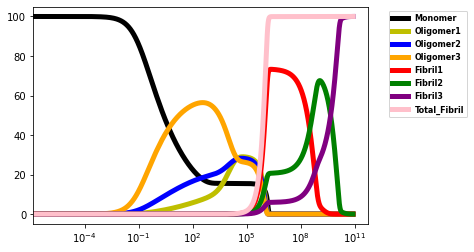

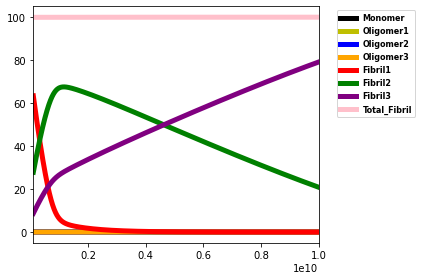

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


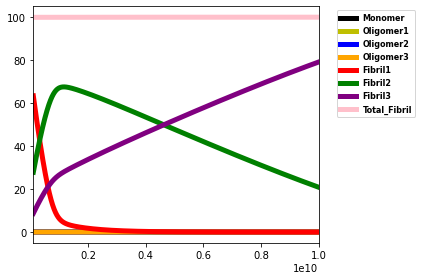

In [14]:
### Three pathway model 

### Figure 4A,B 

###### We introduce Multiple pathway-Filibrilization model normalized by phi_CR1
import matplotlib.pyplot as plt
import numpy as np
import math
import matplotlib.cm as cm
from matplotlib.ticker import FormatStrFormatter
from scipy.integrate import solve_ivp
from scipy.integrate import odeint
plt.close('all')

### Create lists for half-time, half-fibril mass and initial peptide concentration to plot half_time vs Conc plot
t50_alla=[]
fibril_alla=[]
Y0_alla=[]
switch=0
global switch

for nf3 in [6]:        ## Tune the parameter of interest
    #p0 = [0Kd-p, 1kd-, 2Phi_BN, 3Nd, 4Nf1, 5Nf2, 6Nf3, 7Phi_CR1, 8Phi_CR2, 9Phi_CR3, 10Kf1-p;1st-pathway, 11Kf1-;1st-pathway, 12Kf2-p;2nd-pathway, 13Kf2-;2nd-pathway, 14Kf3-p;3rd-pathway, 15Kf3-;3rd-pathway, 16Kfrag, 17G1, 18G2, 19G3]
    p0=   [0,     0,    0,       0,   4,      5,   nf3,    0.1,    0.03,      0.01,   10**(-4),       5*10**(-7),            10**(-4),          15*10**(-8),           10**(-4),           5*10**(-8),            0,     6,   7,   8 ]       # Free parameters in our model
    yyy=[0.6,0.8,1,2,4,8,10,20,31,40,50,60,70,80,90,100,200,300,400,500]                                   #### Discrete point initial peptide concentrations
    yy = [x / p0[7] for x in yyy]                                                                                                                    #### Discrete point initial peptide concentrations
    n= len(yyy)                                                                                                                                      #### Total discrete point concentration
    phi_su1=p0[10]*p0[7]/p0[11]
    phi_su2=p0[12]*p0[8]/p0[13]
    phi_su3=p0[14]*p0[9]/p0[15]

    ##################################################
    # Define a function to solve all rate-mass equations
    def func0(t, u):
        global switch
        du = [0]*64         # Introduce all states in our model
        #### Aproximate nf1+10 and truncate the high order dependency
        CC1=0;CC2=0;CC3=0;FF1=0;FF2=0;FF3=0
        for i in range (10,27):
            CC1 += u[i]
            FF1 += (p[4]+ (i-9))*u[i]
            #print(CC1, FF1)
        for i in range (27,44):
            CC2 += u[i]
            FF2 += (p[5]+ (i-26))*u[i]
        for i in range (47,64):
            CC3 += u[i]
            FF3 += (p[6]+ (i-46))*u[i]

        #### Aproximate nf1+9 and truncate the high order dependency
        if t>0:
            if u[25]<= 0:
                n1plus1= 0
            else:
                if u[0]>= 1:
                    n1plus1= u[26]*u[26]/u[25]
                else :
                    CC4= u[5] -  CC1                   #u[26]/(1-sigma)
                    FF4= u[6] -  FF1                   #u[26]* (p[4]+1 - p[4]*sigma)/(1-sigma)**2
                    if CC4 <= 0 or FF4 < 0  or FF4/CC4 <= p[4]+ 17:
                        #print(u[5],u[6],u[10],u[11],u[12])
                        n1plus1=0
                        switch=1
                    else:
                        n1plus1= CC4/((FF4/CC4-(p[4]+17)))

        else:
            n1plus1= 0
        #### Aproximate nf2+9 and truncate the high order dependency
        if t>0:
            if u[42]<= 0:
                n2plus1= 0
            else:
                if u[0]>= p[8]/p[7]:
                    n2plus1= u[43]*u[43]/u[42]
                else:
                    CC5= u[8] -  CC2        #u[35]/(1-sigma)
                    FF5= u[9] -  FF2        #u[35]* (p[5]+1-p[5]*sigma)/(1-sigma)**2
                    if CC5 <=0 or FF5 <= 0 or FF5/CC5 <= p[5]+17:
                        n2plus1=0
                        switch=1
                    else:
                        n2plus1= CC5/((FF5/CC5 -(p[5]+17)))
        else:
            n2plus1= 0
        ####
        if t>0:
            if u[62] <= 0:
                n3plus1= 0
            else:
                if u[0]>= p[9]/p[7]:
                    n3plus1= u[63]*u[63]/u[62]
                else:
                    CC6 = u[45] -  CC3
                    FF6 = u[46] -  FF3
                    if CC6 <=0 or FF6 <= 0 or FF6/CC6 <= p[6]+17:
                        n3plus1=0
                    else:
                        n3plus1= CC6/((FF6/CC6 -(p[6]+17)))
        else:
            n3plus1= 0



        ### Define different terms
        EEE1=  (p[7]/phi_su1)**(p[4]-1)*u[0]**p[4] - u[4];                      # 1st-pathway oligomer nucleation
        EEE2=  p[12]/p[10]*((p[7]/phi_su2)**(p[5]-1)*u[0]**p[5] - u[7]);                      # 2nd-pathway oligomer nucleation
        EEE3= p[14]/p[10]*((p[7]/phi_su3)**(p[6]-1)*u[0]**p[6] - u[44]);                      # 3rd-pathway oligomer nucleation
        EE1=  p[4]*EEE1;                                                        # monomer loss due to 1st-pathway oligomer nucleation
        EE2=  p[5]*EEE2;                                                        # monomer loss due to 2st-pathway oligomer nucleation
        EE3=  p[6]*EEE3;                                                        # monomer loss due to 3st-pathway oligomer nucleation
        NNN1= (p[7]/phi_su1)*(u[0]*u[4] - u[10])*np.exp(-p[17])                 # 1st-pathway oligomer to fibril conversion
        NNN2= p[12]/p[10]*(p[7]/phi_su2)*(u[0]*u[7] - u[27]*p[8]/p[7])*np.exp(-p[18])       # 2nd-pathway oligomer to fibril conversion
        NNN3= p[14]/p[10]*(p[7]/phi_su3)*(u[0]*u[44] - u[47]*p[9]/p[7])*np.exp(-p[19])       # 3rd-pathway oligomer to fibril conversion
        NN1= (p[4]+1)* NNN1                                                     # fibril mass from 1st-pathway oligomer to fibril conversion
        NN2= (p[5]+1)* NNN2                                                     # fibril mass from 2nd-pathway oligomer to fibril conversion
        NN3= (p[6]+1)* NNN3                                                     # fibril mass from 3st-pathway oligomer to fibril conversion
        GG1= (u[0]-1)*u[5]*(p[7]/phi_su1) +  (p[7]/phi_su1)* u[10];                              # Growth and shrinking of the 1st-pathway fibril
        GG2= p[12]/p[10]*((u[0]-p[8]/p[7])*u[8]*(p[7]/phi_su2) + (p[8]/phi_su2)* u[27]);                             # Growth and shrinking of the 2nd-pathway fibril
        GG3= p[14]/p[10]*((u[0]-p[9]/p[7])*u[45]*(p[7]/phi_su3) + (p[9]/phi_su3)* u[47])

        ### Introduce Fragmentation
        #JJ1= p[12]*u[6]*Fragmentation(u[6], u[5], p[4])         # fragmentation in 1st-pathway fibril
        #JJ2= p[12]*u[9]*Fragmentation(u[9], u[8], p[5])         # fragmentation in 2nd-pathway fibril



        ### Rate-mass equations
        du[0] = - EE1  - GG1 - NNN1 - EE2  - GG2 - NNN2 - EE3  - GG3 - NNN3
        du[1] = 0
        du[2] = 0
        du[3] = 0
        du[4] = EEE1 - NNN1
        du[5] = NNN1 #+ JJ1
        du[6] = NN1 + GG1
        du[7] = EEE2 - NNN2
        du[8] = NNN2 #+ JJ2
        du[9] = NN2 + GG2

        du[44]= EEE3 - NNN3
        du[45]= NNN3 #+ JJ1
        du[46]= NN3 + GG3

        du[10]= (u[0]*u[4]*np.exp(-p[17]) -(u[0] + np.exp(-p[17]))*u[10] + u[11])*p[7]/phi_su1
        du[11]= (u[0]*u[10] -(u[0] + 1)*u[11] + u[12])*p[7]/phi_su1
        du[12]= (u[0]*u[11] -(u[0] + 1)*u[12] + u[13])*p[7]/phi_su1
        du[13]= (u[0]*u[12] -(u[0] + 1)*u[13] + u[14])*p[7]/phi_su1
        du[14]= (u[0]*u[13] -(u[0] + 1)*u[14] + u[15])*p[7]/phi_su1
        du[15]= (u[0]*u[14] -(u[0] + 1)*u[15] + u[16])*p[7]/phi_su1
        du[16]= (u[0]*u[15] -(u[0] + 1)*u[16] + u[17])*p[7]/phi_su1
        du[17]= (u[0]*u[16] -(u[0] + 1)*u[17] + u[18])*p[7]/phi_su1
        du[18]= (u[0]*u[17] -(u[0] + 1)*u[18] + u[19])*p[7]/phi_su1
        du[19]= (u[0]*u[18] -(u[0] + 1)*u[19] + u[20])*p[7]/phi_su1
        du[20]= (u[0]*u[19] -(u[0] + 1)*u[20] + u[21])*p[7]/phi_su1
        du[21]= (u[0]*u[20] -(u[0] + 1)*u[21] + u[22])*p[7]/phi_su1
        du[22]= (u[0]*u[21] -(u[0] + 1)*u[22] + u[23])*p[7]/phi_su1
        du[23]= (u[0]*u[22] -(u[0] + 1)*u[23] + u[24])*p[7]/phi_su1
        du[24]= (u[0]*u[23] -(u[0] + 1)*u[24] + u[25])*p[7]/phi_su1
        du[25]= (u[0]*u[24] -(u[0] + 1)*u[25] + u[26])*p[7]/phi_su1
        du[26]= (u[0]*u[25] -(u[0] + 1)*u[26] + n1plus1)*p[7]/phi_su1


        du[27]= p[12]/p[10]*(u[0]*u[7]*np.exp(-p[18]) -(u[0] + p[8]/p[7]*np.exp(-p[18]))*u[27] + p[8]/p[7]*u[28])*p[7]/phi_su2
        du[28]= p[12]/p[10]*(u[0]*u[27] -(u[0] + p[8]/p[7])*u[28] + p[8]/p[7]*u[29])*p[7]/phi_su2
        du[29]= p[12]/p[10]*(u[0]*u[28] -(u[0] + p[8]/p[7])*u[29] + p[8]/p[7]*u[30])*p[7]/phi_su2
        du[30]= p[12]/p[10]*(u[0]*u[29] -(u[0] + p[8]/p[7])*u[30] + p[8]/p[7]*u[31])*p[7]/phi_su2
        du[31]= p[12]/p[10]*(u[0]*u[30] -(u[0] + p[8]/p[7])*u[31] + p[8]/p[7]*u[32])*p[7]/phi_su2
        du[32]= p[12]/p[10]*(u[0]*u[31] -(u[0] + p[8]/p[7])*u[32] + p[8]/p[7]*u[33])*p[7]/phi_su2
        du[33]= p[12]/p[10]*(u[0]*u[32] -(u[0] + p[8]/p[7])*u[33] + p[8]/p[7]*u[34])*p[7]/phi_su2
        du[34]= p[12]/p[10]*(u[0]*u[33] -(u[0] + p[8]/p[7])*u[34] + p[8]/p[7]*u[35])*p[7]/phi_su2
        du[35]= p[12]/p[10]*(u[0]*u[34] -(u[0] + p[8]/p[7])*u[35] + p[8]/p[7]*u[36])*p[7]/phi_su2
        du[36]= p[12]/p[10]*(u[0]*u[35] -(u[0] + p[8]/p[7])*u[36] + p[8]/p[7]*u[37])*p[7]/phi_su2
        du[37]= p[12]/p[10]*(u[0]*u[36] -(u[0] + p[8]/p[7])*u[37] + p[8]/p[7]*u[38])*p[7]/phi_su2
        du[38]= p[12]/p[10]*(u[0]*u[37] -(u[0] + p[8]/p[7])*u[38] + p[8]/p[7]*u[39])*p[7]/phi_su2
        du[39]= p[12]/p[10]*(u[0]*u[38] -(u[0] + p[8]/p[7])*u[39] + p[8]/p[7]*u[40])*p[7]/phi_su2
        du[40]= p[12]/p[10]*(u[0]*u[39] -(u[0] + p[8]/p[7])*u[40] + p[8]/p[7]*u[41])*p[7]/phi_su2
        du[41]= p[12]/p[10]*(u[0]*u[40] -(u[0] + p[8]/p[7])*u[41] + p[8]/p[7]*u[42])*p[7]/phi_su2
        du[42]= p[12]/p[10]*(u[0]*u[41] -(u[0] + p[8]/p[7])*u[42] + p[8]/p[7]*u[43])*p[7]/phi_su2
        du[43]= p[12]/p[10]*(u[0]*u[42] -(u[0] + p[8]/p[7])*u[43] + p[8]/p[7]*n2plus1)*p[7]/phi_su2

        du[47]= p[14]/p[10]*(u[0]*u[44]*np.exp(-p[19]) -(u[0] + p[9]/p[7]*np.exp(-p[19]))*u[47] + p[9]/p[7]*u[48])*p[7]/phi_su3
        du[48]= p[14]/p[10]*(u[0]*u[47] -(u[0] + p[9]/p[7])*u[48] + p[9]/p[7]*u[49])*p[7]/phi_su3
        du[49]= p[14]/p[10]*(u[0]*u[48] -(u[0] + p[9]/p[7])*u[49] + p[9]/p[7]*u[50])*p[7]/phi_su3
        du[50]= p[14]/p[10]*(u[0]*u[49] -(u[0] + p[9]/p[7])*u[50] + p[9]/p[7]*u[51])*p[7]/phi_su3
        du[51]= p[14]/p[10]*(u[0]*u[50] -(u[0] + p[9]/p[7])*u[51] + p[9]/p[7]*u[52])*p[7]/phi_su3
        du[52]= p[14]/p[10]*(u[0]*u[51] -(u[0] + p[9]/p[7])*u[52] + p[9]/p[7]*u[53])*p[7]/phi_su3
        du[53]= p[14]/p[10]*(u[0]*u[52] -(u[0] + p[9]/p[7])*u[53] + p[9]/p[7]*u[54])*p[7]/phi_su3
        du[54]= p[14]/p[10]*(u[0]*u[53] -(u[0] + p[9]/p[7])*u[54] + p[9]/p[7]*u[55])*p[7]/phi_su3
        du[55]= p[14]/p[10]*(u[0]*u[54] -(u[0] + p[9]/p[7])*u[55] + p[9]/p[7]*u[56])*p[7]/phi_su3
        du[56]= p[14]/p[10]*(u[0]*u[55] -(u[0] + p[9]/p[7])*u[56] + p[9]/p[7]*u[57])*p[7]/phi_su3
        du[57]= p[14]/p[10]*(u[0]*u[56] -(u[0] + p[9]/p[7])*u[57] + p[9]/p[7]*u[58])*p[7]/phi_su3
        du[58]= p[14]/p[10]*(u[0]*u[57] -(u[0] + p[9]/p[7])*u[58] + p[9]/p[7]*u[59])*p[7]/phi_su3
        du[59]= p[14]/p[10]*(u[0]*u[58] -(u[0] + p[9]/p[7])*u[59] + p[9]/p[7]*u[60])*p[7]/phi_su3
        du[60]= p[14]/p[10]*(u[0]*u[59] -(u[0] + p[9]/p[7])*u[60] + p[9]/p[7]*u[61])*p[7]/phi_su3
        du[61]= p[14]/p[10]*(u[0]*u[60] -(u[0] + p[9]/p[7])*u[61] + p[9]/p[7]*u[62])*p[7]/phi_su3
        du[62]= p[14]/p[10]*(u[0]*u[61] -(u[0] + p[9]/p[7])*u[62] + p[9]/p[7]*u[63])*p[7]/phi_su3
        du[63]= p[14]/p[10]*(u[0]*u[62] -(u[0] + p[9]/p[7])*u[63] + p[9]/p[7]*n3plus1)*p[7]/phi_su3



        if switch == 1 and u[0]< p[8]:
            #du[10]= (u[0]*u[4]*np.exp(-p[13]) -(u[0] + np.exp(-p[13]))*u[10] + u[11])*p[7]/phi_su1
            #du[27]= (u[0]*u[7]*np.exp(-p[14]) -(u[0] + p[8]/p[7]*np.exp(-p[14]))*u[27] + p[8]/p[7]*u[28])*p[7]/phi_su2
            CC7= u[5] -  u[10]                 #u[26]/(1-sigma)
            FF7= u[6] -  (p[4]+1)*u[10]
            #CC8= u[8] -  u[27]                 #u[26]/(1-sigma)
            #FF8= u[9] -  (p[5]+1)*u[27]

            u[11]= CC7/(FF7/CC7-p[4]-1)
            du[10]= (u[0]*u[4]*np.exp(-p[17]) -(u[0] + np.exp(-p[17]))*u[10] + u[11])*p[7]/phi_su1
            #u[28]= CC8/(FF8/CC8-p[5]-1)
            #du[27]= (u[0]*u[7]*np.exp(-p[18]) -(u[0] + p[8]/p[7]*np.exp(-p[18]))*u[27] + p[7]/p[6]*u[28])*p[7]/phi_su2
            for i in range(11,27):
                du[i]=0
            for i in range(11,26):
                u[i+1]=0
            #for i in range(28,44):
                #du[i]=0
            #for i in range(28,43):
                #u[i+1]=0





        #if u[0]< 0.5:
            #for j in range(10,19):
                #if u[j]<0:
                    #u[j]=0;
                    #du[j]=0

        #if t>1000:
            #print(EEE1,EEE2,NNN1,NNN2,GG1,GG2,u[5],u[8])
        #if du[6]< 0 and u[0]< 1 and u[0]> p[7]/p[6]:
            #sigma= u[0]
            #kdeno= sigma + p[4]+1 - (p[4]+1)*sigma
            #knum= 1 + kdeno
            #Kdf= du[6]/u[6]
            #du[10]=Kdf*u[10] #- (knum/kdeno)*u[10]*du[0]/u[0]*sigma/(1-sigma)
            #du[5]= Kdf*u[5] #- (1/kdeno)*u[5]*du[0]/u[0]*sigma/(1-sigma)

        #if u[0]< p[6]:
            #print(u[10],u[0],u[0]/p[6],u[0]/p[7],u[5],u[8],u[10]/(1-u[0]/p[6]),u[19]/(1-u[0]/p[7]),u[6],u[9],u[10]*((p[4]+1)- p[4]*(u[0]/ p[6]))/(1-u[0]/p[6])**2,u[19]*((p[5]+1)- p[5]*p[6]*u[0])/(1-u[0]/p[7])**2)
            #print(du[0]/u[0],du[4]/u[4],du[5]/u[5],du[6]/u[6],du[7]/u[7],du[8]/u[8],du[9]/u[9])
        #if du[6] < 0 and u[0]< 1:
        #if t>10000000000*p0[10]:
            #print(t,u[0],u[4],u[10],u[11],u[12],u[13],u[14],u[15],u[16],u[17],u[18])
            #print(t,p[6]*u[0], p[6]*u[4], p[6]*u[7], n1plus1, n2plus1, p[6]*u[5],p[6]*u[8],p[6]*FF1, p[6]*FF2, p[6]*u[6],p[6]*u[9])#,p[6]*u[10]/(1-u[0]),p[6]*u[19]/(1-u[0]),p[6]*u[10]*((p[4]+1)- p[4]*p[6]*u[0])/(1-u[0])**2, p[6]*u[19]*((p[5]+1)- p[5]*p[6]*u[0])/(1-u[0])**2)
            #print(t, p[7]*u[0], p[7]*u[6],p[7]*u[9],p[7]*u[46],p[6]*u[11],p[6]*u[12], p[6]*CC1, p[6]*FF1, switch)
        return du


    ##################################################
    # Define how long we calculate (end-time) the time evolution of states for all concentrations
    x17=1*10**11; x16=1*10**11; x15=8*10**10; x14=8*10**10; x13=1*10**8;
    tend0 = [x17,x17,x17,x16,x16,x16,x15,x15,x15,x14,x14,x14,x14,x14,x14,x14,x14,x13,x13,x13]
    p  = p0                                                  ## parameters in our model
    tend = [y*p[10] for y in tend0]

    ##################################################
    # Define the fragmentation function
    def Fragmentation(x,y,z):
        if y==0:
            out=1
        elif x/y < z:
            out=0
        else:
            out=1
        return out
    ###################################################
    # Introduce lists to keep fibril-mass evolution and corresponding time
    fibril1a=[]
    time1a=[]
    oligomer1a=[]
    oligomer2a=[]
    oligomer3a=[]
    totalfibril1a=[]
    totalfibril2a=[]
    totalfibril3a=[]

    #########################################################################
    for i in range(15,16):
        switch=0
        y0 = [yy[i]] + [0]*63                           ## Introduce the initial condition
        #p  = p0                                                  ## parameters in our model
        #Kf1p = float(f"{p[9]/p[6]:.5e}")                         ## Monomer-addition rate in 1st-pathway
        #Kf2p = float(f"{(p[11]/p[7]):.5e}")                        ## Monomer-addition rate in 2nd-pathway
        #Kfn1 = float(f"{(Kf1p*(Kf1p/p[8])**(p[4]-2)):.5e}")      ## Oligomer nucleation rate in 1st-pathway
        #Kfn2 = float(f"{(Kf2p*(Kf2p/p[10])**(p[5]-2)):.5e}")     ## Oligomer nucleation rate in 2nd-pathway

        #tspan  = (0,tend[i])                                     ## time span between initial and final time
        #t_eval = np.linspace(0, tend[i],10000000)                 ## time interval to record the measured calculations
        #atol = 10**(-10)                                         ## absolute tolerence
        #rtol = 10**(-10)                                         ## relative tolerence
        #sol  = solve_ivp(func0,tspan,y0, t_eval=t_eval, method ='BDF',atol=atol, rtol=rtol)
        ###Case I


        tspan1 = (0, 0.0001)
        t_eval1 = np.linspace(tspan1[0], tspan1[1], 1000000)
        sol1 = solve_ivp(func0, tspan1, y0, t_eval=t_eval1, method='BDF',  atol=1e-12, rtol=1e-12)
        #sol_t=sol.t
        #sol_y=sol.y

        y1_final = sol1.y[:, -1]
        tspan2 = (tspan1[1], 100)
        #t_eval2 = np.logspace(np.log10(tspan2[0]), np.log10(tspan2[1]), 1000000)
        t_eval2 = np.linspace(tspan2[0], tspan2[1], 1000000)
        sol2 = solve_ivp(func0, tspan2, y1_final, t_eval=t_eval2, method='BDF', atol=1e-12, rtol=1e-12)
        
        
        y2_final = sol2.y[:, -1]
        tspan3 = (tspan2[1], tend[i])
        #t_eval2 = np.logspace(np.log10(tspan2[0]), np.log10(tspan2[1]), 1000000)
        t_eval3 = np.linspace(tspan3[0], tspan3[1], 1000000)
        sol3 = solve_ivp(func0, tspan3, y2_final, t_eval=t_eval3, method='BDF', atol=1e-12, rtol=1e-12)

        sol_t = np.concatenate(( sol1.t, sol2.t, sol3.t))
        sol_y = np.hstack(( sol1.y, sol2.y, sol3.y))


        fibril1a.append(p[7]*sol_y[6] + p[7]*sol_y[9]+ p[7]*sol_y[46])                ## append the fibril mass evolution in the list
        time1a.append(sol_t/p[10])                                     ## append the time-measured in the list
        oligomer1a.append(p[4]*p[7]*sol_y[4])
        oligomer2a.append(p[5]*p[7]*sol_y[7])
        oligomer3a.append(p[6]*p[7]*sol_y[44])
        totalfibril1a.append(p[7]*sol_y[6])
        totalfibril2a.append(p[7]*sol_y[9])
        totalfibril3a.append(p[7]*sol_y[46])

        #print(sol_t/p[8]
        #print(sol_t/p[8])
        #print(sol.y[0])
        #print(p[4]*sol.y[7])
        #print(sol.y[9])


        plt.plot(sol_t/p[10], p[7]*sol_y[0, :],'k',linewidth = 5)
        plt.plot(sol_t/p[10], p[7]*p[4]*sol_y[4, :],'y',linewidth = 5)
        plt.plot(sol_t/p[10], p[7]*p[5]*sol_y[7, :],'b',linewidth = 5)
        plt.plot(sol_t/p[10], p[7]*p[6]*sol_y[44,:],'orange', linewidth = 5)
        #plt.plot(sol_t/p[10], p[7]*sol_y[5, :],'r',linewidth = 5)
        #plt.plot(sol_t/p[10], p[7]*sol_y[8, :],'g',linewidth = 5)
        #plt.plot(sol_t/p[10], p[7]*sol_y[45, :],'g',linewidth = 5)
        plt.plot(sol_t/p[10], p[7]*sol_y[6, :],'r',linewidth = 5)
        plt.plot(sol_t/p[10], p[7]*sol_y[9, :],'g',linewidth = 5)
        plt.plot(sol_t/p[10], p[7]*sol_y[46, :],'purple',linewidth = 5)
        plt.plot(sol_t/p[10], p[7]*sol_y[6, :] + p[7]*sol_y[9, :] + p[7]*sol_y[46,:],'pink',linewidth = 5)


        #plt.ylabel('Mass concentration (\u03bcM)',fontsize=15)
        #plt.xlabel('Time (s)',fontsize=15)
        #plt.xticks(fontsize=10)
        #plt.yticks(fontsize=10)
        #myleg = plt.legend(['Monomer','Oligomer','Fibril'],loc='upper left',prop = {'size':8}, bbox_to_anchor=(0.05,1.15), ncol=6, frameon=False )
        #plt.gca().ticklabel_format(style='sci', axis='x', scilimits=(0,0))

        #if i ==0:
        #plt.text(0.85, 0.8, " CNT w/D  ", fontsize=12, ha='center', va='center', transform=plt.gca().transAxes)
        #     #plt.savefig('fig2a_C.eps',dpi=300)
        #if i ==9:
        #     #plt.text(0.85, 0.8, " CNT w/D  ", fontsize=12, ha='center', va='center', transform=plt.gca().transAxes)
        #     #plt.savefig('fig2b_C.eps',dpi=300)
        # #if i==13:
        #     #plt.text(0.85, 0.8, " CNT w/D  ", fontsize=12, ha='center', va='center', transform=plt.gca().transAxes)
        #     #plt.savefig('fig2c_C.eps',dpi=300)
        #plt.xscale('log')
        # #plt.title('Linear Scale')
        # #if i==0:
        #     #plt.text(0.000001, 5, 'I', fontsize = 22)
        # #if i==1:
        #     #plt.text(0.000001, 40, 'II', fontsize = 22)
        # #if i==2:
        #     #plt.text(0.000001, 27, 'III', fontsize = 22)
        # #plt.subplot(1, 2, 2)
        # #plt.plot(sol.t,sol.y[0, :],'k',linewidth = 5)
        # #plt.plot(sol.t,p[0]*p[1] *sol.y[1, :],'y',linewidth = 5)
        # #plt.plot(sol.t,sol.y[2, :],'r',linewidth = 5)
        # #plt.plot(sol.t, sol.y[3, :] ,'b',linewidth = 5)
        # #plt.plot(sol.t,sol.y[4, :],'g',linewidth = 5)
        # #plt.xlim(0.00001,1)
        # #plt.xlabel('Time', fontweight = 'bold')
        # #plt.ylabel('Mass', fontweight = 'bold')
        plt.xscale('log')
        # #plt.title('Linear Scale')
        myleg = plt.legend(['Monomer','Oligomer1','Oligomer2', 'Oligomer3', 'Fibril1','Fibril2', 'Fibril3', 'Total_Fibril' ],loc='upper left',prop = {'size':8,'weight':'bold'}, bbox_to_anchor=(1.05,1))
        # #plt.tight_layout()
        # #plt.xlim(1,tend[i])
        #plt.xlim(0,50000000000)
        plt.savefig('paper3_3pathway_log.eps', dpi=300)
        plt.show()
        
        plt.plot(sol_t/p[10], p[7]*sol_y[0, :],'k',linewidth = 5)
        plt.plot(sol_t/p[10], p[7]*p[4]*sol_y[4, :],'y',linewidth = 5)
        plt.plot(sol_t/p[10], p[7]*p[5]*sol_y[7, :],'b',linewidth = 5)
        plt.plot(sol_t/p[10], p[7]*p[6]*sol_y[44,:],'orange', linewidth = 5)
        #plt.plot(sol_t/p[10], p[7]*sol_y[5, :],'r',linewidth = 5)
        #plt.plot(sol_t/p[10], p[7]*sol_y[8, :],'g',linewidth = 5)
        #plt.plot(sol_t/p[10], p[7]*sol_y[45, :],'g',linewidth = 5)
        plt.plot(sol_t/p[10], p[7]*sol_y[6, :],'r',linewidth = 5)
        plt.plot(sol_t/p[10], p[7]*sol_y[9, :],'g',linewidth = 5)
        plt.plot(sol_t/p[10], p[7]*sol_y[46, :],'purple',linewidth = 5)
        plt.plot(sol_t/p[10], p[7]*sol_y[6, :] + p[7]*sol_y[9, :] + p[7]*sol_y[46,:],'pink',linewidth = 5)
        #plt.xscale('log')
        myleg = plt.legend(['Monomer','Oligomer1','Oligomer2', 'Oligomer3', 'Fibril1','Fibril2', 'Fibril3', 'Total_Fibril' ],loc='upper left',prop = {'size':8,'weight':'bold'}, bbox_to_anchor=(1.05,1))
        plt.tight_layout()
        plt.xlim(100000000,10000000000)
        #plt.savefig('paper3_3pathway_log.eps', dpi=300)
        plt.show()
        
        plt.plot(sol_t/p[10], p[7]*sol_y[0, :],'k',linewidth = 5)
        plt.plot(sol_t/p[10], p[7]*p[4]*sol_y[4, :],'y',linewidth = 5)
        plt.plot(sol_t/p[10], p[7]*p[5]*sol_y[7, :],'b',linewidth = 5)
        plt.plot(sol_t/p[10], p[7]*p[6]*sol_y[44,:],'orange', linewidth = 5)
        #plt.plot(sol_t/p[10], p[7]*sol_y[5, :],'r',linewidth = 5)
        #plt.plot(sol_t/p[10], p[7]*sol_y[8, :],'g',linewidth = 5)
        #plt.plot(sol_t/p[10], p[7]*sol_y[45, :],'g',linewidth = 5)
        plt.plot(sol_t/p[10], p[7]*sol_y[6, :],'r',linewidth = 5)
        plt.plot(sol_t/p[10], p[7]*sol_y[9, :],'g',linewidth = 5)
        plt.plot(sol_t/p[10], p[7]*sol_y[46, :],'purple',linewidth = 5)
        plt.plot(sol_t/p[10], p[7]*sol_y[6, :] + p[7]*sol_y[9, :] + p[7]*sol_y[46,:],'pink',linewidth = 5)
        #plt.xscale('log')
        myleg = plt.legend(['Monomer','Oligomer1','Oligomer2', 'Oligomer3', 'Fibril1','Fibril2', 'Fibril3', 'Total_Fibril' ],loc='upper left',prop = {'size':8,'weight':'bold'}, bbox_to_anchor=(1.05,1))
        plt.tight_layout()
        plt.xlim(100000000,10000000000)
        plt.savefig('paper3_3pathway_linear.eps', dpi=300)
        plt.show()
        

#     ###########################################################################################
#     # Fibril Mass fraction vs time for different concentration
#     Y0= yyy   ### Initial peptides concentration
#     print(Y0)
#     fibril_lista = [[element / Y0[p] for element in sublist] for p, sublist in enumerate(fibril1a)]
#     for sublist1, sublist2 in zip(time1a, fibril_lista):
#          plt.plot(sublist1, sublist2) #, marker='o', label='Data Points')
#     plt.xlabel('Time, s', fontweight = 'bold')
#     plt.ylabel('Fibril mass fraction', fontweight = 'bold')
#     plt.legend([f'C={c}' for c in Y0], bbox_to_anchor=(1, 0.9), loc='upper right', ncol=2, fontsize=10)
#     plt.show()

#     import matplotlib.pyplot as plt
#     import matplotlib.cm as cm

#     Y0 = yyy  # Initial peptide concentrations
#     num_curves = len(Y0)
#     colormap = cm.get_cmap('plasma')  # Choose a color gradient map

#     plt.figure(figsize=(8, 5))
#     fibril_lista = [[element / Y0[p] for element in sublist] for p, sublist in enumerate(fibril1a)]
#     for idx, (sublist1, sublist2) in enumerate(zip(time1a, fibril_lista)):
#         color = colormap(idx / (num_curves - 1))  # Normalize index to [0, 1]
#         plt.plot(sublist1, sublist2, color=color, label=f'C={Y0[idx]}')

#     plt.xscale('log')
#     plt.xlabel('Time, s', fontweight='bold')
#     plt.ylabel('Fibril mass fraction', fontweight='bold')
#     plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2, fontsize=9)
#     plt.tight_layout()
#     plt.show()

#     plt.figure(figsize=(8, 5))
#     oligomer_list1a = [[element / Y0[p] for element in sublist] for p, sublist in enumerate(oligomer1a)]
#     for idx, (sublist1, sublist2) in enumerate(zip(time1a, oligomer_list1a)):
#         color = colormap(idx / (num_curves - 1))  # Normalize index to [0, 1]
#         plt.plot(sublist1, sublist2, color=color, label=f'C={Y0[idx]}')

#     plt.xscale('log')
#     plt.xlabel('Time, s', fontweight='bold')
#     plt.ylabel('Oligomer_1 mass fraction', fontweight='bold')
#     plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2, fontsize=9)
#     plt.tight_layout()
#     plt.show()

#     plt.figure(figsize=(8, 5))
#     oligomer_list2a = [[element / Y0[p] for element in sublist] for p, sublist in enumerate(oligomer2a)]
#     for idx, (sublist1, sublist2) in enumerate(zip(time1a, oligomer_list2a)):
#         color = colormap(idx / (num_curves - 1))  # Normalize index to [0, 1]
#         plt.plot(sublist1, sublist2, color=color, label=f'C={Y0[idx]}')

#     plt.xscale('log')
#     plt.xlabel('Time, s', fontweight='bold')
#     plt.ylabel('Oligomer_2 mass fraction', fontweight='bold')
#     plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2, fontsize=9)
#     plt.tight_layout()
#     plt.show()

#     plt.figure(figsize=(8, 5))
#     fibril_list1a = [[element / Y0[p] for element in sublist] for p, sublist in enumerate(totalfibril1a)]
#     for idx, (sublist1, sublist2) in enumerate(zip(time1a, fibril_list1a)):
#         color = colormap(idx / (num_curves - 1))  # Normalize index to [0, 1]
#         plt.plot(sublist1, sublist2, color=color, label=f'C={Y0[idx]}')

#     plt.xscale('log')
#     plt.xlabel('Time, s', fontweight='bold')
#     plt.ylabel('fibril_1 mass fraction', fontweight='bold')
#     plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2, fontsize=9)
#     plt.tight_layout()
#     plt.show()

#     plt.figure(figsize=(8, 5))
#     fibril_list2a = [[element / Y0[p] for element in sublist] for p, sublist in enumerate(totalfibril2a)]
#     for idx, (sublist1, sublist2) in enumerate(zip(time1a, fibril_list2a)):
#         color = colormap(idx / (num_curves - 1))  # Normalize index to [0, 1]
#         plt.plot(sublist1, sublist2, color=color, label=f'C={Y0[idx]}')

#     plt.xscale('log')
#     plt.xlabel('Time, s', fontweight='bold')
#     plt.ylabel('fibril_2 mass fraction', fontweight='bold')
#     plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2, fontsize=9)
#     plt.tight_layout()
#     plt.show()

#     plt.figure(figsize=(8, 5))
#     fibril_list3a = [[element / Y0[p] for element in sublist] for p, sublist in enumerate(totalfibril3a)]
#     for idx, (sublist1, sublist2) in enumerate(zip(time1a, fibril_list3a)):
#         color = colormap(idx / (num_curves - 1))  # Normalize index to [0, 1]
#         plt.plot(sublist1, sublist2, color=color, label=f'C={Y0[idx]}')

#     plt.xscale('log')
#     plt.xlabel('Time, s', fontweight='bold')
#     plt.ylabel('fibril_3 mass fraction', fontweight='bold')
#     plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2, fontsize=9)
#     plt.tight_layout()
#     plt.show()
    ###########################################################################################
    #Find T_Half for each concentration
#     t50=[]
#     fibril50=[]
#     Y050=[]

#     Y0= yyy
#     for i in range(n):
#         cutoff_value = (Y0[i]- p[8])/2      #specified cutoff value
#         list_I=fibril1a[i]
#         list_II=time1a[i]
#         # Iterate through elements in List I
#         for value_I, value_II in zip(list_I, list_II):
#             if value_I >= cutoff_value:
#                 selected_value_I = value_I
#                 selected_value_II = value_II
#                 fibril50.append(selected_value_I)
#                 t50.append(selected_value_II)
#                 Y050.append(Y0[i])
#                 break                      # Break out of the loop once the condition is met
#     t50_alla.append(t50)
#     fibril_alla.append(fibril50)
#     Y0_alla.append(Y050)
#    #############################################################################################

# ### Plot the T_half vs Concentration for the given different parameter value
# ### Plot the T_half vs Concentration for the given different parameter value
# markers = ['o', 's', '^','D','*']  # circle, square, triangle

# for i, (sublist1, sublist2) in enumerate(zip(Y0_alla, t50_alla)):
#     plt.loglog(sublist1, sublist2, marker=markers[i], linestyle='-')  # Different marker for each curve

# plt.ylabel('T_Half, sec', fontweight='bold')
# plt.xlabel('Concentration, uM', fontweight='bold')
# # plt.title('For Different off-pathway \n monomer-oligomer dissociation rate')
# plt.legend(['kf2-p=7*10^-4', 'kf2-p=7*10^-5', 'kf2-p=7*10^-6','kf2-p=7*10^-7','kf2-p=7*10^-8'], bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.tight_layout()
# plt.show()

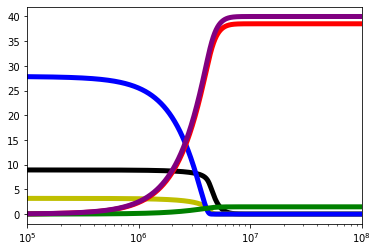

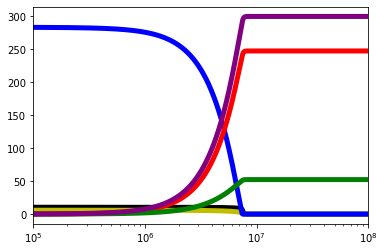

In [185]:
###### We introduce Multiple pathway-Filibrilization model 
## hCT like non-canonical concentration dependent lag time
## Figure 6A
import matplotlib.pyplot as plt
import numpy as np
import math
import gc
from matplotlib.ticker import FormatStrFormatter
from scipy.integrate import solve_ivp
from scipy.integrate import odeint
import matplotlib.cm as cm
import pandas as pd
plt.close('all')

for nf2 in [15]:        ## Tune the parameter of interest
    #p0 = [0Kd-p, 1kd-, 2Phi_BN, 3Nd, 4Nf, 5Ns, , 15Phi_CR1, 7Phi_CR2, 8Kf1-p;1st-pathway, 9Kf1-;1st-pathway, 10Kf2-p;2nd-pathway, 11Kf2-;2nd-pathway, 12Kfrag, 13G1, 14G2] 
    p0=   [0,     0,    0,       0,   4,  nf2 ,  0.01,    0.01,    10**(-4),         5*10**(-8),         5*10**(-5),                   5*10**(-8),           0,       6,   10 ]       # Free parameters in our model        
    yy=[0.6,0.8,1,1.5,2,3,4,8,10,15,20,30,40,60,80,100,150,200,300,400]                                   #### Discrete point initial peptide concentrations 
    n=len(yy)                                                                                                                                      #### Total discrete point concentration
    
    
    ##################################################
    # Define a function to solve all rate-mass equations
    def func0(t, u): 
        du = [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0]         # Introduce all states in our model
        #### Aproximate nf1+10 and truncate the high order dependency
        if t>0:
            if u[0]> p[6]:
                nf1plus1= u[18]  
            else:
                nf1plus1= u[18]*(u[0]/p[6])
        else:
            nf1plus1= 0     
        #### Aproximate nf2+10 and truncate th\ high order dependency   
        if t>0:
            if u[0]>p[7]:
                nf2plus1= u[27]
            else:
                nf2plus1= u[27]*(u[0]/p[7])
        else:
            nf2plus1= 0
         
        ### Define different terms 
        EEE1=  Kfn1*u[0]**p[4] - p[8]*u[4];                      # 1st-pathway oligomer nucleation  
        EEE2=  Kfn2*u[0]**p[5] - p[10]*u[7];                     # 2nd-pathway oligomer nucleation
        EE1=  p[4]*EEE1;                                         # monomer loss due to 1st-pathway oligomer nucleation
        EE2=  p[5]*EEE2;                                         # monomer loss due to 2st-pathway oligomer nucleation
        NNN1= (Kf1p*u[0]*u[4] - p[9]*u[10])*np.exp(-p[13])    # 1st-pathway oligomer to fibril conversion
        NNN2= (Kf2p*u[0]*u[7] - p[11]*u[19])*np.exp(-p[14])   # 2nd-pathway oligomer to fibril conversion
        NN1= (p[4]+1)* NNN1                                      # fibril mass from 1st-pathway oligomer to fibril conversion
        NN2= (p[5]+1)* NNN2                                      # fibril mass from 2nd-pathway oligomer to fibril conversion
        GG1= (Kf1p*u[0]-p[9])*u[5] +  p[9]* u[10];            # Growth and shrinking of the 1st-pathway fibril  
        GG2= (Kf2p*u[0]-p[11])*u[8] + p[11]* u[19];           # Growth and shrinking of the 2nd-pathway fibril 
        
        
        ### Introduce Fragmentation
        #JJ1= p[12]*u[6]*Fragmentation(u[6], u[5], p[4])         # fragmentation in 1st-pathway fibril
        #JJ2= p[12]*u[9]*Fragmentation(u[9], u[8], p[5])         # fragmentation in 2nd-pathway fibril
         
        ### Rate-mass equations
        du[0] = - EE1  - GG1 - NNN1 - EE2  - GG2 - NNN2                  
        du[1] = 0      
        du[2] = 0
        du[3] = 0
        du[4] = EEE1 - NNN1
        du[5] = NNN1 #+ JJ1
        du[6] = NN1 + GG1 
        du[7] = EEE2 - NNN2
        du[8] = NNN2 #+ JJ2
        du[9] = NN2 + GG2
        du[10]= (Kf1p*u[0]*u[4]*np.exp(-p[13]) -(Kf1p*u[0] + p[9]*np.exp(-p[13]))*u[10] + p[9]*u[11])
        du[11]= (Kf1p*u[0]*u[10] -(Kf1p*u[0] + p[9])*u[11] + p[9]*u[12])
        du[12]= (Kf1p*u[0]*u[11] -(Kf1p*u[0] + p[9])*u[12] + p[9]*u[13])
        du[13]= (Kf1p*u[0]*u[12] -(Kf1p*u[0] + p[9])*u[13] + p[9]*u[14])
        du[14]= (Kf1p*u[0]*u[13] -(Kf1p*u[0] + p[9])*u[14] + p[9]*u[15])
        du[15]= (Kf1p*u[0]*u[14] -(Kf1p*u[0] + p[9])*u[15] + p[9]*u[16])
        du[16]= (Kf1p*u[0]*u[15] -(Kf1p*u[0] + p[9])*u[16] + p[9]*u[17])
        du[17]= (Kf1p*u[0]*u[16] -(Kf1p*u[0] + p[9])*u[17] + p[9]*u[18])
        du[18]= (Kf1p*u[0]*u[17] -(Kf1p*u[0] + p[9])*u[18] + p[9]*nf1plus1)
        du[19]= (Kf2p*u[0]*u[7]*np.exp(-p[14]) -(Kf2p*u[0] + p[11]*np.exp(-p[14]))*u[19] + p[11]*u[20])
        du[20]= (Kf2p*u[0]*u[19] -(Kf2p*u[0] + p[11])*u[20] + p[11]*u[21])
        du[21]= (Kf2p*u[0]*u[20] -(Kf2p*u[0] + p[11])*u[21] + p[11]*u[22])
        du[22]= (Kf2p*u[0]*u[21] -(Kf2p*u[0] + p[11])*u[22] + p[11]*u[23])
        du[23]= (Kf2p*u[0]*u[22] -(Kf2p*u[0] + p[11])*u[23] + p[11]*u[24])
        du[24]= (Kf2p*u[0]*u[23] -(Kf2p*u[0] + p[11])*u[24] + p[11]*u[25])
        du[25]= (Kf2p*u[0]*u[24] -(Kf2p*u[0] + p[11])*u[25] + p[11]*u[26])
        du[26]= (Kf2p*u[0]*u[25] -(Kf2p*u[0] + p[11])*u[26] + p[11]*u[27])
        du[27]= (Kf2p*u[0]*u[26] -(Kf2p*u[0] + p[11])*u[27] + p[11]*nf2plus1)
        
        #if t>1000:
            #print(EEE1,EEE2,NNN1,NNN2,GG1,GG2,u[5],u[8])
        #if du[6]< 0 and u[0]< p[6]:
            #sigma= u[0]/p[6]
            #kdeno= sigma + p[4]+1 - (p[4]+1)*sigma
            #knum= 1 + kdeno
            #Kdf= du[6]/u[6]
            #du[10]=Kdf*u[10] - (knum/kdeno)*u[10]*du[0]/u[0]*sigma/(1-sigma)
            #du[5]= Kdf*u[5] - (1/kdeno)*u[5]*du[0]/u[0]*sigma/(1-sigma)
            
        #if u[0]< p[6]:
            #print(u[10],u[0],u[0]/p[6],u[0]/p[7],u[5],u[8],u[10]/(1-u[0]/p[6]),u[19]/(1-u[0]/p[7]),u[6],u[9],u[10]*((p[4]+1)- p[4]*(u[0]/ p[6]))/(1-u[0]/p[6])**2,u[19]*((p[5]+1)- p[5]*(u[0]/ p[7]))/(1-u[0]/p[7])**2)
            #print(du[0]/u[0],du[4]/u[4],du[5]/u[5],du[6]/u[6],du[7]/u[7],du[8]/u[8],du[9]/u[9])
        #if du[6] < 0:
            #du[5]= du[6]/u[6]*u[5]
            #du[0]=0;du[1]=0;du[2]=0;du[3]=0;du[4]=0;du[5]=0;du[6]=0;du[7]=0;du[8]=0;du[9]=0;
        return du
    
    
    ##################################################
    # Define how long we calculate (end-time) the time evolution of states for all concentrations
    x17=1*10**12; x16=5*10**10; x15=5*10**9; x14=1*10**9; x13=1*10**9;
    tend=[x17,x17,x17,x17,x16,x16,x16,x15,x15,x15,x14,x14,x14,x14,x14,x14,x14,x14,x13,x13,x13,x13,x13,x13,x13,x13,x13,x13,x13]
    
    ##################################################
    # Define the fragmentation function 
    def Fragmentation(x,y,z):
        if y==0:
            out=1
        elif x/y < z:
            out=0
        else:
            out=1
        return out
    ###################################################
    # Initialize an empty DataFrame to store the time-step and the corresponding fibril-mass
    df = pd.DataFrame()
   
    #########################################################################
    for i in [12,18]:#range(n):
        y0 = [yy[i],0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0]                           ## Introduce the initial condition
        p  = p0                                                  ## parameters in our model
        Kf1p = float(f"{p[9]/p[6]:.5e}")                         ## Monomer-addition rate in 1st-pathway 
        Kf2p = float(f"{p[11]/p[7]:.5e}")                        ## Monomer-addition rate in 2nd-pathway 
        Kfn1 = float(f"{(Kf1p*(Kf1p/p[8])**(p[4]-2)):.5e}")      ## Oligomer nucleation rate in 1st-pathway 
        Kfn2 = float(f"{(Kf2p*(Kf2p/p[10])**(p[5]-2)):.5e}")     ## Oligomer nucleation rate in 2nd-pathway
        
        tspan1 = (0,1)
        t_eval1 = np.linspace(tspan1[0], tspan1[1], 1000000)
        sol1 = solve_ivp(func0, tspan1, y0, t_eval=t_eval1, method='BDF', atol=1e-10, rtol=1e-10)
            
        tspan2 = (1, tend[i])
        t_eval2 = np.logspace(np.log10(tspan2[0]), np.log10(tspan2[1]), 1000000)
        sol2 = solve_ivp(func0, tspan2, sol1.y[:, -1], t_eval=t_eval2, method='BDF', atol=1e-10, rtol=1e-10)
        
#         tspan3 = (0.000001, 1)
#         t_eval3 = np.logspace(np.log10(tspan3[0]), np.log10(tspan3[1]), 1000000)
#         sol3 = solve_ivp(func0, tspan3, sol2.y[:, -1], t_eval=t_eval3, method='BDF', atol=1e-10, rtol=1e-10)
        
#         tspan4 = (1, tend[i])
#         t_eval4 = np.logspace(np.log10(tspan4[0]), np.log10(tspan4[1]), 1000000)
#         sol4 = solve_ivp(func0, tspan4, sol3.y[:, -1], t_eval=t_eval4, method='BDF', atol=1e-10, rtol=1e-10)
            
        sol_t = np.concatenate((sol1.t, sol2.t))
        sol_y = np.hstack((sol1.y, sol2.y))
        
        plt.plot(sol_t,sol_y[0, :],'k',linewidth = 5)
        plt.plot(sol_t, p[4]*sol_y[4, :],'y',linewidth = 5)
        plt.plot(sol_t, p[5]*sol_y[7, :],'b',linewidth = 5)
        #plt.plot(sol.t, sol.y[5, :],'r',linewidth = 5)
        #plt.plot(sol.t, sol.y[8, :],'g',linewidth = 5)
        plt.plot(sol_t, sol_y[6, :],'r',linewidth = 5)
        plt.plot(sol_t, sol_y[9, :],'g',linewidth = 5)
        plt.plot(sol_t, sol_y[6, :] + sol_y[9, :],'purple',linewidth = 5)
        #plt.ylabel('Mass concentration (\u03bcM)',fontsize=15)
        #plt.xlabel('Time (s)',fontsize=15)
        #plt.xticks(fontsize=10)
        #plt.yticks(fontsize=10)
        #myleg = plt.legend(['Monomer','Oligomer','Fibril'],loc='upper left',prop = {'size':8}, bbox_to_anchor=(0.05,1.15), ncol=6, frameon=False )
        #plt.gca().ticklabel_format(style='sci', axis='x', scilimits=(0,0))
        
        plt.xscale('log')
        #plt.title('Linear Scale')
        #myleg = plt.legend(['Monomer','Oligomer1','Oligomer2', 'Cf1','Cf2','Fibril1','Fibril2','Total_Fibril' ],loc='upper left',prop = {'size':8,'weight':'bold'}, bbox_to_anchor=(1.05,1)) 
        #plt.tight_layout()
        #plt.xlim(1,tend[i])
        plt.xlim(100000,100000000)
        plt.show()
        
        
        ############################################################################################################################################36
        # Make dataframe of time and fibril mass for the given discrete initial protein concentrations
        list1 = sol_t                                                                # List of time for the given concentration
        list2 = sol_y[6]+ sol_y[9]                                                   # List of fibril-mass for the given concentration
        temp_df = pd.DataFrame({f'Column{2*i+1}': list1, f'Column{2*i+2}': list2})   # Append the lists to the DataFrame as new columns
        df = pd.concat([df,temp_df],axis=1)                                          # Append the new DataFrame to the main DataFrame
        del list1, list2, sol1 #, sol2, sol3, sol4                                                        # Clear memory of the lists
        gc.collect()
    #################################################################################################################################################37
    # Convert dataframe into numpy array
    array = df.to_numpy()
    #save the numpy array
    #np.save(f'variation_hCT.npy', array.T)## keep the name of npy file
    #np.save(f'control.npy', array.T)## keep the name of npy file
    ##################################################################################################################################################38
   

In [182]:
### Plot the half-time as a function of concentration
### load the saved data in .npy files

import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import interp1d

def removenan(x):
    return np.array([arr[~np.isnan(arr)] for arr in x])

def plot_t50_curve(x, n, Y0, marker='o', label='', cutoff_adjustment=0.01, color='black'):
    t50 = []
    Y050 = []

    Y00 = [y - cutoff_adjustment for y in Y0]
    for i in range(n):
        cutoff_value = (Y00[i]- cutoff_adjustment) / 2
        fibril_curve = x[2 * i + 1]
        time_curve = x[2 * i]

        for fibril_val, time_val in zip(fibril_curve, time_curve):
            if fibril_val >= cutoff_value:
                t50.append(time_val)
                Y050.append(Y0[i])
                break

    f = interp1d(Y050, t50, kind='cubic')
    t50_interp = f(Y050)

    plt.plot(
        np.concatenate([Y050, [None], Y050]),np.concatenate([t50, [None], t50_interp]),
        linestyle='-',marker=marker,label=label,linewidth=2,markersize=10,color=color)

    plt.xlabel(r'Concentration, $\mu$M', fontsize=15)
    plt.ylabel(r'$\tau_{50}$, sec', fontsize=15)
    plt.xscale('log')
    plt.yscale('log')
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)
    return

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


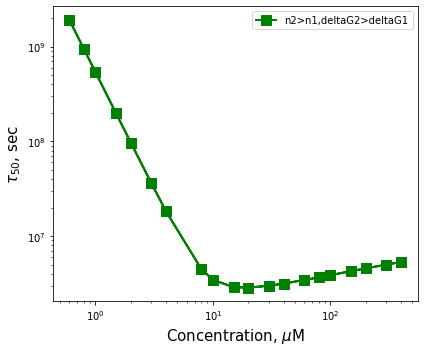

In [183]:
# Load and clean data
#x1 = removenan(np.load('control.npy'))
x2 = removenan(np.load('variation_hCT.npy'))
#x3 = removenan(np.load('variation_amor.npy'))
# x4 = removenan(np.load('variation_nf2_15_G2_6.npy'))
# x5 = removenan(np.load('variation_nf2_15_G2_8.npy'))
# x6 = removenan(np.load('variation_nf2_15_G2_10.npy'))

# Define shared Y0
Y0_common = [0.6, 0.8, 1, 1.5, 2, 3, 4, 8, 10, 15, 20, 30, 40, 60, 80, 100, 150, 200, 300, 400]

# Plot both conditions
plt.figure(figsize=(6, 5))
#plot_t50_curve(x1, n=25, Y0=Y0_common, marker='o', label='C', color='blue',cutoff_adjustment=0.01)
plot_t50_curve(x2, n=20, Y0=Y0_common + [401], marker='s', label='n2>n1,deltaG2>deltaG1', color='green', cutoff_adjustment=0.01)
#plot_t50_curve(x3, n=25, Y0=Y0_common + [1001], marker='D', label='amor',color='red', cutoff_adjustment=0.01)
# plot_t50_curve(x4, n=25, Y0=Y0_common + [1001], marker='^', label='nf2_15_G2_6', color='orange', cutoff_adjustment=0.01)
# plot_t50_curve(x5, n=25, Y0=Y0_common + [1001], marker='H', label='nf2_15_G2_8', color='purple', cutoff_adjustment=0.01)
# plot_t50_curve(x6, n=25, Y0=Y0_common + [1001], marker='*', label='nf2_15_G2_10', color='magenta', cutoff_adjustment=0.01)
#plt.ylim(4e5, 4e11)
plt.legend()
plt.tight_layout()
#plt.title('nf2 variation')
plt.savefig('Paper3_hCT.eps', dpi=300)
plt.show()

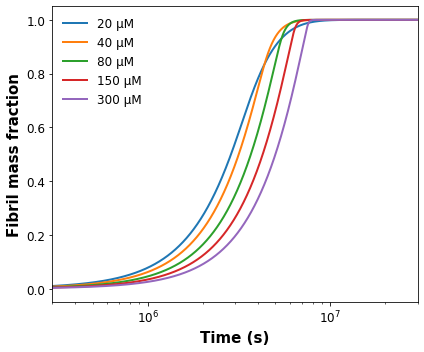

In [184]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def plotFibrilfractions(x, conc, phi_CR, conc_select, logx=True):

    # find indices of selected concentrations
    indices = [conc.index(c) for c in conc_select]

    palette = sns.color_palette("tab10", len(indices))

    plt.figure(figsize=(6,5))

    for j, i in enumerate(indices):

        time_data = x[2*i]
        max_fibril = conc[i] - phi_CR
        fibril_data = x[2*i+1] / max_fibril

        plt.plot(
            time_data,
            fibril_data,
            lw=2,
            color=palette[j],
            label=f'{conc[i]} μM'
        )

    plt.xlabel('Time (s)', fontsize=15, fontweight='bold')
    plt.ylabel('Fibril mass fraction', fontsize=15, fontweight='bold')

    if logx:
        plt.xscale('log')

    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)
    plt.xlim(300000,30000000)
    plt.legend(frameon=False, fontsize=12)

    plt.tight_layout()
    plt.show()
    
    
conc = [0.6, 0.8, 1, 1.5, 2, 3, 4, 8, 10, 15, 20, 30, 40, 60, 80, 100, 150, 200, 300, 400]

conc_select = [20, 40, 80, 150, 300]

data = np.load('variation_hCT.npy')

plotFibrilfractions(data, conc, phi_CR=0.01, conc_select=conc_select)

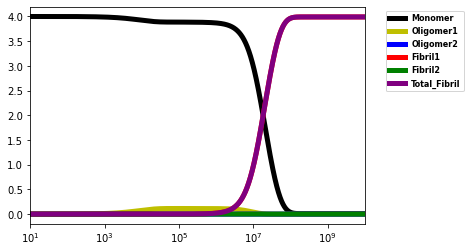

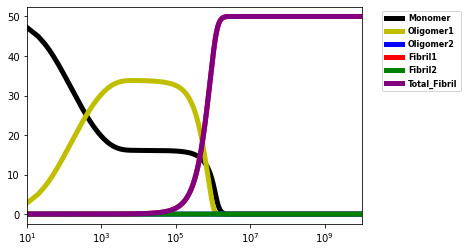

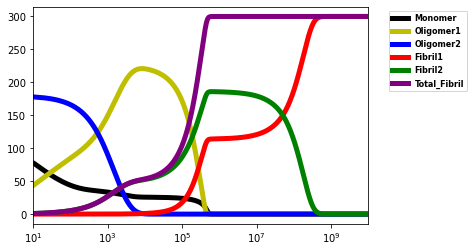

In [144]:
### Semi_Final version but not working for same delataG

### Figure 7A reproduce

### for first unstable/ second stable fibril

###### We introduce Multiple pathway-Filibrilization model normalized by phi_CR1
import matplotlib.pyplot as plt
import numpy as np
import math
import matplotlib.cm as cm
from matplotlib.ticker import FormatStrFormatter
from scipy.integrate import solve_ivp
from scipy.integrate import odeint
plt.close('all')

### Create lists for half-time, half-fibril mass and initial peptide concentration to plot half_time vs Conc plot
t50_alla=[]
fibril_alla=[]
Y0_alla=[]
switch=0
global switch

for G in [5*10**(-4)]:        ## Tune the parameter of interest
    #p0 = [0Kd-p, 1kd-, 2Phi_BN, 3Nd, 4Nf, 5Ns, 6Phi_CR1, 7Phi_CR2, 8Kf1-p;1st-pathway, 9Kf1-;1st-pathway, 10Kf2-p;2nd-pathway, 11Kf2-;2nd-pathway, 12Kfrag, 13G1, 14G2] 
    p0=   [0,     0,    0,       0,   4,   15,  0.01,    0.1,    1*10**(-4),         5*10**(-8),         G,                   5*10**(-7),           0,       6,   0 ]       # Free parameters in our model        
    yyy=[0.6,0.8,1,2,4,8,10,20,31,40,50,60,71,80,90,100,200,300,400,500]                                   #### Discrete point initial peptide concentrations 
    yy = [x / p0[6] for x in yyy]                                                                                                                    #### Discrete point initial peptide concentrations 
    n= len(yyy)                                                                                                                                      #### Total discrete point concentration
    phi_su1=p0[8]*p0[6]/p0[9]
    phi_su2=p0[10]*p0[7]/p0[11]
    
    ##################################################
    # Define a function to solve all rate-mass equations
    def func0(t, u): 
        global switch
        du = [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0]         # Introduce all states in our model
        #### Aproximate nf1+10 and truncate the high order dependency
        CC1=0;CC2=0;FF1=0;FF2=0;
        for i in range (10,27):
            CC1 += u[i]
            FF1 += (p[4]+ (i-9))*u[i]
            #print(CC1, FF1)
        for i in range (27,44):
            CC2 += u[i]
            FF2 += (p[5]+ (i-26))*u[i]
        #### Aproximate nf1+9 and truncate the high order dependency        
        if t>0:
            if u[25]<= 0:
                n1plus1= 0
            else:
                if u[0]>= 1:
                    n1plus1= u[26]*u[26]/u[25]
                else :
                    CC3= u[5] -  CC1                   #u[26]/(1-sigma)
                    FF3= u[6] -  FF1                   #u[26]* (p[4]+1 - p[4]*sigma)/(1-sigma)**2
                    if CC3 <= 0 or FF3 < 0  or FF3/CC3 <= p[4]+ 17:
                        #print(u[5],u[6],u[10],u[11],u[12])
                        n1plus1=0
                        switch=1
                    else:
                        n1plus1= CC3/((FF3/CC3-(p[4]+17)))      
                    
        else:
            n1plus1= 0     
        #### Aproximate nf2+9 and truncate the high order dependency   
        if t>0:
            if u[42]<= 0:
                n2plus1= 0
            else:
                if u[0]>= p[7]/p[6]:
                    n2plus1= u[43]*u[43]/u[42]
                else:
                    CC4= u[8] -  CC2        #u[35]/(1-sigma)
                    FF4= u[9] -  FF2        #u[35]* (p[5]+1-p[5]*sigma)/(1-sigma)**2
                    if CC4 <=0 or FF4 <= 0 or FF4/CC4 <= p[5]+17:
                        n2plus1=0
                    else:
                        n2plus1= CC4/((FF4/CC4 -(p[5]+17)))
        else:
            n2plus1= 0
        
        
         
        ### Define different terms 
        EEE1=  (p[6]/phi_su1)**(p[4]-1)*u[0]**p[4] - u[4];                      # 1st-pathway oligomer nucleation  
        EEE2=  p[10]/p[8]*((p[6]/phi_su2)**(p[5]-1)*u[0]**p[5] - u[7]);                      # 2nd-pathway oligomer nucleation
        EE1=   p[4]*EEE1;                                                        # monomer loss due to 1st-pathway oligomer nucleation
        EE2=   p[5]*EEE2;                                                        # monomer loss due to 2st-pathway oligomer nucleation
        NNN1=  (p[6]/phi_su1)*(u[0]*u[4] - u[10])*np.exp(-p[13])                 # 1st-pathway oligomer to fibril conversion
        NNN2=  p[10]/p[8]*(p[6]/phi_su2)*(u[0]*u[7] - u[27]*p[7]/p[6])*np.exp(-p[14])       # 2nd-pathway oligomer to fibril conversion
        NN1=  (p[4]+1)* NNN1                                                     # fibril mass from 1st-pathway oligomer to fibril conversion
        NN2=  (p[5]+1)* NNN2                                                     # fibril mass from 2nd-pathway oligomer to fibril conversion
        GG1= (u[0]-1)*u[5]*(p[6]/phi_su1) +  (p[6]/phi_su1)* u[10];                              # Growth and shrinking of the 1st-pathway fibril  
        GG2=  p[10]/p[8]*((u[0]-p[7]/p[6])*u[8]*(p[6]/phi_su2) + (p[7]/phi_su2)* u[27]);                             # Growth and shrinking of the 2nd-pathway fibril 
        
        ### Introduce Fragmentation
        #JJ1= p[12]*u[6]*Fragmentation(u[6], u[5], p[4])         # fragmentation in 1st-pathway fibril
        #JJ2= p[12]*u[9]*Fragmentation(u[9], u[8], p[5])         # fragmentation in 2nd-pathway fibril
        
        

        
        ### Rate-mass equations
        du[0] = - EE1  - GG1 - NNN1 - EE2  - GG2 - NNN2                  
        du[1] = 0      
        du[2] = 0
        du[3] = 0
        du[4] = EEE1 - NNN1
        du[5] = NNN1 #+ JJ1
        du[6] = NN1 + GG1 
        du[7] = EEE2 - NNN2
        du[8] = NNN2 #+ JJ2
        du[9] = NN2 + GG2
        
        
    
        du[10]= (u[0]*u[4]*np.exp(-p[13]) -(u[0] + np.exp(-p[13]))*u[10] + u[11])*p[6]/phi_su1
        du[11]= (u[0]*u[10] -(u[0] + 1)*u[11] + u[12])*p[6]/phi_su1
        du[12]= (u[0]*u[11] -(u[0] + 1)*u[12] + u[13])*p[6]/phi_su1
        du[13]= (u[0]*u[12] -(u[0] + 1)*u[13] + u[14])*p[6]/phi_su1
        du[14]= (u[0]*u[13] -(u[0] + 1)*u[14] + u[15])*p[6]/phi_su1
        du[15]= (u[0]*u[14] -(u[0] + 1)*u[15] + u[16])*p[6]/phi_su1
        du[16]= (u[0]*u[15] -(u[0] + 1)*u[16] + u[17])*p[6]/phi_su1
        du[17]= (u[0]*u[16] -(u[0] + 1)*u[17] + u[18])*p[6]/phi_su1
        du[18]= (u[0]*u[17] -(u[0] + 1)*u[18] + u[19])*p[6]/phi_su1
        du[19]= (u[0]*u[18] -(u[0] + 1)*u[19] + u[20])*p[6]/phi_su1
        du[20]= (u[0]*u[19] -(u[0] + 1)*u[20] + u[21])*p[6]/phi_su1
        du[21]= (u[0]*u[20] -(u[0] + 1)*u[21] + u[22])*p[6]/phi_su1
        du[22]= (u[0]*u[21] -(u[0] + 1)*u[22] + u[23])*p[6]/phi_su1
        du[23]= (u[0]*u[22] -(u[0] + 1)*u[23] + u[24])*p[6]/phi_su1
        du[24]= (u[0]*u[23] -(u[0] + 1)*u[24] + u[25])*p[6]/phi_su1
        du[25]= (u[0]*u[24] -(u[0] + 1)*u[25] + u[26])*p[6]/phi_su1
        du[26]= (u[0]*u[25] -(u[0] + 1)*u[26] + n1plus1)*p[6]/phi_su1
        
        
        du[27]= p[10]/p[8]*(u[0]*u[7]*np.exp(-p[14]) -(u[0] + p[7]/p[6]*np.exp(-p[14]))*u[27] + p[7]/p[6]*u[28])*p[6]/phi_su2
        du[28]= p[10]/p[8]*(u[0]*u[27] -(u[0] + p[7]/p[6])*u[28] + p[7]/p[6]*u[29])*p[6]/phi_su2
        du[29]= p[10]/p[8]*(u[0]*u[28] -(u[0] + p[7]/p[6])*u[29] + p[7]/p[6]*u[30])*p[6]/phi_su2
        du[30]= p[10]/p[8]*(u[0]*u[29] -(u[0] + p[7]/p[6])*u[30] + p[7]/p[6]*u[31])*p[6]/phi_su2
        du[31]= p[10]/p[8]*(u[0]*u[30] -(u[0] + p[7]/p[6])*u[31] + p[7]/p[6]*u[32])*p[6]/phi_su2
        du[32]= p[10]/p[8]*(u[0]*u[31] -(u[0] + p[7]/p[6])*u[32] + p[7]/p[6]*u[33])*p[6]/phi_su2
        du[33]= p[10]/p[8]*(u[0]*u[32] -(u[0] + p[7]/p[6])*u[33] + p[7]/p[6]*u[34])*p[6]/phi_su2
        du[34]= p[10]/p[8]*(u[0]*u[33] -(u[0] + p[7]/p[6])*u[34] + p[7]/p[6]*u[35])*p[6]/phi_su2
        du[35]= p[10]/p[8]*(u[0]*u[34] -(u[0] + p[7]/p[6])*u[35] + p[7]/p[6]*u[36])*p[6]/phi_su2
        du[36]= p[10]/p[8]*(u[0]*u[35] -(u[0] + p[7]/p[6])*u[36] + p[7]/p[6]*u[37])*p[6]/phi_su2
        du[37]= p[10]/p[8]*(u[0]*u[36] -(u[0] + p[7]/p[6])*u[37] + p[7]/p[6]*u[38])*p[6]/phi_su2
        du[38]= p[10]/p[8]*(u[0]*u[37] -(u[0] + p[7]/p[6])*u[38] + p[7]/p[6]*u[39])*p[6]/phi_su2
        du[39]= p[10]/p[8]*(u[0]*u[38] -(u[0] + p[7]/p[6])*u[39] + p[7]/p[6]*u[40])*p[6]/phi_su2
        du[40]= p[10]/p[8]*(u[0]*u[39] -(u[0] + p[7]/p[6])*u[40] + p[7]/p[6]*u[41])*p[6]/phi_su2
        du[41]= p[10]/p[8]*(u[0]*u[40] -(u[0] + p[7]/p[6])*u[41] + p[7]/p[6]*u[42])*p[6]/phi_su2
        du[42]= p[10]/p[8]*(u[0]*u[41] -(u[0] + p[7]/p[6])*u[42] + p[7]/p[6]*u[43])*p[6]/phi_su2
        du[43]= p[10]/p[8]*(u[0]*u[42] -(u[0] + p[7]/p[6])*u[43] + p[7]/p[6]*n2plus1)*p[6]/phi_su2
            
        if switch == 1 and u[0]< p[7]:
            #du[10]= (u[0]*u[4]*np.exp(-p[13]) -(u[0] + np.exp(-p[13]))*u[10] + u[11])*p[6]/phi_su1
            #du[27]= (u[0]*u[7]*np.exp(-p[14]) -(u[0] + p[7]/p[6]*np.exp(-p[14]))*u[27] + p[7]/p[6]*u[28])*p[6]/phi_su2
            CC5= u[5] -  u[10]                 #u[26]/(1-sigma)
            FF5= u[6] -  (p[4]+1)*u[10]   
            #CC6= u[8] -  u[27]                 #u[26]/(1-sigma)
            #FF6= u[9] -  (p[5]+1)*u[27]  
            u[11]= CC5/(FF5/CC5-p[4]-1)
            du[10]= (u[0]*u[4]*np.exp(-p[13]) -(u[0] + np.exp(-p[13]))*u[10] + u[11])*p[6]/phi_su1
            #u[28]= CC6/(FF6/CC6-p[5]-1)
            for i in range(11,27):
                du[i]=0 
            for i in range(11,26):
                u[i+1]=0
            #for i in range(28,44):
                #du[i]=0 
            #for i in range(28,43):
                #u[i+1]=0
        
        #if u[0]< 0.5:
            #for j in range(10,19):
                #if u[j]<0:
                    #u[j]=0; 
                    #du[j]=0
                        
        #if t>1000:
            #print(EEE1,EEE2,NNN1,NNN2,GG1,GG2,u[5],u[8])
        #if du[6]< 0 and u[0]< 1 and u[0]> p[7]/p[6]:
            #sigma= u[0]
            #kdeno= sigma + p[4]+1 - (p[4]+1)*sigma
            #knum= 1 + kdeno
            #Kdf= du[6]/u[6]
            #du[10]=Kdf*u[10] #- (knum/kdeno)*u[10]*du[0]/u[0]*sigma/(1-sigma)
            #du[5]= Kdf*u[5] #- (1/kdeno)*u[5]*du[0]/u[0]*sigma/(1-sigma)
            
        #if u[0]< p[6]:
            #print(u[10],u[0],u[0]/p[6],u[0]/p[7],u[5],u[8],u[10]/(1-u[0]/p[6]),u[19]/(1-u[0]/p[7]),u[6],u[9],u[10]*((p[4]+1)- p[4]*(u[0]/ p[6]))/(1-u[0]/p[6])**2,u[19]*((p[5]+1)- p[5]*(u[0]/ p[7]))/(1-u[0]/p[7])**2)
            #print(du[0]/u[0],du[4]/u[4],du[5]/u[5],du[6]/u[6],du[7]/u[7],du[8]/u[8],du[9]/u[9])
        #if du[6] < 0 and u[0]< 1:
        #if u[0]< 1 and t>1000000000:
            #print(t,u[0],u[4],u[10],u[11],u[12],u[13],u[14],u[15],u[16],u[17],u[18])
            #print(t,p[6]*u[0], p[6]*u[4], p[6]*u[7], n1plus1, n2plus1, p[6]*u[5],p[6]*u[8],p[6]*FF1, p[6]*FF2, p[6]*u[6],p[6]*u[9])#,p[6]*u[10]/(1-u[0]),p[6]*u[19]/(1-u[0]),p[6]*u[10]*((p[4]+1)- p[4]*p[6]*u[0])/(1-u[0])**2, p[6]*u[19]*((p[5]+1)- p[5]*p[6]*u[0])/(1-u[0])**2)
            #print(t, p[6]*u[0],p[6]*n1plus1, p[6]*u[4],p[6]*u[5],p[6]*u[6],p[6]*u[9],p[6]*u[10],p[6]*u[11],p[6]*u[12], p[6]*CC1, p[6]*FF1, switch)
        return du
    
    
    ##################################################
    # Define how long we calculate (end-time) the time evolution of states for all concentrations
    x17=1*10**10; x16=1*10**10; x15=1*10**10; x14=1*10**10; x13=1*10**10;
    tend0 = [x17,x17,x17,x16,x16,x16,x15,x15,x15,x14,x14,x14,x14,x14,x14,x14,x14,x13,x13,x13]
    tend = [y*p0[8] for y in tend0]  
    
    ##################################################
    # Define the fragmentation function 
    def Fragmentation(x,y,z):
        if y==0:
            out=1
        elif x/y < z:
            out=0
        else:
            out=1
        return out
    ###################################################
    # Introduce lists to keep fibril-mass evolution and corresponding time
    fibril1a=[]
    time1a=[]
    oligomer1a=[]
    oligomer2a=[]
    totalfibril1a=[]
    totalfibril2a=[]
    
    #########################################################################
    for i in [4,10,17]: #range(3,n):
        switch=0
        y0 = [yy[i],0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0]                           ## Introduce the initial condition
        p  = p0                                                  ## parameters in our model
        #Kf1p = float(f"{p[9]/p[6]:.5e}")                         ## Monomer-addition rate in 1st-pathway 
        #Kf2p = float(f"{p[11]/p[7]:.5e}")                        ## Monomer-addition rate in 2nd-pathway 
        #Kfn1 = float(f"{(Kf1p*(Kf1p/p[8])**(p[4]-2)):.5e}")      ## Oligomer nucleation rate in 1st-pathway 
        #Kfn2 = float(f"{(Kf2p*(Kf2p/p[10])**(p[5]-2)):.5e}")     ## Oligomer nucleation rate in 2nd-pathway
        
#         tspan  = (0,tend[i])                                     ## time span between initial and final time 
#         t_eval = np.linspace(0, tend[i],10000000)                 ## time interval to record the measured calculations
#         atol = 10**(-12)                                         ## absolute tolerence
#         rtol = 10**(-12)                                         ## relative tolerence
#         sol  = solve_ivp(func0,tspan,y0, t_eval=t_eval, method ='BDF',atol=atol, rtol=rtol)
        ###Case I
        
        
        tspan1 = (0, 1000)
        t_eval1 = np.linspace(tspan1[0], tspan1[1], 1000000)
        #t_eval1 = np.logspace(np.log10(tspan1[0]), np.log10(tspan1[1]), 1000000)
        sol1 = solve_ivp(func0, tspan1, y0, t_eval=t_eval1, method='BDF',  atol=1e-12, rtol=1e-12)

        tspan2 = (tspan1[1], 100000)
        t_eval2 = np.logspace(np.log10(tspan2[0]), np.log10(tspan2[1]), 1000000)
        #t_eval2 = np.linspace(tspan2[0], tspan2[1], 1000000)
        sol2 = solve_ivp(func0, tspan2, sol1.y[:, -1], t_eval=t_eval2, method='BDF',  atol=1e-12, rtol=1e-12)

        tspan3 = (tspan2[1], tend[i])
        t_eval3 = np.logspace(np.log10(tspan3[0]), np.log10(tspan3[1]), 1000000)
        #t_eval3 = np.linspace(tspan3[0], tspan3[1], 1000000)
        sol3 = solve_ivp(func0, tspan3,sol2.y[:, -1], t_eval=t_eval3, method='BDF', atol=1e-12, rtol=1e-12)
        
        
            
        sol_t = np.concatenate((sol1.t, sol2.t, sol3.t))
        sol_y = np.hstack((sol1.y, sol2.y, sol3.y))
        
        
        fibril1a.append(p[6]*sol_y[6] + p[6]*sol_y[9])                ## append the fibril mass evolution in the list
        time1a.append(sol_t/p[8])                                     ## append the time-measured in the list
        oligomer1a.append(p[4]*p[6]*sol_y[4])
        oligomer2a.append(p[5]*p[6]*sol_y[7])
        totalfibril1a.append(p[6]*sol_y[6])
        totalfibril2a.append(p[6]*sol_y[9])
        #print(sol_t/p[8])
        #print(sol.y[0])
        #print(p[4]*sol.y[7])
        #print(sol.y[9])
        
        plt.plot(sol_t/p[8], p[6]*sol_y[0, :],'k',linewidth = 5)
        plt.plot(sol_t/p[8], p[6]*p[4]*sol_y[4, :],'y',linewidth = 5)
        plt.plot(sol_t/p[8], p[6]*p[5]*sol_y[7, :],'b',linewidth = 5)
        #plt.plot(sol_t/p[8], p[6]*sol_y[5, :],'r',linewidth = 5)
        #plt.plot(sol_t/p[8], p[6]*sol_y[8, :],'g',linewidth = 5)
        plt.plot(sol_t/p[8], p[6]*sol_y[6, :],'r',linewidth = 5)
        plt.plot(sol_t/p[8], p[6]*sol_y[9, :],'g',linewidth = 5)
        plt.plot(sol_t/p[8], p[6]*sol_y[6, :] + p[6]*sol_y[9, :],'purple',linewidth = 5)
           
        
        
        #plt.ylabel('Mass concentration (\u03bcM)',fontsize=15)
        #plt.xlabel('Time (s)',fontsize=15)
        #plt.xticks(fontsize=10)
        #plt.yticks(fontsize=10)
        #myleg = plt.legend(['Monomer','Oligomer','Fibril'],loc='upper left',prop = {'size':8}, bbox_to_anchor=(0.05,1.15), ncol=6, frameon=False )
        #plt.gca().ticklabel_format(style='sci', axis='x', scilimits=(0,0))
       
        #if i ==0:
            #plt.text(0.85, 0.8, " CNT w/D  ", fontsize=12, ha='center', va='center', transform=plt.gca().transAxes)
            #plt.savefig('fig2a_C.eps',dpi=300)
        #if i ==9:
            #plt.text(0.85, 0.8, " CNT w/D  ", fontsize=12, ha='center', va='center', transform=plt.gca().transAxes)
            #plt.savefig('fig2b_C.eps',dpi=300)
        #if i==13:
            #plt.text(0.85, 0.8, " CNT w/D  ", fontsize=12, ha='center', va='center', transform=plt.gca().transAxes)
            #plt.savefig('fig2c_C.eps',dpi=300)
        #plt.xscale('log')
        #plt.title('Linear Scale')
        #if i==0:
            #plt.text(0.000001, 5, 'I', fontsize = 22)
        #if i==1:
            #plt.text(0.000001, 40, 'II', fontsize = 22)
        #if i==2:
            #plt.text(0.000001, 27, 'III', fontsize = 22)
        #plt.subplot(1, 2, 2)
        #plt.plot(sol.t,sol.y[0, :],'k',linewidth = 5)
        #plt.plot(sol.t,p[0]*p[1] *sol.y[1, :],'y',linewidth = 5)
        #plt.plot(sol.t,sol.y[2, :],'r',linewidth = 5)
        #plt.plot(sol.t, sol.y[3, :] ,'b',linewidth = 5)
        #plt.plot(sol.t,sol.y[4, :],'g',linewidth = 5)
        #plt.xlim(0.00001,1)
        #plt.xlabel('Time', fontweight = 'bold')
        #plt.ylabel('Mass', fontweight = 'bold')
        #plt.yscale('log')
        plt.xscale('log')
        #plt.title('Linear Scale')
        myleg = plt.legend(['Monomer','Oligomer1','Oligomer2', 'Fibril1','Fibril2','Total_Fibril' ],loc='upper left',prop = {'size':8,'weight':'bold'}, bbox_to_anchor=(1.05,1)) 
        #plt.tight_layout()
        plt.xlim(10,1.0e10)
        #plt.ylim(1.0e-3,100)
        #plt.savefig('Paper3_Fig4C_loglog.eps', dpi=300)
        plt.show()
       
     ###########################################################################################
#     # Fibril Mass fraction vs time for different concentration 
#     Y0= yyy   ### Initial peptides concentration
#     print(Y0)
#     fibril_lista = [[element / Y0[p] for element in sublist] for p, sublist in enumerate(fibril1a)]
#     for sublist1, sublist2 in zip(time1a, fibril_lista):
#         plt.plot(sublist1, sublist2) #, marker='o', label='Data Points')
#     plt.xlabel('Time, s', fontweight = 'bold')
#     plt.ylabel('Fibril mass fraction', fontweight = 'bold')
#     plt.legend([f'C={c}' for c in Y0], bbox_to_anchor=(1, 0.9), loc='upper right', ncol=2, fontsize=10)
#     plt.show()
    
#     import matplotlib.pyplot as plt
#     import matplotlib.cm as cm

#     Y0 = yyy  # Initial peptide concentrations
#     num_curves = len(Y0)
#     colormap = cm.get_cmap('plasma')  # Choose a color gradient map
    
#     plt.figure(figsize=(8, 5))
#     fibril_lista = [[element / Y0[p] for element in sublist] for p, sublist in enumerate(fibril1a)]
#     for idx, (sublist1, sublist2) in enumerate(zip(time1a, fibril_lista)):
#         color = colormap(idx / (num_curves - 1))  # Normalize index to [0, 1]
#         plt.plot(sublist1, sublist2, color=color, label=f'C={Y0[idx]}')
    
#     plt.xscale('log')
#     plt.xlabel('Time, s', fontweight='bold')
#     plt.ylabel('Fibril mass fraction', fontweight='bold')
#     plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2, fontsize=9)
#     plt.tight_layout()
#     plt.show()
    
#     plt.figure(figsize=(8, 5))
#     oligomer_list1a = [[element / Y0[p] for element in sublist] for p, sublist in enumerate(oligomer1a)]
#     for idx, (sublist1, sublist2) in enumerate(zip(time1a, oligomer_list1a)):
#         color = colormap(idx / (num_curves - 1))  # Normalize index to [0, 1]
#         plt.plot(sublist1, sublist2, color=color, label=f'C={Y0[idx]}')
    
#     plt.xscale('log')
#     plt.xlabel('Time, s', fontweight='bold')
#     plt.ylabel('Oligomer_1 mass fraction', fontweight='bold')
#     plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2, fontsize=9)
#     plt.tight_layout()
#     plt.show()
    
#     plt.figure(figsize=(8, 5))
#     oligomer_list2a = [[element / Y0[p] for element in sublist] for p, sublist in enumerate(oligomer2a)]
#     for idx, (sublist1, sublist2) in enumerate(zip(time1a, oligomer_list2a)):
#         color = colormap(idx / (num_curves - 1))  # Normalize index to [0, 1]
#         plt.plot(sublist1, sublist2, color=color, label=f'C={Y0[idx]}')
    
#     plt.xscale('log')
#     plt.xlabel('Time, s', fontweight='bold')
#     plt.ylabel('Oligomer_2 mass fraction', fontweight='bold')
#     plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2, fontsize=9)
#     plt.tight_layout()
#     plt.show()
    
#     plt.figure(figsize=(8, 5))
#     fibril_list1a = [[element / Y0[p] for element in sublist] for p, sublist in enumerate(totalfibril1a)]
#     for idx, (sublist1, sublist2) in enumerate(zip(time1a, fibril_list1a)):
#         color = colormap(idx / (num_curves - 1))  # Normalize index to [0, 1]
#         plt.plot(sublist1, sublist2, color=color, label=f'C={Y0[idx]}')
    
#     plt.xscale('log')
#     plt.xlabel('Time, s', fontweight='bold')
#     plt.ylabel('fibril_1 mass fraction', fontweight='bold')
#     plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2, fontsize=9)
#     plt.tight_layout()
#     plt.show()
    
#     plt.figure(figsize=(8, 5))
#     fibril_list2a = [[element / Y0[p] for element in sublist] for p, sublist in enumerate(totalfibril2a)]
#     for idx, (sublist1, sublist2) in enumerate(zip(time1a, fibril_list2a)):
#         color = colormap(idx / (num_curves - 1))  # Normalize index to [0, 1]
#         plt.plot(sublist1, sublist2, color=color, label=f'C={Y0[idx]}')
    
#     plt.xscale('log')
#     plt.xlabel('Time, s', fontweight='bold')
#     plt.ylabel('fibril_2 mass fraction', fontweight='bold')
#     plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2, fontsize=9)
#     plt.tight_layout()
#     plt.show()
#     ###########################################################################################   
#     #Find T_Half for each concentration
#     t50=[]   
#     fibril50=[]
#     Y050=[]

#     Y0= yyy
#     for i in range(n):
#         cutoff_value = (Y0[i]- p[7])/2      #specified cutoff value
#         list_I=fibril1a[i]              
#         list_II=time1a[i]
#         # Iterate through elements in List I
#         for value_I, value_II in zip(list_I, list_II):
#             if value_I >= cutoff_value:
#                 selected_value_I = value_I
#                 selected_value_II = value_II
#                 fibril50.append(selected_value_I)
#                 t50.append(selected_value_II)
#                 Y050.append(Y0[i])
#                 break                      # Break out of the loop once the condition is met
#     t50_alla.append(t50)
#     fibril_alla.append(fibril50)
#     Y0_alla.append(Y050)
#    ############################################################################################# 
 
# ### Plot the T_half vs Concentration for the given different parameter value
# ### Plot the T_half vs Concentration for the given different parameter value
# markers = ['o', 's', '^','D','*']  # circle, square, triangle

# for i, (sublist1, sublist2) in enumerate(zip(Y0_alla, t50_alla)):
#     plt.loglog(sublist1, sublist2, marker=markers[i], linestyle='-')  # Different marker for each curve

# plt.ylabel('T_Half, sec', fontweight='bold')
# plt.xlabel('Concentration, uM', fontweight='bold')
# # plt.title('For Different off-pathway \n monomer-oligomer dissociation rate')
# plt.legend(['kf2-p=7*10^-4', 'kf2-p=7*10^-5', 'kf2-p=7*10^-6','kf2-p=7*10^-7','kf2-p=7*10^-8'], bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.tight_layout()
# plt.show()

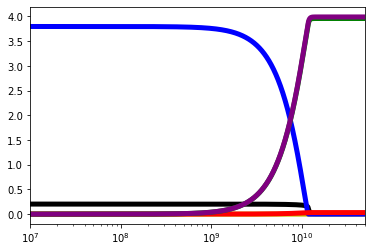

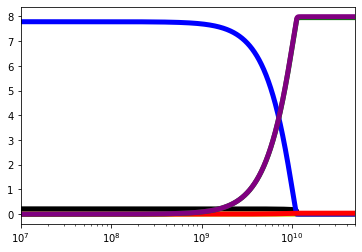

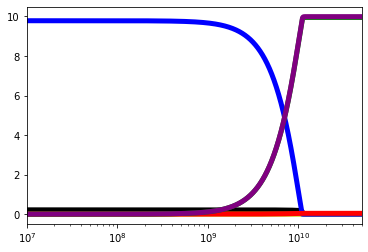

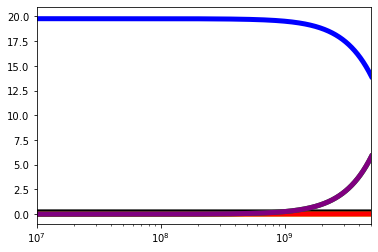

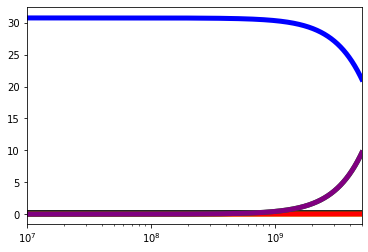

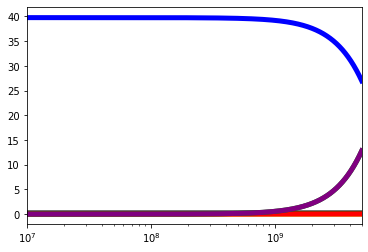

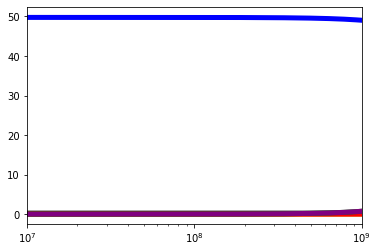

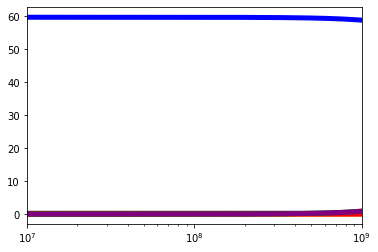

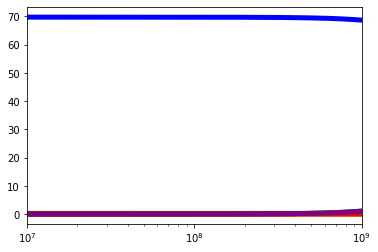

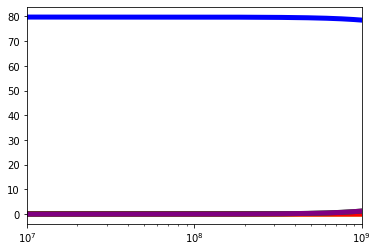

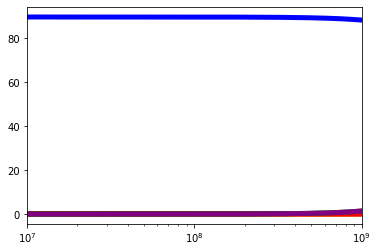

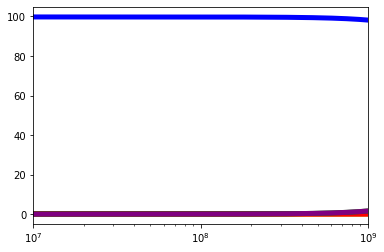

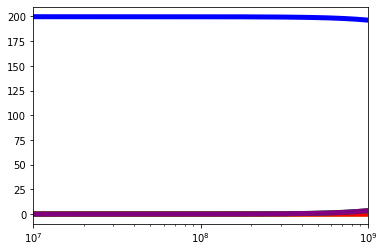

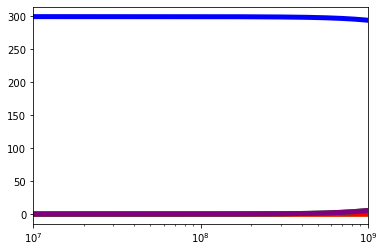

In [166]:
###### We introduce Multiple pathway-Filibrilization model 
## hCT like non-canonical concentration dependent lag time
## Figure 6A
import matplotlib.pyplot as plt
import numpy as np
import math
import gc
from matplotlib.ticker import FormatStrFormatter
from scipy.integrate import solve_ivp
from scipy.integrate import odeint
import matplotlib.cm as cm
import pandas as pd
plt.close('all')

for nf2 in [15]:        ## Tune the parameter of interest
    #p0 = [0Kd-p, 1kd-, 2Phi_BN, 3Nd, 4Nf, 5Ns, , 15Phi_CR1, 7Phi_CR2, 8Kf1-p;1st-pathway, 9Kf1-;1st-pathway, 10Kf2-p;2nd-pathway, 11Kf2-;2nd-pathway, 12Kfrag, 13G1, 14G2] 
    p0=   [0,     0,    0,       0,   4,  nf2 ,  0.01,    0.01,    10**(-4),         5*10**(-8),         1*10**(-6),                   5*10**(-8),           0,       6,   15 ]       # Free parameters in our model        
    yy=[0.6,0.8,1,2,4,8,10,20,31,40,50,60,70,80,90,100,200,300,400,500,600,700,800,900,1000]                                   #### Discrete point initial peptide concentrations 
    n=len(yy)                                                                                                                                      #### Total discrete point concentration
    
    
    ##################################################
    # Define a function to solve all rate-mass equations
    def func0(t, u): 
        du = [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0]         # Introduce all states in our model
        #### Aproximate nf1+10 and truncate the high order dependency
        if t>0:
            if u[0]> p[6]:
                nf1plus1= u[18]  
            else:
                nf1plus1= u[18]*(u[0]/p[6])
        else:
            nf1plus1= 0     
        #### Aproximate nf2+10 and truncate th\ high order dependency   
        if t>0:
            if u[0]>p[7]:
                nf2plus1= u[27]
            else:
                nf2plus1= u[27]*(u[0]/p[7])
        else:
            nf2plus1= 0
         
        ### Define different terms 
        EEE1=  Kfn1*u[0]**p[4] - p[8]*u[4];                      # 1st-pathway oligomer nucleation  
        EEE2=  Kfn2*u[0]**p[5] - p[10]*u[7];                     # 2nd-pathway oligomer nucleation
        EE1=  p[4]*EEE1;                                         # monomer loss due to 1st-pathway oligomer nucleation
        EE2=  p[5]*EEE2;                                         # monomer loss due to 2st-pathway oligomer nucleation
        NNN1= (Kf1p*u[0]*u[4] - p[9]*u[10])*np.exp(-p[13])    # 1st-pathway oligomer to fibril conversion
        NNN2= (Kf2p*u[0]*u[7] - p[11]*u[19])*np.exp(-p[14])   # 2nd-pathway oligomer to fibril conversion
        NN1= (p[4]+1)* NNN1                                      # fibril mass from 1st-pathway oligomer to fibril conversion
        NN2= (p[5]+1)* NNN2                                      # fibril mass from 2nd-pathway oligomer to fibril conversion
        GG1= (Kf1p*u[0]-p[9])*u[5] +  p[9]* u[10];            # Growth and shrinking of the 1st-pathway fibril  
        GG2= (Kf2p*u[0]-p[11])*u[8] + p[11]* u[19];           # Growth and shrinking of the 2nd-pathway fibril 
        
        
        ### Introduce Fragmentation
        #JJ1= p[12]*u[6]*Fragmentation(u[6], u[5], p[4])         # fragmentation in 1st-pathway fibril
        #JJ2= p[12]*u[9]*Fragmentation(u[9], u[8], p[5])         # fragmentation in 2nd-pathway fibril
         
        ### Rate-mass equations
        du[0] = - EE1  - GG1 - NNN1 - EE2  - GG2 - NNN2                  
        du[1] = 0      
        du[2] = 0
        du[3] = 0
        du[4] = EEE1 - NNN1
        du[5] = NNN1 #+ JJ1
        du[6] = NN1 + GG1 
        du[7] = EEE2 - NNN2
        du[8] = NNN2 #+ JJ2
        du[9] = NN2 + GG2
        du[10]= (Kf1p*u[0]*u[4]*np.exp(-p[13]) -(Kf1p*u[0] + p[9]*np.exp(-p[13]))*u[10] + p[9]*u[11])
        du[11]= (Kf1p*u[0]*u[10] -(Kf1p*u[0] + p[9])*u[11] + p[9]*u[12])
        du[12]= (Kf1p*u[0]*u[11] -(Kf1p*u[0] + p[9])*u[12] + p[9]*u[13])
        du[13]= (Kf1p*u[0]*u[12] -(Kf1p*u[0] + p[9])*u[13] + p[9]*u[14])
        du[14]= (Kf1p*u[0]*u[13] -(Kf1p*u[0] + p[9])*u[14] + p[9]*u[15])
        du[15]= (Kf1p*u[0]*u[14] -(Kf1p*u[0] + p[9])*u[15] + p[9]*u[16])
        du[16]= (Kf1p*u[0]*u[15] -(Kf1p*u[0] + p[9])*u[16] + p[9]*u[17])
        du[17]= (Kf1p*u[0]*u[16] -(Kf1p*u[0] + p[9])*u[17] + p[9]*u[18])
        du[18]= (Kf1p*u[0]*u[17] -(Kf1p*u[0] + p[9])*u[18] + p[9]*nf1plus1)
        du[19]= (Kf2p*u[0]*u[7]*np.exp(-p[14]) -(Kf2p*u[0] + p[11]*np.exp(-p[14]))*u[19] + p[11]*u[20])
        du[20]= (Kf2p*u[0]*u[19] -(Kf2p*u[0] + p[11])*u[20] + p[11]*u[21])
        du[21]= (Kf2p*u[0]*u[20] -(Kf2p*u[0] + p[11])*u[21] + p[11]*u[22])
        du[22]= (Kf2p*u[0]*u[21] -(Kf2p*u[0] + p[11])*u[22] + p[11]*u[23])
        du[23]= (Kf2p*u[0]*u[22] -(Kf2p*u[0] + p[11])*u[23] + p[11]*u[24])
        du[24]= (Kf2p*u[0]*u[23] -(Kf2p*u[0] + p[11])*u[24] + p[11]*u[25])
        du[25]= (Kf2p*u[0]*u[24] -(Kf2p*u[0] + p[11])*u[25] + p[11]*u[26])
        du[26]= (Kf2p*u[0]*u[25] -(Kf2p*u[0] + p[11])*u[26] + p[11]*u[27])
        du[27]= (Kf2p*u[0]*u[26] -(Kf2p*u[0] + p[11])*u[27] + p[11]*nf2plus1)
        
        #if t>1000:
            #print(EEE1,EEE2,NNN1,NNN2,GG1,GG2,u[5],u[8])
        #if du[6]< 0 and u[0]< p[6]:
            #sigma= u[0]/p[6]
            #kdeno= sigma + p[4]+1 - (p[4]+1)*sigma
            #knum= 1 + kdeno
            #Kdf= du[6]/u[6]
            #du[10]=Kdf*u[10] - (knum/kdeno)*u[10]*du[0]/u[0]*sigma/(1-sigma)
            #du[5]= Kdf*u[5] - (1/kdeno)*u[5]*du[0]/u[0]*sigma/(1-sigma)
            
        #if u[0]< p[6]:
            #print(u[10],u[0],u[0]/p[6],u[0]/p[7],u[5],u[8],u[10]/(1-u[0]/p[6]),u[19]/(1-u[0]/p[7]),u[6],u[9],u[10]*((p[4]+1)- p[4]*(u[0]/ p[6]))/(1-u[0]/p[6])**2,u[19]*((p[5]+1)- p[5]*(u[0]/ p[7]))/(1-u[0]/p[7])**2)
            #print(du[0]/u[0],du[4]/u[4],du[5]/u[5],du[6]/u[6],du[7]/u[7],du[8]/u[8],du[9]/u[9])
        #if du[6] < 0:
            #du[5]= du[6]/u[6]*u[5]
            #du[0]=0;du[1]=0;du[2]=0;du[3]=0;du[4]=0;du[5]=0;du[6]=0;du[7]=0;du[8]=0;du[9]=0;
        return du
    
    
    ##################################################
    # Define how long we calculate (end-time) the time evolution of states for all concentrations
    x17=1*10**12; x16=5*10**10; x15=5*10**9; x14=1*10**9; x13=1*10**9;
    tend=[x17,x17,x17,x17,x16,x16,x16,x15,x15,x15,x14,x14,x14,x14,x14,x14,x14,x14,x13,x13,x13,x13,x13,x13,x13,x13,x13,x13,x13]
    
    ##################################################
    # Define the fragmentation function 
    def Fragmentation(x,y,z):
        if y==0:
            out=1
        elif x/y < z:
            out=0
        else:
            out=1
        return out
    ###################################################
    # Initialize an empty DataFrame to store the time-step and the corresponding fibril-mass
    df = pd.DataFrame()
   
    #########################################################################
    for i in range(4,18):
        y0 = [yy[i],0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0]                           ## Introduce the initial condition
        p  = p0                                                  ## parameters in our model
        Kf1p = float(f"{p[9]/p[6]:.5e}")                         ## Monomer-addition rate in 1st-pathway 
        Kf2p = float(f"{p[11]/p[7]:.5e}")                        ## Monomer-addition rate in 2nd-pathway 
        Kfn1 = float(f"{(Kf1p*(Kf1p/p[8])**(p[4]-2)):.5e}")      ## Oligomer nucleation rate in 1st-pathway 
        Kfn2 = float(f"{(Kf2p*(Kf2p/p[10])**(p[5]-2)):.5e}")     ## Oligomer nucleation rate in 2nd-pathway
        
        tspan1 = (0,10000)
        t_eval1 = np.linspace(tspan1[0], tspan1[1], 1000000)
        sol1 = solve_ivp(func0, tspan1, y0, t_eval=t_eval1, method='BDF', atol=1e-10, rtol=1e-10)
            
        tspan2 = (10000, tend[i])
        t_eval2 = np.logspace(np.log10(tspan2[0]), np.log10(tspan2[1]), 1000000)
        sol2 = solve_ivp(func0, tspan2, sol1.y[:, -1], t_eval=t_eval2, method='BDF', atol=1e-10, rtol=1e-10)
        
#         tspan3 = (0.000001, 1)
#         t_eval3 = np.logspace(np.log10(tspan3[0]), np.log10(tspan3[1]), 1000000)
#         sol3 = solve_ivp(func0, tspan3, sol2.y[:, -1], t_eval=t_eval3, method='BDF', atol=1e-10, rtol=1e-10)
        
#         tspan4 = (1, tend[i])
#         t_eval4 = np.logspace(np.log10(tspan4[0]), np.log10(tspan4[1]), 1000000)
#         sol4 = solve_ivp(func0, tspan4, sol3.y[:, -1], t_eval=t_eval4, method='BDF', atol=1e-10, rtol=1e-10)
            
        sol_t = np.concatenate((sol1.t, sol2.t))
        sol_y = np.hstack((sol1.y, sol2.y))
        
        plt.plot(sol_t,sol_y[0, :],'k',linewidth = 5)
        plt.plot(sol_t, p[4]*sol_y[4, :],'y',linewidth = 5)
        plt.plot(sol_t, p[5]*sol_y[7, :],'b',linewidth = 5)
        #plt.plot(sol.t, sol.y[5, :],'r',linewidth = 5)
        #plt.plot(sol.t, sol.y[8, :],'g',linewidth = 5)
        plt.plot(sol_t, sol_y[6, :],'r',linewidth = 5)
        plt.plot(sol_t, sol_y[9, :],'g',linewidth = 5)
        plt.plot(sol_t, sol_y[6, :] + sol_y[9, :],'purple',linewidth = 5)
        #plt.ylabel('Mass concentration (\u03bcM)',fontsize=15)
        #plt.xlabel('Time (s)',fontsize=15)
        #plt.xticks(fontsize=10)
        #plt.yticks(fontsize=10)
        #myleg = plt.legend(['Monomer','Oligomer','Fibril'],loc='upper left',prop = {'size':8}, bbox_to_anchor=(0.05,1.15), ncol=6, frameon=False )
        #plt.gca().ticklabel_format(style='sci', axis='x', scilimits=(0,0))
        
        plt.xscale('log')
        #plt.title('Linear Scale')
        #myleg = plt.legend(['Monomer','Oligomer1','Oligomer2', 'Cf1','Cf2','Fibril1','Fibril2','Total_Fibril' ],loc='upper left',prop = {'size':8,'weight':'bold'}, bbox_to_anchor=(1.05,1)) 
        #plt.tight_layout()
        plt.xlim(10000000,tend[i])
        #plt.xlim(0,10000000)
        plt.show()
        
        
        ############################################################################################################################################36
        # Make dataframe of time and fibril mass for the given discrete initial protein concentrations
        list1 = sol_t                                                                # List of time for the given concentration
        list2 = sol_y[6]+ sol_y[9]                                                   # List of fibril-mass for the given concentration
        temp_df = pd.DataFrame({f'Column{2*i+1}': list1, f'Column{2*i+2}': list2})   # Append the lists to the DataFrame as new columns
        df = pd.concat([df,temp_df],axis=1)                                          # Append the new DataFrame to the main DataFrame
        del list1, list2, sol1 #, sol2, sol3, sol4                                                        # Clear memory of the lists
        gc.collect()
    #################################################################################################################################################37
    # Convert dataframe into numpy array
    array = df.to_numpy()
    #save the numpy array
    #np.save(f'variation_hCT.npy', array.T)## keep the name of npy file
    #np.save(f'control.npy', array.T)## keep the name of npy file
    ##################################################################################################################################################38
   

In [ ]:
###### We introduce Multiple pathway-Filibrilization model --------Normal (unnormalized) and it saves npy file for time evolution
## save time evolution of fibril 
## Figure 7A_new
import matplotlib.pyplot as plt
import numpy as np
import math
import gc
from matplotlib.ticker import FormatStrFormatter
from scipy.integrate import solve_ivp
from scipy.integrate import odeint
import matplotlib.cm as cm
import pandas as pd
plt.close('all')

for nf2 in [15]:        ## Tune the parameter of interest
    #p0 = [0Kd-p, 1kd-, 2Phi_BN, 3Nd, 4Nf, 5Ns, , 15Phi_CR1, 7Phi_CR2, 8Kf1-p;1st-pathway, 9Kf1-;1st-pathway, 10Kf2-p;2nd-pathway, 11Kf2-;2nd-pathway, 12Kfrag, 13G1, 14G2] 
    p0=   [0,     0,    0,       0,   4,  nf2 ,  0.01,    0.1,    10**(-4),         5*10**(-8),         7*10**(-5),                   5*10**(-7),           0,       6,   0 ]       # Free parameters in our model        
    yy=[0.6,0.8,1,2,4,8,10,20,31,40,50,60,70,80,90,100,200,300,400,500,600,700,800,900,1000]                                   #### Discrete point initial peptide concentrations 
    n=len(yy)                                                                                                                                      #### Total discrete point concentration
    
    
    ##################################################
    # Define a function to solve all rate-mass equations
    def func0(t, u): 
        du = [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0]         # Introduce all states in our model
        #### Aproximate nf1+10 and truncate the high order dependency
        if t>0:
            if u[0]> p[6]:
                nf1plus1= u[18]  
            else:
                nf1plus1= u[18]*(u[0]/p[6])
        else:
            nf1plus1= 0     
        #### Aproximate nf2+10 and truncate the high order dependency   
        if t>0:
            if u[0]>p[7]:
                nf2plus1= u[27]
            else:
                nf2plus1= u[27]*(u[0]/p[7])
        else:
            nf2plus1= 0
         
        ### Define different terms 
        EEE1=  Kfn1*u[0]**p[4] - p[8]*u[4];                      # 1st-pathway oligomer nucleation  
        EEE2=  Kfn2*u[0]**p[5] - p[10]*u[7];                     # 2nd-pathway oligomer nucleation
        EE1=  p[4]*EEE1;                                         # monomer loss due to 1st-pathway oligomer nucleation
        EE2=  p[5]*EEE2;                                         # monomer loss due to 2st-pathway oligomer nucleation
        NNN1= (Kf1p*u[0]*u[4] - p[9]*u[10])*np.exp(-p[13])    # 1st-pathway oligomer to fibril conversion
        NNN2= (Kf2p*u[0]*u[7] - p[11]*u[19])*np.exp(-p[14])   # 2nd-pathway oligomer to fibril conversion
        NN1= (p[4]+1)* NNN1                                      # fibril mass from 1st-pathway oligomer to fibril conversion
        NN2= (p[5]+1)* NNN2                                      # fibril mass from 2nd-pathway oligomer to fibril conversion
        GG1= (Kf1p*u[0]-p[9])*u[5] +  p[9]* u[10];            # Growth and shrinking of the 1st-pathway fibril  
        GG2= (Kf2p*u[0]-p[11])*u[8] + p[11]* u[19];           # Growth and shrinking of the 2nd-pathway fibril 
        
        
        ### Introduce Fragmentation
        #JJ1= p[12]*u[6]*Fragmentation(u[6], u[5], p[4])         # fragmentation in 1st-pathway fibril
        #JJ2= p[12]*u[9]*Fragmentation(u[9], u[8], p[5])         # fragmentation in 2nd-pathway fibril
         
        ### Rate-mass equations
        du[0] = - EE1  - GG1 - NNN1 - EE2  - GG2 - NNN2                  
        du[1] = 0      
        du[2] = 0
        du[3] = 0
        du[4] = EEE1 - NNN1
        du[5] = NNN1 #+ JJ1
        du[6] = NN1 + GG1 
        du[7] = EEE2 - NNN2
        du[8] = NNN2 #+ JJ2
        du[9] = NN2 + GG2
        du[10]= (Kf1p*u[0]*u[4]*np.exp(-p[13]) -(Kf1p*u[0] + p[9]*np.exp(-p[13]))*u[10] + p[9]*u[11])
        du[11]= (Kf1p*u[0]*u[10] -(Kf1p*u[0] + p[9])*u[11] + p[9]*u[12])
        du[12]= (Kf1p*u[0]*u[11] -(Kf1p*u[0] + p[9])*u[12] + p[9]*u[13])
        du[13]= (Kf1p*u[0]*u[12] -(Kf1p*u[0] + p[9])*u[13] + p[9]*u[14])
        du[14]= (Kf1p*u[0]*u[13] -(Kf1p*u[0] + p[9])*u[14] + p[9]*u[15])
        du[15]= (Kf1p*u[0]*u[14] -(Kf1p*u[0] + p[9])*u[15] + p[9]*u[16])
        du[16]= (Kf1p*u[0]*u[15] -(Kf1p*u[0] + p[9])*u[16] + p[9]*u[17])
        du[17]= (Kf1p*u[0]*u[16] -(Kf1p*u[0] + p[9])*u[17] + p[9]*u[18])
        du[18]= (Kf1p*u[0]*u[17] -(Kf1p*u[0] + p[9])*u[18] + p[9]*nf1plus1)
        du[19]= (Kf2p*u[0]*u[7]*np.exp(-p[14]) -(Kf2p*u[0] + p[11]*np.exp(-p[14]))*u[19] + p[11]*u[20])
        du[20]= (Kf2p*u[0]*u[19] -(Kf2p*u[0] + p[11])*u[20] + p[11]*u[21])
        du[21]= (Kf2p*u[0]*u[20] -(Kf2p*u[0] + p[11])*u[21] + p[11]*u[22])
        du[22]= (Kf2p*u[0]*u[21] -(Kf2p*u[0] + p[11])*u[22] + p[11]*u[23])
        du[23]= (Kf2p*u[0]*u[22] -(Kf2p*u[0] + p[11])*u[23] + p[11]*u[24])
        du[24]= (Kf2p*u[0]*u[23] -(Kf2p*u[0] + p[11])*u[24] + p[11]*u[25])
        du[25]= (Kf2p*u[0]*u[24] -(Kf2p*u[0] + p[11])*u[25] + p[11]*u[26])
        du[26]= (Kf2p*u[0]*u[25] -(Kf2p*u[0] + p[11])*u[26] + p[11]*u[27])
        du[27]= (Kf2p*u[0]*u[26] -(Kf2p*u[0] + p[11])*u[27] + p[11]*nf2plus1)
        
        #if t>1000:
            #print(EEE1,EEE2,NNN1,NNN2,GG1,GG2,u[5],u[8])
        #if du[6]< 0 and u[0]< p[6]:
            #sigma= u[0]/p[6]
            #kdeno= sigma + p[4]+1 - (p[4]+1)*sigma
            #knum= 1 + kdeno
            #Kdf= du[6]/u[6]
            #du[10]=Kdf*u[10] - (knum/kdeno)*u[10]*du[0]/u[0]*sigma/(1-sigma)
            #du[5]= Kdf*u[5] - (1/kdeno)*u[5]*du[0]/u[0]*sigma/(1-sigma)
            
        #if u[0]< p[6]:
            #print(u[10],u[0],u[0]/p[6],u[0]/p[7],u[5],u[8],u[10]/(1-u[0]/p[6]),u[19]/(1-u[0]/p[7]),u[6],u[9],u[10]*((p[4]+1)- p[4]*(u[0]/ p[6]))/(1-u[0]/p[6])**2,u[19]*((p[5]+1)- p[5]*(u[0]/ p[7]))/(1-u[0]/p[7])**2)
            #print(du[0]/u[0],du[4]/u[4],du[5]/u[5],du[6]/u[6],du[7]/u[7],du[8]/u[8],du[9]/u[9])
        #if du[6] < 0:
            #du[5]= du[6]/u[6]*u[5]
            #du[0]=0;du[1]=0;du[2]=0;du[3]=0;du[4]=0;du[5]=0;du[6]=0;du[7]=0;du[8]=0;du[9]=0;
        return du
    
    
    ##################################################
    # Define how long we calculate (end-time) the time evolution of states for all concentrations
    x17=1*10**12; x16=5*10**11; x15=5*10**11; x14=1*10**11; x13=1*10**11;
    tend=[x17,x17,x17,x17,x16,x16,x16,x15,x15,x15,x14,x14,x14,x14,x14,x14,x14,x14,x13,x13,x13,x13,x13,x13,x13,x13,x13,x13,x13]
    
    ##################################################
    # Define the fragmentation function 
    def Fragmentation(x,y,z):
        if y==0:
            out=1
        elif x/y < z:
            out=0
        else:
            out=1
        return out
    ###################################################
    # Initialize an empty DataFrame to store the time-step and the corresponding fibril-mass
    df = pd.DataFrame()
   
    #########################################################################
    for i in range(n):
        y0 = [yy[i],0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0]                           ## Introduce the initial condition
        p  = p0                                                  ## parameters in our model
        Kf1p = float(f"{p[9]/p[6]:.5e}")                         ## Monomer-addition rate in 1st-pathway 
        Kf2p = float(f"{p[11]/p[7]:.5e}")                        ## Monomer-addition rate in 2nd-pathway 
        Kfn1 = float(f"{(Kf1p*(Kf1p/p[8])**(p[4]-2)):.5e}")      ## Oligomer nucleation rate in 1st-pathway 
        Kfn2 = float(f"{(Kf2p*(Kf2p/p[10])**(p[5]-2)):.5e}")     ## Oligomer nucleation rate in 2nd-pathway
        
        tspan1 = (0,tend[i])
        t_eval1 = np.linspace(tspan1[0], tspan1[1], 1000000)
        sol1 = solve_ivp(func0, tspan1, y0, t_eval=t_eval1, method='BDF', atol=1e-10, rtol=1e-10)
            
#         tspan2 = (0.000000000001, 0.000001)
#         t_eval2 = np.logspace(np.log10(tspan2[0]), np.log10(tspan2[1]), 1000000)
#         sol2 = solve_ivp(func0, tspan2, sol1.y[:, -1], t_eval=t_eval2, method='BDF', atol=1e-10, rtol=1e-10)
        
#         tspan3 = (0.000001, 1)
#         t_eval3 = np.logspace(np.log10(tspan3[0]), np.log10(tspan3[1]), 1000000)
#         sol3 = solve_ivp(func0, tspan3, sol2.y[:, -1], t_eval=t_eval3, method='BDF', atol=1e-10, rtol=1e-10)
        
#         tspan4 = (1, tend[i])
#         t_eval4 = np.logspace(np.log10(tspan4[0]), np.log10(tspan4[1]), 1000000)
#         sol4 = solve_ivp(func0, tspan4, sol3.y[:, -1], t_eval=t_eval4, method='BDF', atol=1e-10, rtol=1e-10)
            
        sol_t = sol1.t #np.concatenate((sol1.t, sol2.t, sol3.t, sol4.t))
        sol_y = sol1.y #np.hstack((sol1.y, sol2.y, sol3.y, sol4.y))
        
        plt.plot(sol_t,sol_y[0, :],'k',linewidth = 5)
        plt.plot(sol_t, p[4]*sol_y[4, :],'y',linewidth = 5)
        plt.plot(sol_t, p[5]*sol_y[7, :],'b',linewidth = 5)
        #plt.plot(sol.t, sol.y[5, :],'r',linewidth = 5)
        #plt.plot(sol.t, sol.y[8, :],'g',linewidth = 5)
        plt.plot(sol_t, sol_y[6, :],'r',linewidth = 5)
        plt.plot(sol_t, sol_y[9, :],'g',linewidth = 5)
        plt.plot(sol_t, sol_y[6, :] + sol_y[9, :],'purple',linewidth = 5)
        #plt.ylabel('Mass concentration (\u03bcM)',fontsize=15)
        #plt.xlabel('Time (s)',fontsize=15)
        #plt.xticks(fontsize=10)
        #plt.yticks(fontsize=10)
        #myleg = plt.legend(['Monomer','Oligomer','Fibril'],loc='upper left',prop = {'size':8}, bbox_to_anchor=(0.05,1.15), ncol=6, frameon=False )
        #plt.gca().ticklabel_format(style='sci', axis='x', scilimits=(0,0))
        
        plt.xscale('log')
        #plt.title('Linear Scale')
        #myleg = plt.legend(['Monomer','Oligomer1','Oligomer2', 'Cf1','Cf2','Fibril1','Fibril2','Total_Fibril' ],loc='upper left',prop = {'size':8,'weight':'bold'}, bbox_to_anchor=(1.05,1)) 
        #plt.tight_layout()
        #plt.xlim(1,tend[i])
        #plt.xlim(0,10000000)
        plt.show()
        
        
        ############################################################################################################################################36
        # Make dataframe of time and fibril mass for the given discrete initial protein concentrations
        list1 = sol_t                                                                # List of time for the given concentration
        list2 = sol_y[6]+ sol_y[9]                                                   # List of fibril-mass for the given concentration
        temp_df = pd.DataFrame({f'Column{2*i+1}': list1, f'Column{2*i+2}': list2})   # Append the lists to the DataFrame as new columns
        df = pd.concat([df,temp_df],axis=1)                                          # Append the new DataFrame to the main DataFrame
        del list1, list2, sol1 #, sol2, sol3, sol4                                                        # Clear memory of the lists
        gc.collect()
    #################################################################################################################################################37
    # Convert dataframe into numpy array
    array = df.to_numpy()
    #save the numpy array
    #np.save(f'variation_amor.npy', array.T)## keep the name of npy file
    #np.save(f'control.npy', array.T)## keep the name of npy file
    ##################################################################################################################################################38
   

In [ ]:
## save time evolution of fibril 
## Figure 7B,C
import seaborn as sns
def plotFibrilfractions_selected(x, n):
    Y0 = [0.6, 0.8, 1, 2, 4, 8, 10, 20, 31, 40, 50, 60, 70, 80, 90, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000]
    Y00 = [y - 0.01 for y in Y0]
    selected_concs = [20,50, 100, 300, 500, 700, 1000]

    # Find indices of selected concentrations
    selected_indices = [Y0.index(c) for c in selected_concs]

    # Generate a color palette just for selected curves
    palette = sns.color_palette("hls", len(selected_indices))

    for j, idx in enumerate(selected_indices):
        time = x[2*idx]
        fibril_frac = x[2*idx + 1] / Y00[idx]
        plt.plot(time, fibril_frac, label=f'{Y0[idx]} \u03bcM', color=palette[j], linewidth=3)

    plt.xlabel('Time, s', fontsize=15)
    plt.ylabel('Fibril mass fraction', fontsize=15)
    plt.legend(bbox_to_anchor=(0.35, 0.95), frameon=False, prop={'size':12}, loc='upper right', ncol=1)
    plt.xscale('log')
    plt.xlim(1000, 10000000)
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)

    return


# Load data and plot
plotFibrilfractions_selected(removenan(np.load('variation_nf2_15_G2_2.npy')), 20)
plt.savefig('Paper3_Fig7B.eps', dpi=300, bbox_inches='tight')
plt.show()

# Load data and plot
plotFibrilfractions_selected(removenan(np.load('variation_nf2_15_G2_10.npy')), 20)
plt.savefig('Paper3_Fig7C.eps', dpi=300, bbox_inches='tight')
plt.show()




In [ ]:
###### We introduce Multiple pathway-Filibrilization model --------Normal (unnormalized) and Unmodified 

## Figure 7D,E old reproduce

import matplotlib.pyplot as plt
import numpy as np
import math
from matplotlib.ticker import FormatStrFormatter
from scipy.integrate import solve_ivp
from scipy.integrate import odeint
import matplotlib.cm as cm
plt.close('all')


### Create lists for half-time, half-fibril mass and initial peptide concentration to plot half_time vs Conc plot
t50_alla=[]
fibril_alla=[]
Y0_alla=[]


for nf2 in [15]:        ## Tune the parameter of interest
    #p0 = [0Kd-p, 1kd-, 2Phi_BN, 3Nd, 4Nf1, 5Nf2, 6Phi_CR1, 7Phi_CR2,   8Kf1-p;1st-pathway, 9Kf1-;1st-pathway, 10Kf2-p;2nd-pathway, 11Kf2-;2nd-pathway, 12Kfrag, 13G1, 14G2] 
    p0=   [0,     0,    0,       0,   4,   nf2,  0.01,    0.01,    10**(-4),        5*10**(-8),         10**(-4),                   5*10**(-8),           0,       6,   10 ]       # Free parameters in our model        
    yy=[0.6,0.8,1,2,4,8,10,20,31,40,50,60,70,80,90,100,200,300,400,500]                                   #### Discrete point initial peptide concentrations 
    n=len(yy)                                                                                                                                      #### Total discrete point concentration
    
    
    ##################################################
    # Define a function to solve all rate-mass equations
    def func0(t, u): 
        du = [0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0]         # Introduce all states in our model
        #### Aproximate nf1+10 and truncate the high order dependency
        if t>0:
            if u[0]> p[6]:
                nf1plus1= u[18]  
            else:
                nf1plus1= u[18]*(u[0]/p[6])
        else:
            nf1plus1= 0     
        #### Aproximate nf2+10 and truncate the high order dependency   
        if t>0:
            if u[0]>p[7]:
                nf2plus1= u[27]
            else:
                nf2plus1= u[27]*(u[0]/p[7])
        else:
            nf2plus1= 0
         
        ### Define different terms 
        EEE1=  Kfn1*u[0]**p[4] - p[8]*u[4];                      # 1st-pathway oligomer nucleation  
        EEE2=  Kfn2*u[0]**p[5] - p[10]*u[7];                     # 2nd-pathway oligomer nucleation
        EE1=  p[4]*EEE1;                                         # monomer loss due to 1st-pathway oligomer nucleation
        EE2=  p[5]*EEE2;                                         # monomer loss due to 2st-pathway oligomer nucleation
        NNN1= (Kf1p*u[0]*u[4] - p[9]*u[10])*np.exp(-p[13])    # 1st-pathway oligomer to fibril conversion
        NNN2= (Kf2p*u[0]*u[7] - p[11]*u[19])*np.exp(-p[14])   # 2nd-pathway oligomer to fibril conversion
        NN1= (p[4]+1)* NNN1                                      # fibril mass from 1st-pathway oligomer to fibril conversion
        NN2= (p[5]+1)* NNN2                                      # fibril mass from 2nd-pathway oligomer to fibril conversion
        GG1= (Kf1p*u[0]-p[9])*u[5] +  p[9]* u[10];            # Growth and shrinking of the 1st-pathway fibril  
        GG2= (Kf2p*u[0]-p[11])*u[8] + p[11]* u[19];           # Growth and shrinking of the 2nd-pathway fibril 
        
        
        ### Introduce Fragmentation
        #JJ1= p[12]*u[6]*Fragmentation(u[6], u[5], p[4])         # fragmentation in 1st-pathway fibril
        #JJ2= p[12]*u[9]*Fragmentation(u[9], u[8], p[5])         # fragmentation in 2nd-pathway fibril
         
        ### Rate-mass equations
        du[0] = - EE1  - GG1 - NNN1 - EE2  - GG2 - NNN2                  
        du[1] = 0      
        du[2] = 0
        du[3] = 0
        du[4] = EEE1 - NNN1
        du[5] = NNN1 #+ JJ1
        du[6] = NN1 + GG1 
        du[7] = EEE2 - NNN2
        du[8] = NNN2 #+ JJ2
        du[9] = NN2 + GG2
        du[10]= (Kf1p*u[0]*u[4]*np.exp(-p[13]) -(Kf1p*u[0] + p[9]*np.exp(-p[13]))*u[10] + p[9]*u[11])
        du[11]= (Kf1p*u[0]*u[10] -(Kf1p*u[0] + p[9])*u[11] + p[9]*u[12])
        du[12]= (Kf1p*u[0]*u[11] -(Kf1p*u[0] + p[9])*u[12] + p[9]*u[13])
        du[13]= (Kf1p*u[0]*u[12] -(Kf1p*u[0] + p[9])*u[13] + p[9]*u[14])
        du[14]= (Kf1p*u[0]*u[13] -(Kf1p*u[0] + p[9])*u[14] + p[9]*u[15])
        du[15]= (Kf1p*u[0]*u[14] -(Kf1p*u[0] + p[9])*u[15] + p[9]*u[16])
        du[16]= (Kf1p*u[0]*u[15] -(Kf1p*u[0] + p[9])*u[16] + p[9]*u[17])
        du[17]= (Kf1p*u[0]*u[16] -(Kf1p*u[0] + p[9])*u[17] + p[9]*u[18])
        du[18]= (Kf1p*u[0]*u[17] -(Kf1p*u[0] + p[9])*u[18] + p[9]*nf1plus1)
        du[19]= (Kf2p*u[0]*u[7]*np.exp(-p[14]) -(Kf2p*u[0] + p[11]*np.exp(-p[14]))*u[19] + p[11]*u[20])
        du[20]= (Kf2p*u[0]*u[19] -(Kf2p*u[0] + p[11])*u[20] + p[11]*u[21])
        du[21]= (Kf2p*u[0]*u[20] -(Kf2p*u[0] + p[11])*u[21] + p[11]*u[22])
        du[22]= (Kf2p*u[0]*u[21] -(Kf2p*u[0] + p[11])*u[22] + p[11]*u[23])
        du[23]= (Kf2p*u[0]*u[22] -(Kf2p*u[0] + p[11])*u[23] + p[11]*u[24])
        du[24]= (Kf2p*u[0]*u[23] -(Kf2p*u[0] + p[11])*u[24] + p[11]*u[25])
        du[25]= (Kf2p*u[0]*u[24] -(Kf2p*u[0] + p[11])*u[25] + p[11]*u[26])
        du[26]= (Kf2p*u[0]*u[25] -(Kf2p*u[0] + p[11])*u[26] + p[11]*u[27])
        du[27]= (Kf2p*u[0]*u[26] -(Kf2p*u[0] + p[11])*u[27] + p[11]*nf2plus1)
        
        #if t>1000:
            #print(EEE1,EEE2,NNN1,NNN2,GG1,GG2,u[5],u[8])
        #if du[6]< 0 and u[0]< p[6]:
            #sigma= u[0]/p[6]
            #kdeno= sigma + p[4]+1 - (p[4]+1)*sigma
            #knum= 1 + kdeno
            #Kdf= du[6]/u[6]
            #du[10]=Kdf*u[10] - (knum/kdeno)*u[10]*du[0]/u[0]*sigma/(1-sigma)
            #du[5]= Kdf*u[5] - (1/kdeno)*u[5]*du[0]/u[0]*sigma/(1-sigma)
            
        #if u[0]< p[6]:
            #print(u[10],u[0],u[0]/p[6],u[0]/p[7],u[5],u[8],u[10]/(1-u[0]/p[6]),u[19]/(1-u[0]/p[7]),u[6],u[9],u[10]*((p[4]+1)- p[4]*(u[0]/ p[6]))/(1-u[0]/p[6])**2,u[19]*((p[5]+1)- p[5]*(u[0]/ p[7]))/(1-u[0]/p[7])**2)
            #print(du[0]/u[0],du[4]/u[4],du[5]/u[5],du[6]/u[6],du[7]/u[7],du[8]/u[8],du[9]/u[9])
        #if du[6] < 0:
            #du[5]= du[6]/u[6]*u[5]
            #du[0]=0;du[1]=0;du[2]=0;du[3]=0;du[4]=0;du[5]=0;du[6]=0;du[7]=0;du[8]=0;du[9]=0;
        return du
    
    
    ##################################################
    # Define how long we calculate (end-time) the time evolution of states for all concentrations
    x17=1*10**12; x16=5*10**10; x15=1*10**8; x14=1*10**7; x13=1*10**7;
    tend=[x17,x17,x17,x17,x16,x16,x16,x15,x15,x15,x14,x14,x14,x14,x14,x14,x14,x14,x13,x13,x13,x13,x13,x13,x13,x13,x13,x13,x13]
    
    ##################################################
    # Define the fragmentation function 
    def Fragmentation(x,y,z):
        if y==0:
            out=1
        elif x/y < z:
            out=0
        else:
            out=1
        return out
    ###################################################
    # Introduce lists to keep fibril-mass evolution and corresponding time
    fibril1a=[]
    time1a=[]
    oligomer1a=[]
    oligomer2a=[]
    totalfibril1a=[]
    totalfibril2a=[]
    #########################################################################
    for i in [6, 10, 17]:#range(n):
        y0 = [yy[i],0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0]                           ## Introduce the initial condition
        p  = p0                                                  ## parameters in our model
        Kf1p = float(f"{p[9]/p[6]:.5e}")                         ## Monomer-addition rate in 1st-pathway 
        Kf2p = float(f"{p[11]/p[7]:.5e}")                        ## Monomer-addition rate in 2nd-pathway 
        Kfn1 = float(f"{(Kf1p*(Kf1p/p[8])**(p[4]-2)):.5e}")      ## Oligomer nucleation rate in 1st-pathway 
        Kfn2 = float(f"{(Kf2p*(Kf2p/p[10])**(p[5]-2)):.5e}")     ## Oligomer nucleation rate in 2nd-pathway
        
        #tspan  = (0,tend[i])                                     ## time span between initial and final time 
        #t_eval = np.linspace(0, tend[i],10000000)                 ## time interval to record the measured calculations
        #atol = 10**(-10)                                         ## absolute tolerence
        #rtol = 10**(-10)                                         ## relative tolerence
        #sol  = solve_ivp(func0,tspan,y0, t_eval=t_eval, method ='BDF',atol=atol, rtol=rtol)
        
        tspan1 = (0,1)
        t_eval1 = np.linspace(tspan1[0], tspan1[1], 1000000)
        sol1 = solve_ivp(func0, tspan1, y0, t_eval=t_eval1, method='BDF', atol=1e-10, rtol=1e-10)
            
        tspan2 = (1, 100)
        t_eval2 = np.logspace(np.log10(tspan2[0]), np.log10(tspan2[1]), 1000000)
        sol2 = solve_ivp(func0, tspan2, sol1.y[:, -1], t_eval=t_eval2, method='BDF', atol=1e-10, rtol=1e-10)
        
        tspan3 = (100, 10000)
        t_eval3 = np.logspace(np.log10(tspan3[0]), np.log10(tspan3[1]), 1000000)
        sol3 = solve_ivp(func0, tspan3, sol2.y[:, -1], t_eval=t_eval3, method='BDF', atol=1e-10, rtol=1e-10)
        
        tspan4 = (10000, tend[i])
        t_eval4 = np.logspace(np.log10(tspan4[0]), np.log10(tspan4[1]), 1000000)
        sol4 = solve_ivp(func0, tspan4, sol3.y[:, -1], t_eval=t_eval4, method='BDF', atol=1e-10, rtol=1e-10)
            
        sol_t = np.concatenate((sol1.t, sol2.t, sol3.t, sol4.t))
        sol_y = np.hstack((sol1.y, sol2.y, sol3.y, sol4.y))
           
        fibril1a.append(sol_y[6] + sol_y[9] )                      ## append the fibril mass evolution in the list
        time1a.append(sol_t)                                       ## append the time-measured in the list
        
        oligomer1a.append(p[4]*sol_y[4])
        oligomer2a.append(p[5]*sol_y[7])
        totalfibril1a.append(sol_y[6])
        totalfibril2a.append(sol_y[9])
        
        
        #print(sol.y[0])
        #print(p[4]*sol.y[7])
        #print(sol.y[9])
        
        plt.plot(sol_t,sol_y[0, :],'k',linewidth = 5)
        plt.plot(sol_t, p[4]*sol_y[4, :],'y',linewidth = 5)
        plt.plot(sol_t, p[5]*sol_y[7, :],'b',linewidth = 5)
        #plt.plot(sol_t, sol_y[5, :],'r',linewidth = 5)
        #plt.plot(sol_t, sol_y[8, :],'g',linewidth = 5)
        plt.plot(sol_t, sol_y[6, :],'r',linewidth = 5)
        plt.plot(sol_t, sol_y[9, :],'g',linewidth = 5)
        #plt.plot(sol_t, sol_y[6, :] + sol_y[9, :],'purple',linewidth = 5)
        #plt.ylabel('Mass concentration (\u03bcM)',fontsize=15)
        #plt.xlabel('Time (s)',fontsize=15)
        #plt.xticks(fontsize=10)
        #plt.yticks(fontsize=10)
        #myleg = plt.legend(['Monomer','Oligomer','Fibril'],loc='upper left',prop = {'size':8}, bbox_to_anchor=(0.05,1.15), ncol=6, frameon=False )
        #plt.gca().ticklabel_format(style='sci', axis='x', scilimits=(0,0))
       
        #if i ==0:
            #plt.text(0.85, 0.8, " CNT w/D  ", fontsize=12, ha='center', va='center', transform=plt.gca().transAxes)
            #plt.savefig('fig2a_C.eps',dpi=300)
        #if i ==9:
            #plt.text(0.85, 0.8, " CNT w/D  ", fontsize=12, ha='center', va='center', transform=plt.gca().transAxes)
            #plt.savefig('fig2b_C.eps',dpi=300)
        #if i==13:
            #plt.text(0.85, 0.8, " CNT w/D  ", fontsize=12, ha='center', va='center', transform=plt.gca().transAxes)
            #plt.savefig('fig2c_C.eps',dpi=300)
        #plt.xscale('log')
        #plt.title('Linear Scale')
        #if i==0:
            #plt.text(0.000001, 5, 'I', fontsize = 22)
        #if i==1:
            #plt.text(0.000001, 40, 'II', fontsize = 22)
        #if i==2:
            #plt.text(0.000001, 27, 'III', fontsize = 22)
        #plt.subplot(1, 2, 2)
        #plt.plot(sol.t,sol.y[0, :],'k',linewidth = 5)
        #plt.plot(sol.t,p[0]*p[1] *sol.y[1, :],'y',linewidth = 5)
        #plt.plot(sol.t,sol.y[2, :],'r',linewidth = 5)
        #plt.plot(sol.t, sol.y[3, :] ,'b',linewidth = 5)
        #plt.plot(sol.t,sol.y[4, :],'g',linewidth = 5)
        #plt.xlim(0.00001,1)
        #plt.xlabel('Time', fontweight = 'bold')
        #plt.ylabel('Mass', fontweight = 'bold')
        plt.xscale('log')
        #plt.title('Linear Scale')
        myleg = plt.legend(['Monomer','Oligomer1','Oligomer2', 'Fibril1','Fibril2','Total_Fibril' ],loc='upper left',prop = {'size':8,'weight':'bold'}, bbox_to_anchor=(1.05,1)) 
        #plt.tight_layout()
        #plt.xlim(1,tend[i])
        #plt.xlim(0,10000000)
        if i==17:
            plt.xlim(10**(-6),4*10**(7))
        plt.savefig(f'Paper3_Fig7E_{y0[0]}.eps', dpi=300)
        plt.show()
    
    ###########################################################################################
    # Fibril Mass fraction vs time for different concentration     
    

#     import matplotlib.pyplot as plt
#     import matplotlib.cm as cm

#     Y0 = yy  # Initial peptide concentrations
#     num_curves = len(Y0)
#     colormap = cm.get_cmap('plasma')  # Choose a color gradient map
    
#     plt.figure(figsize=(8, 5))
#     fibril_lista = [[element / Y0[p] for element in sublist] for p, sublist in enumerate(fibril1a)]
#     for idx, (sublist1, sublist2) in enumerate(zip(time1a, fibril_lista)):
#         color = colormap(idx / (num_curves - 1))  # Normalize index to [0, 1]
#         plt.plot(sublist1, sublist2, color=color, label=f'C={Y0[idx]}')
    
#     plt.xscale('log')
#     plt.xlabel('Time, s', fontweight='bold')
#     plt.ylabel('Fibril mass fraction', fontweight='bold')
#     plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2, fontsize=9)
#     plt.tight_layout()
#     plt.show()
    
#     plt.figure(figsize=(8, 5))
#     oligomer_list1a = [[element / Y0[p] for element in sublist] for p, sublist in enumerate(oligomer1a)]
#     for idx, (sublist1, sublist2) in enumerate(zip(time1a, oligomer_list1a)):
#         color = colormap(idx / (num_curves - 1))  # Normalize index to [0, 1]
#         plt.plot(sublist1, sublist2, color=color, label=f'C={Y0[idx]}')
    
#     plt.xscale('log')
#     plt.xlabel('Time, s', fontweight='bold')
#     plt.ylabel('Oligomer_1 mass fraction', fontweight='bold')
#     plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2, fontsize=9)
#     plt.tight_layout()
#     plt.show()
    
#     plt.figure(figsize=(8, 5))
#     oligomer_list2a = [[element / Y0[p] for element in sublist] for p, sublist in enumerate(oligomer2a)]
#     for idx, (sublist1, sublist2) in enumerate(zip(time1a, oligomer_list2a)):
#         color = colormap(idx / (num_curves - 1))  # Normalize index to [0, 1]
#         plt.plot(sublist1, sublist2, color=color, label=f'C={Y0[idx]}')
    
#     plt.xscale('log')
#     plt.xlabel('Time, s', fontweight='bold')
#     plt.ylabel('Oligomer_2 mass fraction', fontweight='bold')
#     plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2, fontsize=9)
#     plt.tight_layout()
#     plt.show()
    
#     plt.figure(figsize=(8, 5))
#     fibril_list1a = [[element / Y0[p] for element in sublist] for p, sublist in enumerate(totalfibril1a)]
#     for idx, (sublist1, sublist2) in enumerate(zip(time1a, fibril_list1a)):
#         color = colormap(idx / (num_curves - 1))  # Normalize index to [0, 1]
#         plt.plot(sublist1, sublist2, color=color, label=f'C={Y0[idx]}')
    
#     plt.xscale('log')
#     plt.xlabel('Time, s', fontweight='bold')
#     plt.ylabel('fibril_1 mass fraction', fontweight='bold')
#     plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2, fontsize=9)
#     plt.tight_layout()
#     plt.show()
    
#     plt.figure(figsize=(8, 5))
#     fibril_list2a = [[element / Y0[p] for element in sublist] for p, sublist in enumerate(totalfibril2a)]
#     for idx, (sublist1, sublist2) in enumerate(zip(time1a, fibril_list2a)):
#         color = colormap(idx / (num_curves - 1))  # Normalize index to [0, 1]
#         plt.plot(sublist1, sublist2, color=color, label=f'C={Y0[idx]}')
    
#     plt.xscale('log')
#     plt.xlabel('Time, s', fontweight='bold')
#     plt.ylabel('fibril_2 mass fraction', fontweight='bold')
#     plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2, fontsize=9)
#     plt.tight_layout()
#     plt.show()
    

    ###########################################################################################   
    #Find T_Half for each concentration
    t50=[]   
    fibril50=[]
    Y050=[]
    Y0= yy 
    for i in range(n):
        cutoff_value = (Y0[i]-p[7])/2      #specified cutoff value
        list_I=fibril1a[i]              
        list_II=time1a[i]
        # Iterate through elements in List I
        for value_I, value_II in zip(list_I, list_II):
            if value_I >= cutoff_value:
                selected_value_I = value_I
                selected_value_II = value_II
                fibril50.append(selected_value_I)
                t50.append(selected_value_II)
                Y050.append(Y0[i])
                break                      # Break out of the loop once the condition is met
    t50_alla.append(t50)
    fibril_alla.append(fibril50)
    Y0_alla.append(Y050)
   ############################################################################################# 
 
### Plot the T_half vs Concentration for the given different parameter value
### Plot the T_half vs Concentration for the given different parameter value
markers = ['o', 's', '^','D','*']  # circle, square, triangle

for i, (sublist1, sublist2) in enumerate(zip(Y0_alla, t50_alla)):
    plt.loglog(sublist1, sublist2, marker=markers[i], linestyle='-')  # Different marker for each curve

plt.ylabel('T_Half, sec', fontweight='bold')
plt.xlabel('Concentration, uM', fontweight='bold')
# plt.title('For Different off-pathway \n monomer-oligomer dissociation rate')
plt.legend(['kf2-p=7*10^-4', 'kf2-p=7*10^-5', 'kf2-p=7*10^-6','kf2-p=7*10^-7','kf2-p=7*10^-8'], bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()  